## **This notebook functions to characterize the treatment-induced dynamics of LEiDA states following TIS, construct a Support Vector Classifier (SVC) framework, and predict subsequent clinical scale responses.**

In [ ]:
# Import core libraries for data processing, stats, and visualization
import pandas as pd
import numpy as np
import os,re
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Random effects covariance is singular")
import seaborn as sns
sns.set(font_scale=1.5,style="white")
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,wilcoxon,ttest_rel,ttest_ind,zscore
from tqdm import tqdm
import ptitprince as pt
# Responder vs non-responder color palette
res_colors = ['#E6194B','#4363D8']
import matplotlib.patches as mpatches

import statsmodels.formula.api as smf
import statsmodels.api as sm

# FDR correction via Benjamini-Hochberg procedure
def FDR_correct(p_values):
    return sm.stats.multipletests(p_values, alpha=0.05, method='fdr_bh')[1]


In [ ]:
# Increase display limits to see full DataFrames in the output
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.width', 1000)


In [ ]:
# Convert p-value to significance stars (n.s., *, **, ***)
def p_star(p):
    if(p>0.05):
        return 'n.s.'
    elif(p>0.01):
        return '*'
    elif(p>0.001):
        return '**'
    else:
        return '***'


In [ ]:
# Load clinical scales and standardize column names
madrs = pd.read_csv('/data/dy/TIS_MDD/Scales/madrs.csv',index_col='sub').loc[:,['condition','MADRS_all']] ## MADRS_all
hamd = pd.read_csv('/data/dy/TIS_MDD/Scales/hamd.csv',index_col='sub').loc[:,['condition','HAMD_all']] ## HAMD_all
qids = pd.read_csv('/data/dy/TIS_MDD/Scales/qids.csv',index_col='sub').loc[:,['condition','QIDS_all']] ## QIDS_all
hama = pd.read_csv('/data/dy/TIS_MDD/Scales/hama.csv',index_col='sub').loc[:,["condition","HAMA_all"]] ## HAMA_all
psqi = pd.read_csv('/data/dy/TIS_MDD/Scales/psqi.csv',index_col='sub').loc[:,["condition","PSQI_ALL"]] ## PSQI_ALL
madrs.columns = ['timepoint','MADRS']
madrs.iloc[1,0] = '5th'
hama.iloc[1,0] = '5th'
hamd.columns = ['timepoint','HAMD']
qids.columns = ['timepoint','QIDS']
hama.columns = ['timepoint','HAMA']
psqi.columns = ['timepoint','PSQI']

col_dict = {'MADRS':madrs,'HAMD':hamd,'QIDS':qids,"HAMA":hama,"PSQI":psqi}
import pingouin as pg

# Load demographics and create sex dummy variable
demo_info = pd.read_csv('/data/dy/TIS_MDD/demo_info.csv',index_col=0)
demo_info['sub_id'] = demo_info.index
demo_info['sex_id'] = [1 if i=='M' else 0 for i in demo_info['sex']]

# Match scale data for a given timepoint; re-label and align to responder subjects
def match_scale(data, timepoint):
    scale = data.copy()
    scale.loc[:,'ID'] = scale.index
    scale.index = np.arange(scale.shape[0])
    # Standardize timepoint names
    scale.loc[scale[scale['timepoint'] == 'pre'].index,'timepoint'] = 'baseline'
    scale.loc[scale[scale['timepoint'] == '5th'].index,'timepoint'] = '5th_after'
    scale.loc[scale[scale['timepoint'] == '4week'].index,'timepoint'] = '4weeks'
    
    # Group by timepoint × subject and return baseline + target timepoint
    scale_group = scale.groupby(['timepoint','ID'])
    df = []
    for con in ['baseline',timepoint]:
        for sub in responder.index:
            df.append(scale_group.get_group((con,sub)))
    
    df = pd.concat(df)
    df.index = [f"{df.loc[i,'ID']}_{df.loc[i,'timepoint']}" for i in df.index]
    return df


In [ ]:
# Compute partial correlation between LEiDA metric change and scale change across multiple scales
def scale_corr(data, metric, ses, mode = 'correlation'):
    print(f"== {metric} {ses} ==\nmode: {mode}")
    data.index = [f"{sub}_{ses}" for sub,ses in zip(data['subject_id'],data['condition'])]
    cols = ['MADRS','HAMD','QIDS',"HAMA"] if ses=='5th_after' else ['MADRS','HAMD','QIDS',"HAMA","PSQI"]
    result = pd.DataFrame()
    for col in cols:
        scale = col_dict[col].copy()
        scale = match_scale(scale, ses)
        df = pd.concat([scale, data], axis = 1).dropna(axis = 0)
        df.index = df.ID.tolist()
        ses0 = df[df['condition'] == 'baseline']
        ses1 = df[df['condition'] == ses]
        
        # Compute Δ scale and merge with demographics & responder
        df = pd.concat([
            ses1[col] - ses0[col],
            demo,
            responder.loc[:,"responder"]
        ], axis = 1).dropna(axis = 0)

        # Correlation mode: Δ metric; Prediction mode: baseline metric
        if(mode == 'correlation'):
            df = pd.concat([df,ses1[metric] - ses0[metric]],axis = 1).dropna(axis = 0)
        elif(mode == 'prediction'):
            df = pd.concat([df,ses0[metric]],axis = 1).dropna(axis = 0)
        
        # Encode sex as ±1 for partial correlation
        df.loc[df[df["sex"] == 'F'].index, 'sex'] = 1
        df.loc[df[df["sex"] == 'M'].index, 'sex'] = -1
        df['sex'] = df['sex'].astype(float)
        
        # Partial Pearson correlation controlling for age & sex
        r,p = pg.partial_corr(data=df,x=metric,y=col,covar=["age", "sex"],method="pearson" ).loc['pearson',['r','p-val']]
        result.loc[col,['r', 'p']] = r,p
        if(p<0.05):
            print(f"{col} r={r:.3f} p={p:.3f}") 
    print("")
    return result


In [ ]:
# Plot RainCloud with responder group means and interaction F/p annotation
def plot_interaction(df, metric, ses, F=0,p =1, ylabel='ylabel',title='title'):
    order = ['baseline',ses]
    fig, ax = plt.subplots(figsize=(7,6),dpi=300)
    # RainCloud grouped by session and responder status
    pt.RainCloud(x='condition', y=metric, data=df, 
                 order=order, palette=res_colors,hue='responder',hue_order = ['responder','non-responder'],
                 bw=.15, width_viol=1.2, width_box=0.0, offset=.0,alpha=.75, move=0.15, ax=ax, orient='v',point_size=0,
                 dodge=True,box_linewidth=0,linewidth=0,box_showfliers=False)
    # Remove whisker lines
    for line in ax.get_lines():
        if 'whisker' in str(line) or line.get_linestyle() == '-':
            line.set_linewidth(0)
    plt.xlim(-1,1.5)
    
    # Plot group mean trajectories for each responder group
    for i,res in enumerate(['responder','non-responder']):
        res_df = df[df['responder'] == res]
        y = res_df.groupby('condition')[metric].mean().reindex(order)
        x = np.arange(len(y))
        plt.plot(x,y,color = res_colors[i], linewidth = 3,
                marker='o',markersize=8,markeredgecolor='black',markerfacecolor=res_colors[i],markeredgewidth=1.5)
    
    # Add interaction F and p-value above the plot
    ymax = np.max(df[metric]);ymin = np.min(df[metric]);yrange = ymax - ymin
    plt.ylim(ymin-0.1*yrange,ymax + 0.2*yrange)
    plt.text(0.2,ymax + 0.1*yrange,f"F={F:.3f} $p={p:.3f}$", ha = 'center', va = 'center')
    handles = [
    mpatches.Patch(color=res_colors[0], label='responder'),
    mpatches.Patch(color=res_colors[1], label='non-responder')]
    ax.legend(handles=handles,bbox_to_anchor=(0.9, 1.1),
                  loc='upper right', ncol=2, frameon=False, fontsize=15)
    plt.xlabel('')
    plt.ylabel(ylabel)
    plt.title(title, y = 1.1)
    if(ses == '5th_after'):
        plt.xticks([0,1],['D0','D5-post'])
    elif(ses=='4weeks'):
        plt.xticks([0,1],['D0','W4'])


In [ ]:
# Plot scatter with regression line (Δ metric vs Δ scale), colored by responder status
def plot_correlation(data, metric,col, ses, mode = 'correlation', xlabel = 'xlabel', ylabel = 'ylabel', title = 'title'):
    data.index = [f"{sub}_{ses}" for sub,ses in zip(data['subject_id'],data['condition'])]

    # Match scale data and merge with LEiDA metric
    scale = col_dict[col].copy()
    scale = match_scale(scale, ses)
    df = pd.concat([scale, data], axis = 1).dropna(axis = 0)
    df.index = df.ID.tolist()
    ses0 = df[df['condition'] == 'baseline']
    ses1 = df[df['condition'] == ses]
    
    # Δ scale + demographics + responder
    df = pd.concat([
        ses1[col] - ses0[col],
        demo,
        responder.loc[:,"responder"]
    ], axis = 1).dropna(axis = 0)
    # Correlation: Δ metric; Prediction: baseline metric
    if(mode == 'correlation'):
        df = pd.concat([df,ses1[metric] - ses0[metric]],axis = 1).dropna(axis = 0)
    elif(mode == 'prediction'):
        df = pd.concat([df,ses0[metric]],axis = 1).dropna(axis = 0)
    
    # Encode sex as numeric
    df.loc[df[df["sex"] == 'F'].index, 'sex'] = 1
    df.loc[df[df["sex"] == 'M'].index, 'sex'] = -1
    df['sex'] = df['sex'].astype(float)
    
    # Partial correlation controlling for age & sex
    r,p = pg.partial_corr(data=df,x=metric,y=col,covar=["age", "sex"],method="pearson" ).loc['pearson',['r','p-val']]
    text = f"r={r:.3f} p={p:.3f}"
    
    # Regression plot with invisible scatter (uses transparent points for CI)
    fig,ax = plt.subplots(figsize = (8,6),dpi = 300)
    sns.regplot(data=df,x=metric,y=col,ci=95, 
                scatter_kws={"facecolors": "#262626","edgecolor": "#262626","s": 20,'alpha':0},
                line_kws={"color": '#cc79f4'} )
    # Overlay points colored by responder
    plt.scatter(data=df[df['responder']=='responder'],x=metric,y=col,color=res_colors[0],label='responder',s=30, alpha = 0.8)
    plt.scatter(data=df[df['responder']!='responder'],x=metric,y=col,color=res_colors[1],label='non-responder',s=30, alpha = 0.8)
    x_max = np.max(df[metric]);x_min = np.min(df[metric]);x_range=x_max-x_min
    y_max = np.max(df[col]);y_min = np.min(df[col]);y_range=y_max-y_min
    y_text = y_max-y_range*.01;x_text = x_min+x_range*.01
    plt.text(x_text,y_text,text,ha='left', va='top')
    plt.xlim(x_min-x_range*.1,x_max+x_range*.1)
    plt.ylim(y_min-y_range*.1,y_max+y_range*.1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title,y = 1.15)
    plt.legend(bbox_to_anchor=(0, 1.15), loc='upper left', frameon=True,handlelength=0.8,handletextpad=0.3,ncol=2)


In [ ]:
# Horizontal bar plot of Pearson r values with significance coloring
def plor_rresult(df,title = 'title'):
    df = df.reindex(['MADRS','HAMD'])
    # Color: grey = n.s., pink = positive sig, blue = negative sig
    df.loc[df[df['p']>0.05].index,'color'] = 'grey'
    df.loc[df[(df['r']>0) & (df['p']<=0.05)].index,'color'] = '#d45278'
    df.loc[df[(df['r']<0) & (df['p']<=0.05)].index,'color'] = '#347ab8'
    
    fig,ax = plt.subplots(figsize = (8,3), dpi = 300)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Horizontal bars for each scale
    ax.barh(
        y = np.arange(df.shape[0]),
        width = df["r"].values,
        height = 0.5,
        color = df['color'],
        alpha = 0.8
    )
    xmin = np.min(df['r'])
    xmax = np.max(df['r'])
    xmin = xmin if xmin<0 else -0.02
    xmax = xmax if xmax>0 else 0.02
    xrange = xmax-xmin
    ax.set_xlim(xmin-0.1*xrange, xmax+0.1*xrange)
    ax.set_ylim(df.shape[0]-0.5,-0.5)
    ax.axvline(0, color = 'grey', linestyle = '--')
    ax.set_yticks(np.arange(df.shape[0]), df.index, fontsize = 18)
    
    # Annotate each bar with r and p value
    for i in range(df.shape[0]):
        r,p = df.iloc[i,:-1]
        p = f"p={p:.3f}" if p>0.001 else 'p<0.001'
        r = r+0.02 if r<0 else r-0.02
        ha = 'left' if r<0 else 'right'
        ax.text(r, i, f"r={r:.3f} {p}", 
                ha = ha, va = 'center', color = 'white',
                fontsize = 18)
    plt.xlabel(f"Pearson's r", fontsize = 18)
    plt.title(title, y = 1.05, fontsize = 18)
    plt.show()


In [ ]:
# Path to pre-computed LEiDA results
result_path = f"/home/duyu/2026/tTIS_MDD/LEiDA/LIM_DMN_schaefer100/LEiDA_results"


In [ ]:
# Define number of LEiDA states, session list, and state/transition column names
K = 5
ses_ls = ['baseline','5th_201','5th_301','5th_after','4weeks']
state_ls = np.array([f"PL_state_{i}" for i in range(1,K+1)]).astype(object)
trans_ls = np.array([[f"From_{i}_to_{j}" for j in range(1,K+1)] for i in range(1,K+1)]).flatten().astype(object)

# Load responder status, demographics, and subject list (excluding sub-010)
demo = pd.read_csv(f"/data/dy/TIS_MDD/demo_info.csv", index_col = 'sub')
responder = pd.read_csv(f"/data/dy/TIS_MDD/responder.csv", index_col = 0).drop("sub-010", axis = 0)
sub_ls = responder.index.tolist()


In [ ]:
# Load dwell times, occupancies, and transition probabilities from LEiDA output
dwell = pd.read_csv(f"{result_path}/dynamics_metrics/k_{K}/dwell_times.csv", sep = '\t')
dwell.subject_id = [i[:-1] for i in dwell.subject_id]  # Remove trailing session digit
dwell.index = dwell.subject_id.tolist()
for sub in dwell.subject_id.unique():
    dwell.loc[sub,['sex','age']] = demo.loc[sub,:].tolist()
    dwell.loc[sub,['responder']] = responder.loc[sub,['responder']][0]

occupancy = pd.read_csv(f"{result_path}/dynamics_metrics/k_{K}/occupancies.csv", sep = '\t')
occupancy.subject_id = [i[:-1] for i in occupancy.subject_id]
occupancy.index = occupancy.subject_id.tolist()
for sub in occupancy.subject_id.unique():
    occupancy.loc[sub,['sex','age']] = demo.loc[sub,:].tolist()
    occupancy.loc[sub,['responder']] = responder.loc[sub,['responder']][0]
    
trans = pd.read_csv(f"{result_path}/dynamics_metrics/k_{K}/transitions_probabilities.csv", sep = '\t')
trans.subject_id = [i[:-1] for i in trans.subject_id]
trans.index = trans.subject_id.tolist()
for sub in trans.subject_id.unique():
    trans.loc[sub,['sex','age']] = demo.loc[sub,:].tolist()
    trans.loc[sub,['responder']] = responder.loc[sub,['responder']][0]


### **dwell time**

In [ ]:
# Mixed-effects LME for each state's dwell time: session × responder interaction
dwell_LME = pd.DataFrame()
for ses in ses_ls[1:]:
    df = dwell[dwell['condition'].isin(["baseline",ses])]
    for state in state_ls:
        model = smf.mixedlm(f"{state}~condition*responder + sex + age", data = df, groups = df['subject_id']).fit()
        F = model.wald_test("condition[T.baseline]:responder[T.responder]",scalar=True).statistic
        T = model.tvalues[1]
        dwell_LME.loc[f"{ses}_{state}",['session','state','p_session','T','p_interaction','F']] = ses,state,model.pvalues[1],T,model.pvalues[4],F
    # FDR correction within each session
    idx = dwell_LME[dwell_LME['session'] == ses].index
    dwell_LME.loc[idx,"FDR_session"] = FDR_correct(dwell_LME.loc[idx,"p_session"])
    dwell_LME.loc[idx,"FDR_interaction"] = FDR_correct(dwell_LME.loc[idx,"p_interaction"])

print("== Session Pvalues ==")
print(dwell_LME[dwell_LME['p_session']<0.05].sort_values(by = 'p_session'))
print("\n== Interaction Pvalues ==")
print(dwell_LME[dwell_LME['p_interaction']<0.05].sort_values(by = 'p_interaction'))


== Session Pvalues ==
                        session       state  p_session         T  p_interaction         F  FDR_session  FDR_interaction
5th_after_PL_state_2  5th_after  PL_state_2   0.010306 -2.565383       0.496753  0.461867     0.051531         0.926438
5th_after_PL_state_1  5th_after  PL_state_1   0.042309  2.030464       0.926438  0.008524     0.105773         0.926438

== Interaction Pvalues ==
Empty DataFrame
Columns: [session, state, p_session, T, p_interaction, F, FDR_session, FDR_interaction]
Index: []


### **Occupancy**

In [ ]:
# Mixed-effects LME for occupancy: session × responder interaction
occup_LME = pd.DataFrame()
for ses in ses_ls[1:]:
    df = occupancy[occupancy['condition'].isin(["baseline",ses])]
    for state in state_ls:
        model = smf.mixedlm(f"{state}~condition*responder + sex + age", data = df, groups = df['subject_id']).fit()
        F = model.wald_test("condition[T.baseline]:responder[T.responder]",scalar=True).statistic
        T = model.tvalues[1]
        occup_LME.loc[f"{ses}_{state}",['session','state','p_session','T','p_interaction','F']] = ses,state,model.pvalues[1],T,model.pvalues[4],F
    # FDR correction within each session
    idx = occup_LME[occup_LME['session'] == ses].index
    occup_LME.loc[idx,"FDR_session"] = FDR_correct(occup_LME.loc[idx,"p_session"])
    occup_LME.loc[idx,"FDR_interaction"] = FDR_correct(occup_LME.loc[idx,"p_interaction"])

print("== Session Pvalues ==")
print(occup_LME[occup_LME['p_session']<0.05].sort_values(by = 'p_session'))
print("\n== Interaction Pvalues ==")
print(occup_LME[occup_LME['p_interaction']<0.05].sort_values(by = 'p_interaction'))


== Session Pvalues ==
                        session       state  p_session         T  p_interaction         F  FDR_session  FDR_interaction
5th_after_PL_state_2  5th_after  PL_state_2   0.002475 -3.026435       0.635625  0.224510     0.010993         0.785125
5th_after_PL_state_1  5th_after  PL_state_1   0.004397  2.848161       0.119376  2.425486     0.010993         0.596881

== Interaction Pvalues ==
Empty DataFrame
Columns: [session, state, p_session, T, p_interaction, F, FDR_session, FDR_interaction]
Index: []


### **transition**

In [ ]:
# Mixed-effects LME for transition probabilities: session × responder interaction
trans_LME = pd.DataFrame()
for ses in ses_ls[1:]:
    df = trans[trans['condition'].isin(["baseline",ses])]
    for state in trans_ls:
        model = smf.mixedlm(f"{state}~condition*responder + sex + age", data = df, groups = df['subject_id']).fit()
        F = model.wald_test("condition[T.baseline]:responder[T.responder]",scalar=True).statistic
        T = model.tvalues[1]
        trans_LME.loc[f"{ses}_{state}",['session','state','p_session','T','p_interaction','F']] = ses,state,model.pvalues[1],T,model.pvalues[4],F
    # FDR correction within each session
    idx = trans_LME[trans_LME['session'] == ses].index
    trans_LME.loc[idx,"FDR_session"] = FDR_correct(trans_LME.loc[idx,"p_session"])
    trans_LME.loc[idx,"FDR_interaction"] = FDR_correct(trans_LME.loc[idx,"p_interaction"])

# Keep only post-stimulation sessions
trans_LME = trans_LME[trans_LME['session'].isin(['5th_after','4weeks'])]
print("== Session Pvalues ==")
print(trans_LME[trans_LME['p_session']<=0.05].sort_values(by = 'p_session'))
print("\n== Interaction Pvalues ==")
print(trans_LME[trans_LME['p_interaction']<=0.05].sort_values(by = 'p_interaction'))


== Session Pvalues ==
                         session        state  p_session         T  p_interaction         F  FDR_session  FDR_interaction
5th_after_From_2_to_2  5th_after  From_2_to_2   0.007054 -2.694277       0.167630  1.904012     0.128002         0.598678
5th_after_From_5_to_1  5th_after  From_5_to_1   0.019238  2.340879       0.457749  0.551393     0.128002         0.817409
5th_after_From_1_to_5  5th_after  From_1_to_5   0.019974 -2.326836       0.116885  2.458567     0.128002         0.569189
5th_after_From_4_to_1  5th_after  From_4_to_1   0.022159  2.287625       0.003167  8.708758     0.128002         0.079171
5th_after_From_3_to_5  5th_after  From_3_to_5   0.025600 -2.232219       0.011423  6.398367     0.128002         0.142782
5th_after_From_5_to_2  5th_after  From_5_to_2   0.032101 -2.143145       0.413018  0.670096     0.133756         0.817409
5th_after_From_4_to_2  5th_after  From_4_to_2   0.044990 -2.004746       0.047932  3.912369     0.160679         0.399433
4w

#### **D5-post Interaction**

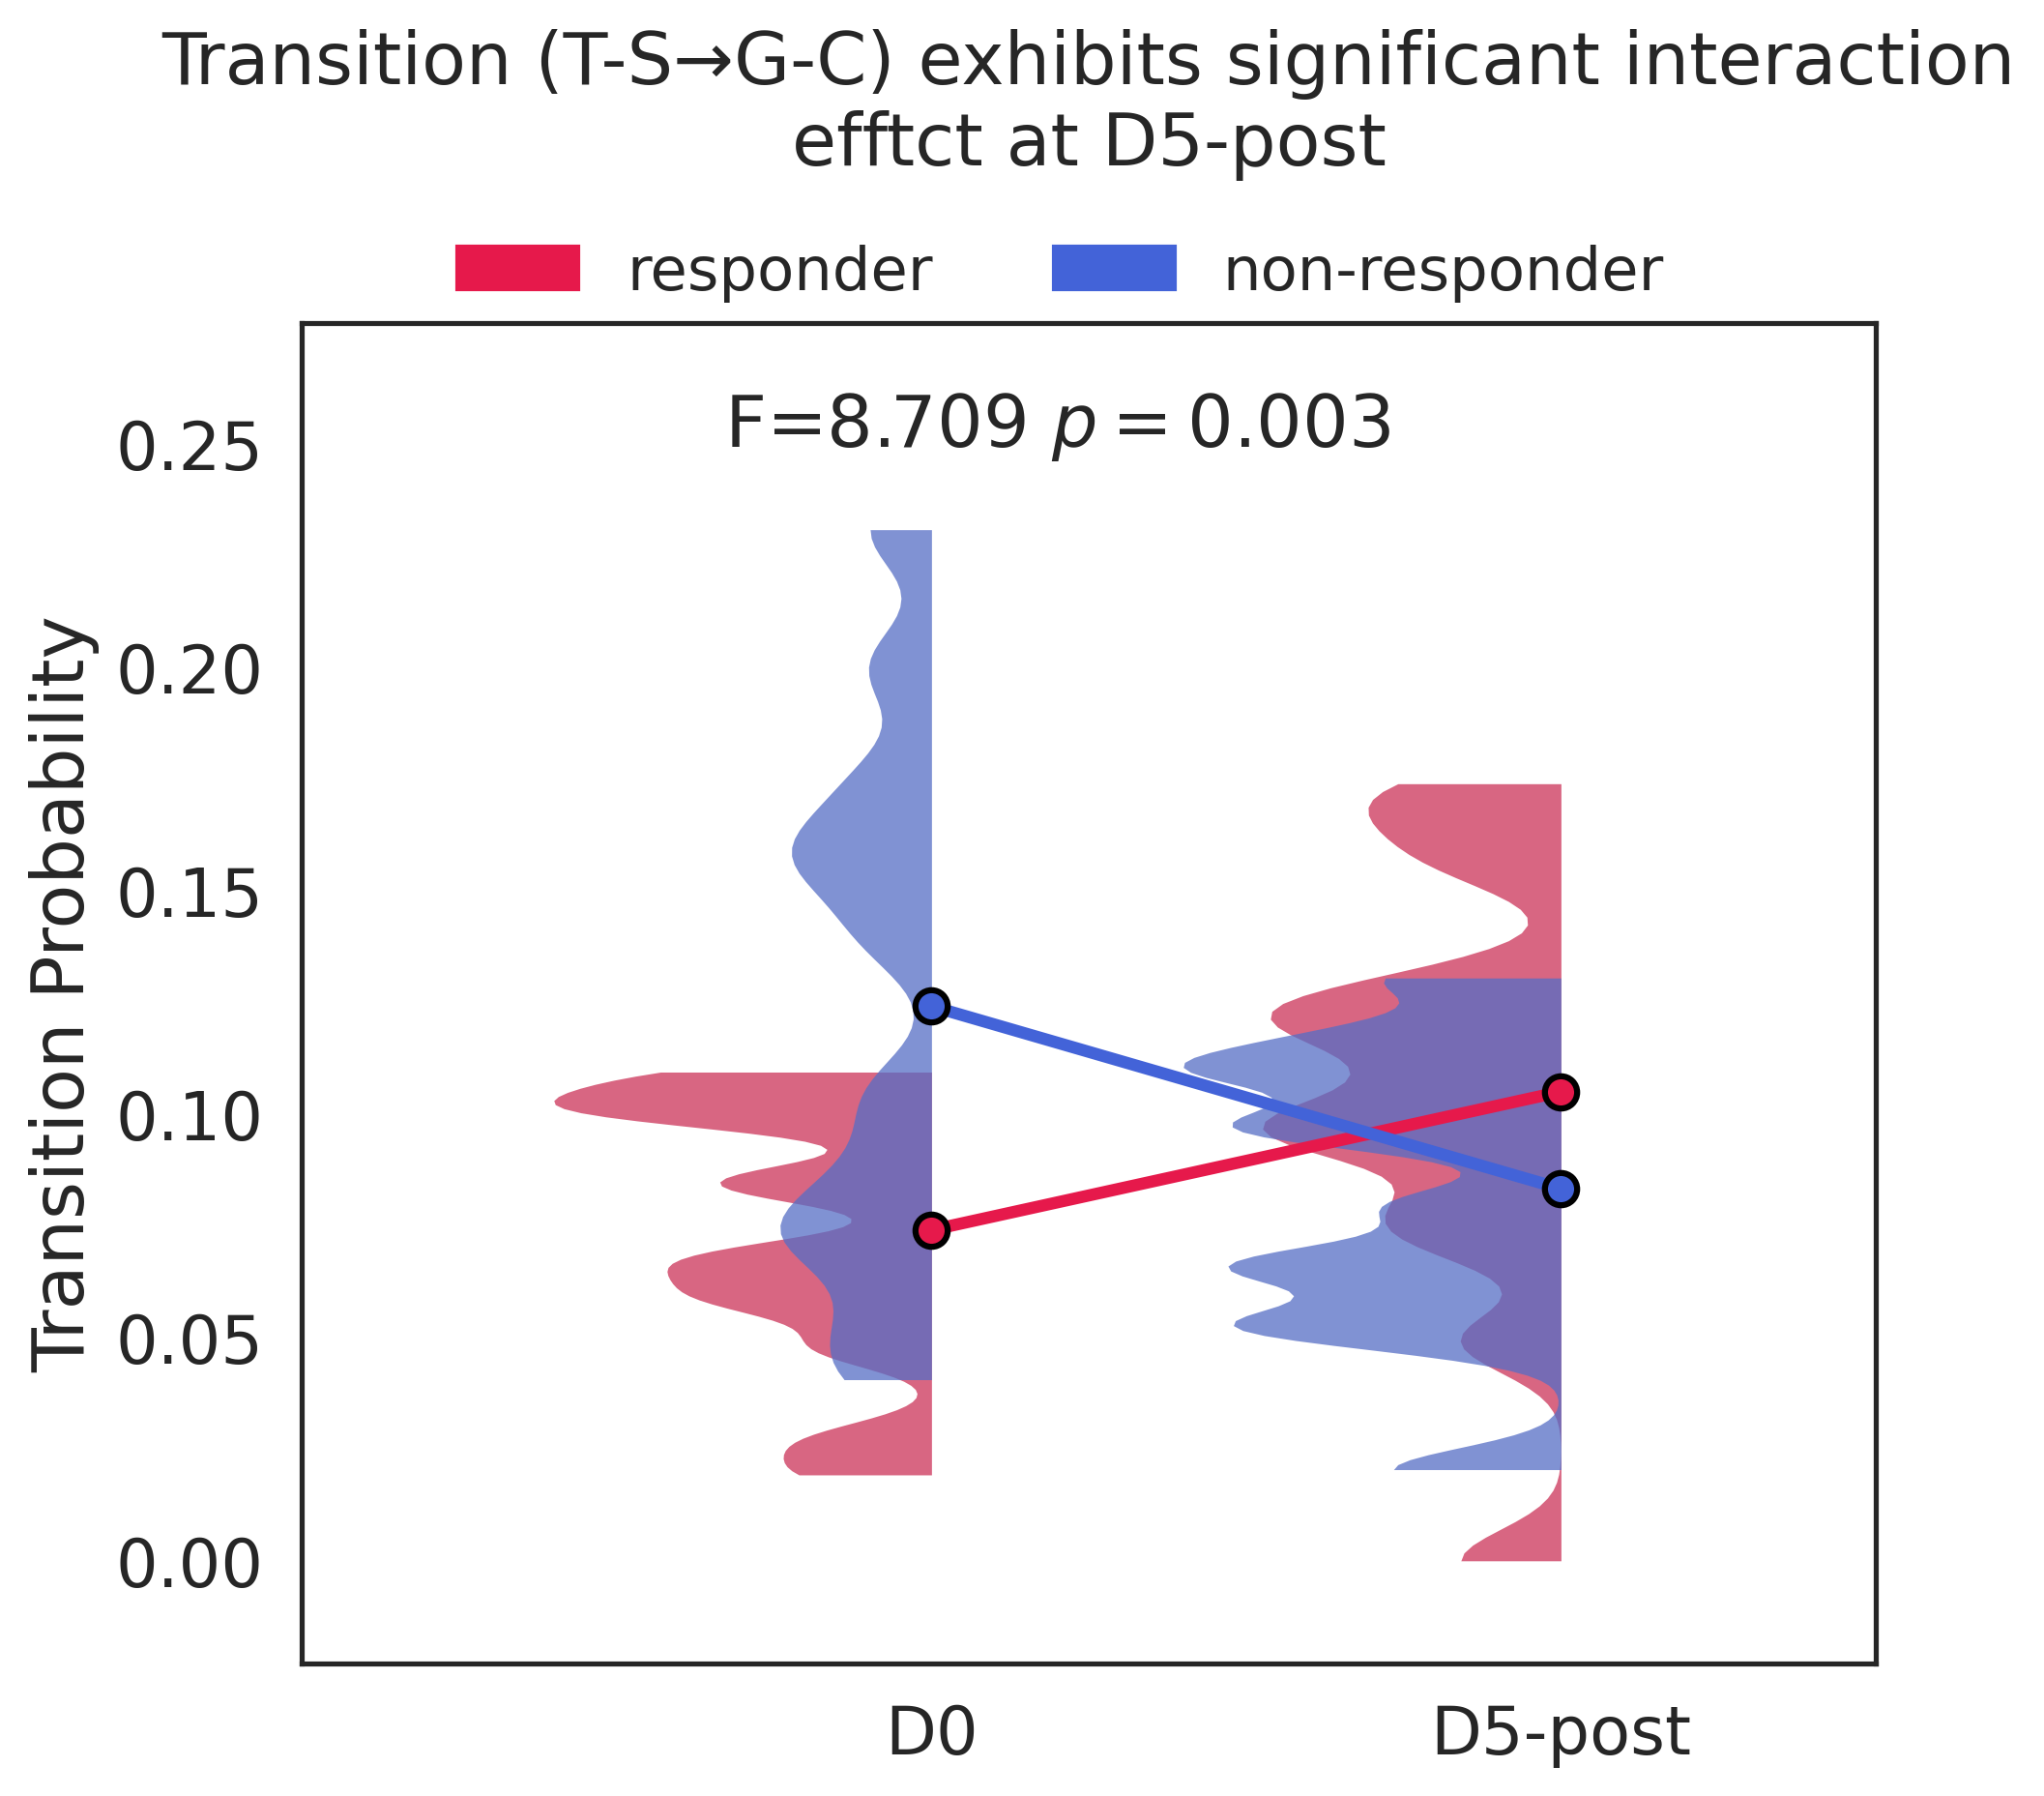

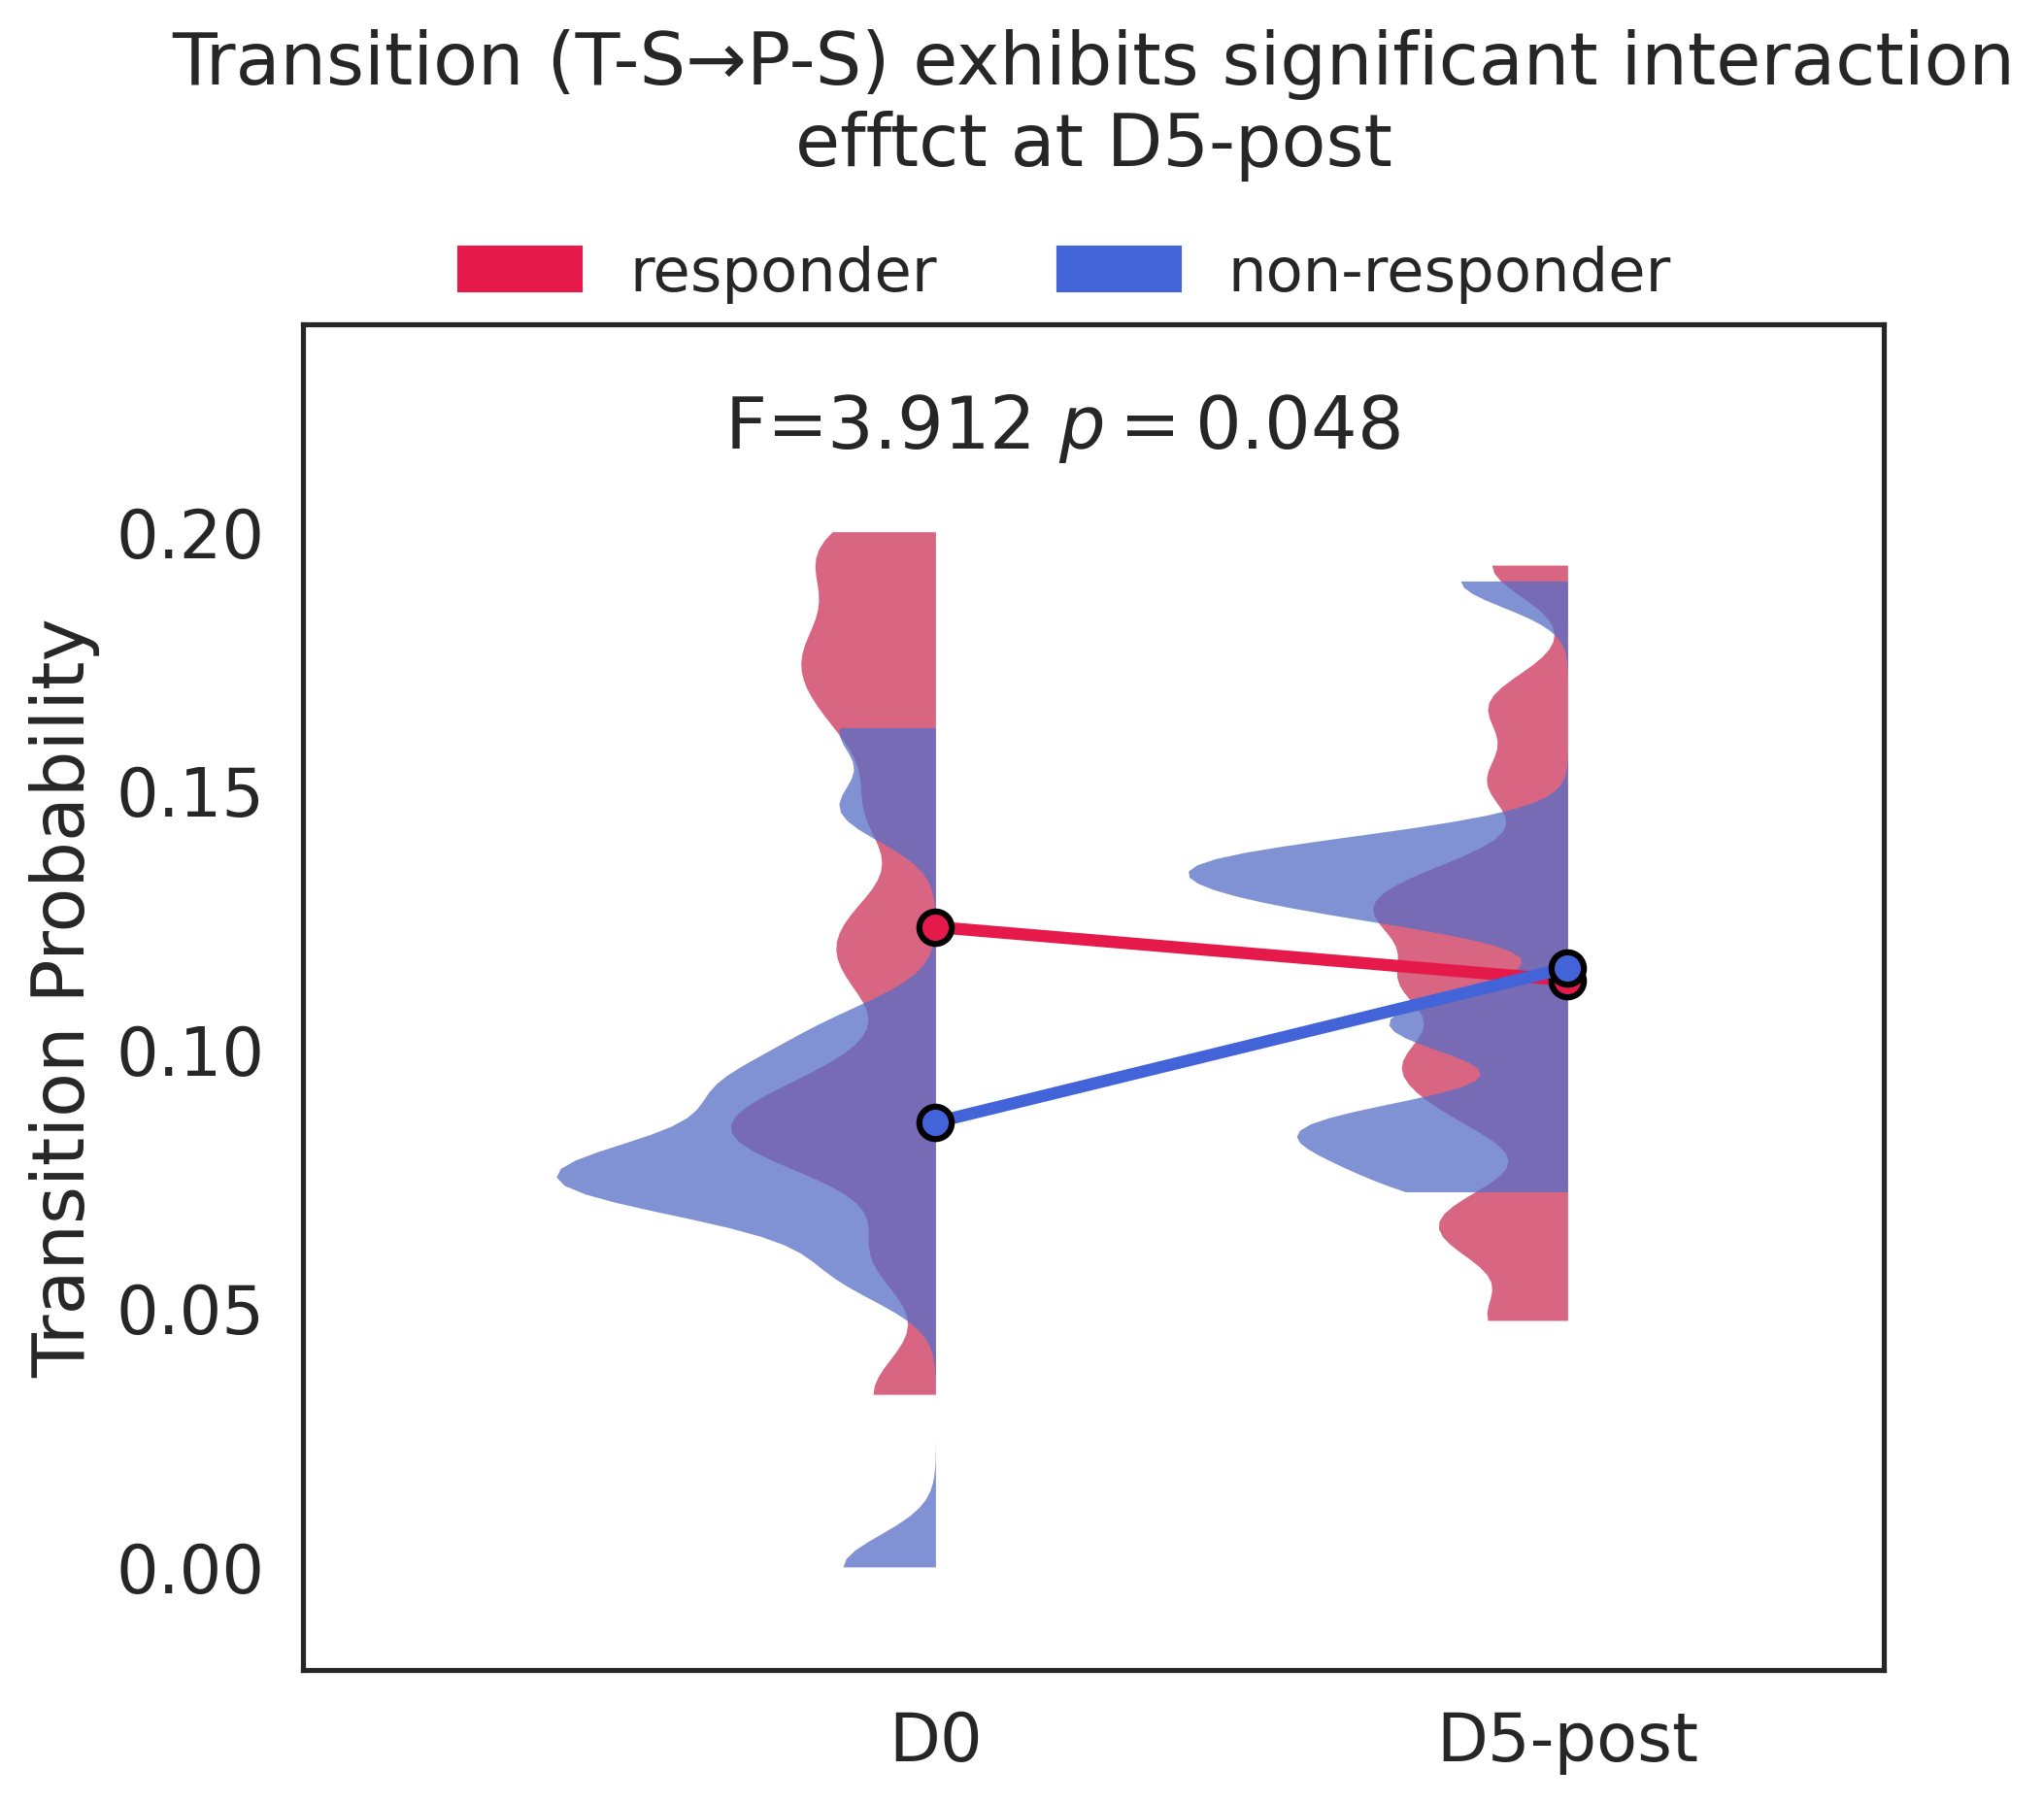

In [ ]:
# Plot significant D5-post interaction effects for selected transitions
ses = '5th_after'
data = trans[trans['condition'].isin(["baseline",ses])]
metric = 'From_4_to_1'
F,p = trans_LME[(trans_LME['session']==ses) & (trans_LME['state'] == metric)].loc[:,['F','p_interaction']].values[0]
plot_interaction(
    df = data, metric = metric, ses = ses, F = F,p = p, 
    ylabel=f"Transition Probability",
    title=f'Transition (T-S→G-C) exhibits significant interaction\nefftct at D5-post')

metric = 'From_4_to_2'
F,p = trans_LME[(trans_LME['session']==ses) & (trans_LME['state'] == metric)].loc[:,['F','p_interaction']].values[0]
plot_interaction(
    df = data, metric = metric, ses = ses, F = F,p = p, 
    ylabel=f"Transition Probability",
    title=f'Transition (T-S→P-S) exhibits significant interaction\nefftct at D5-post')


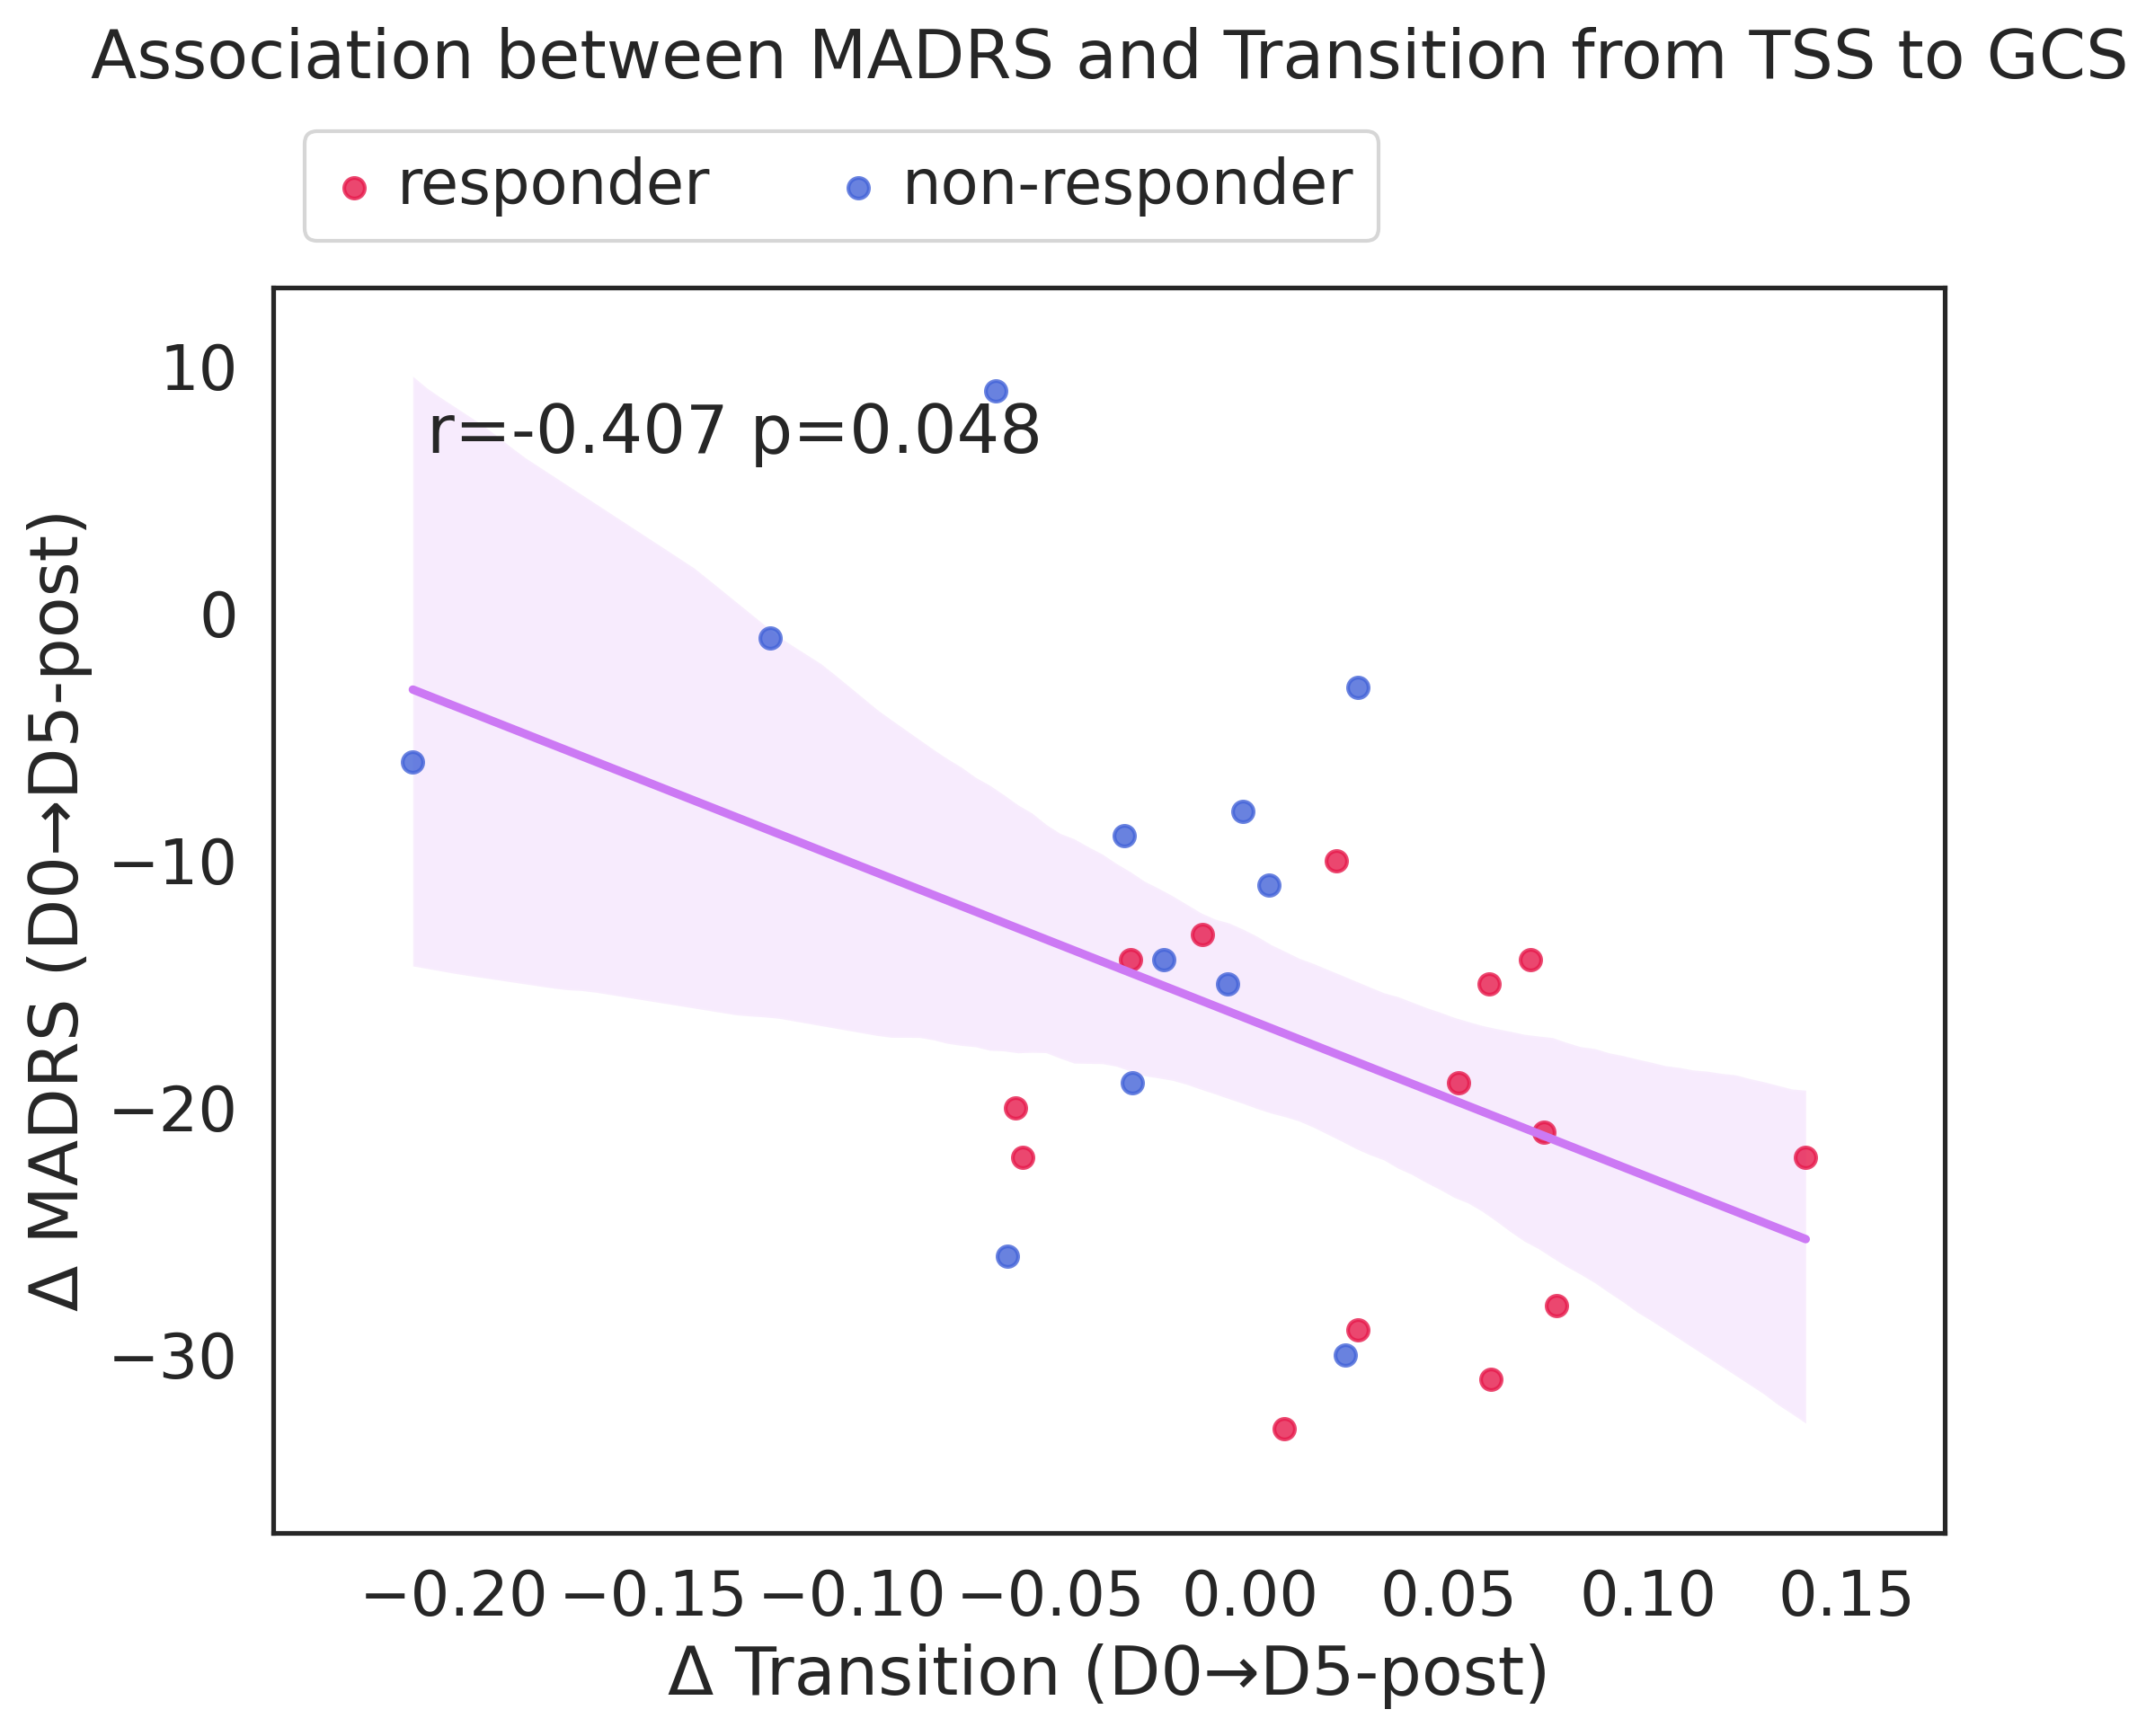

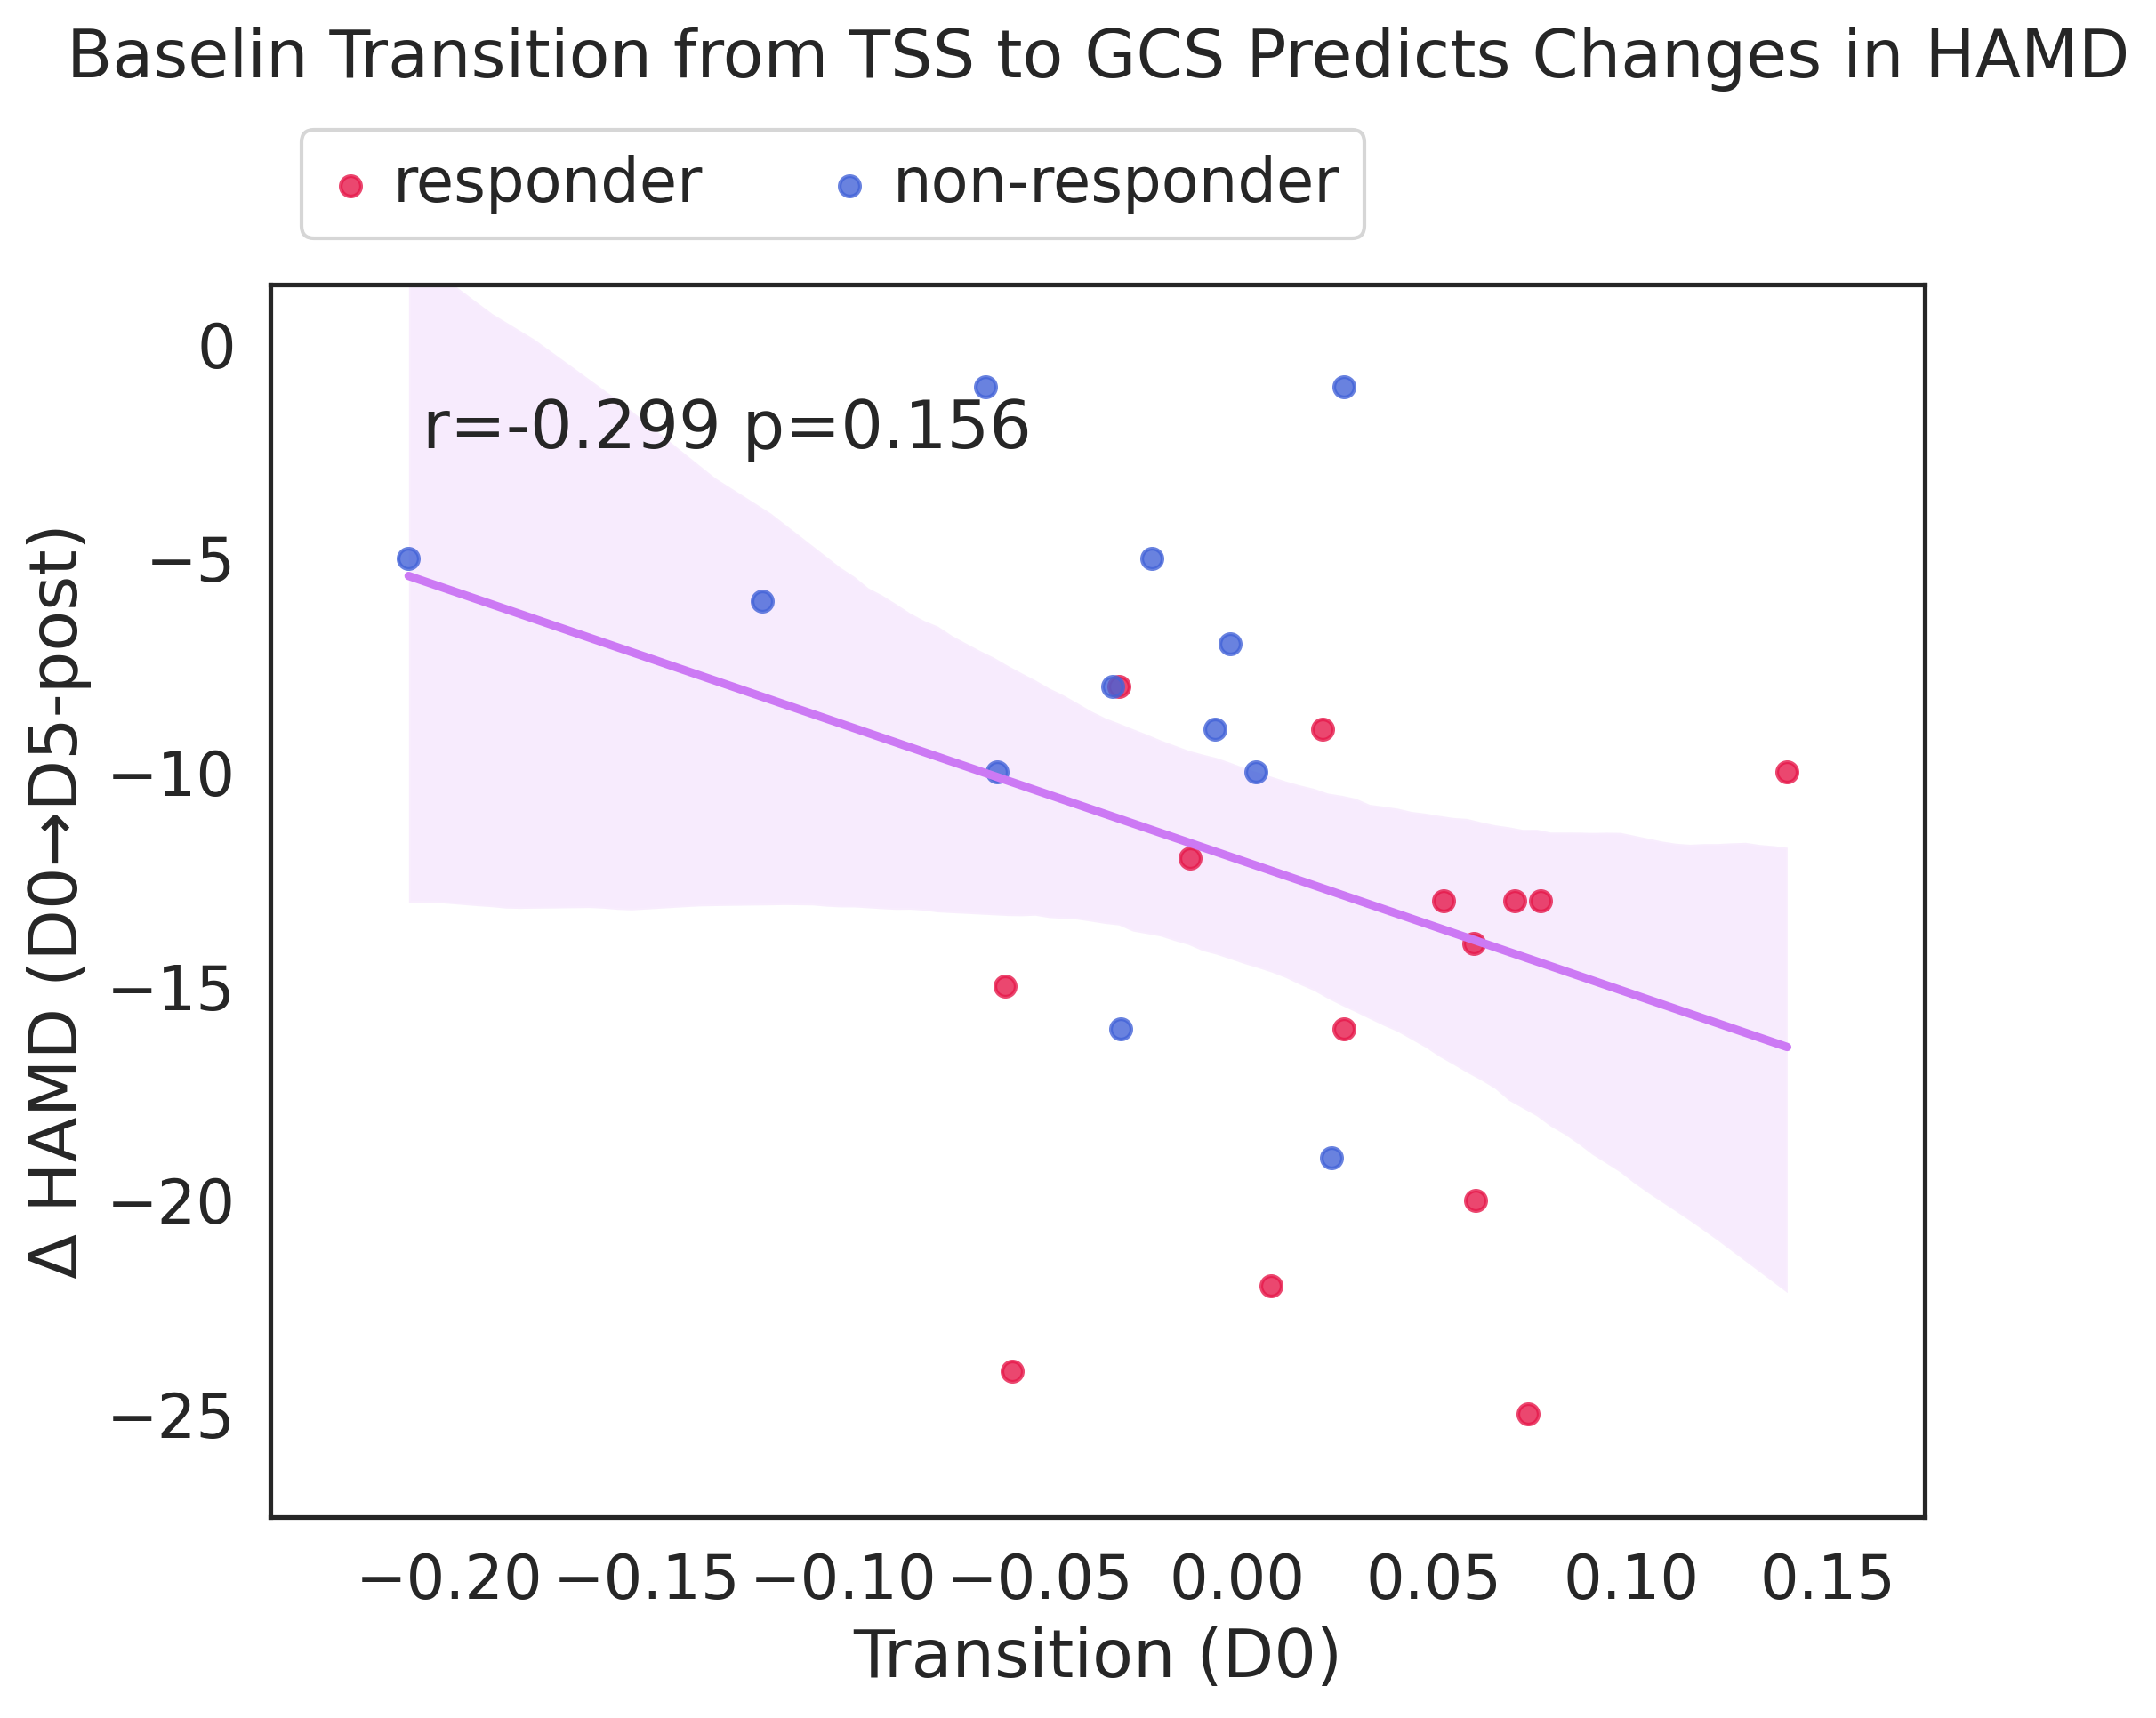

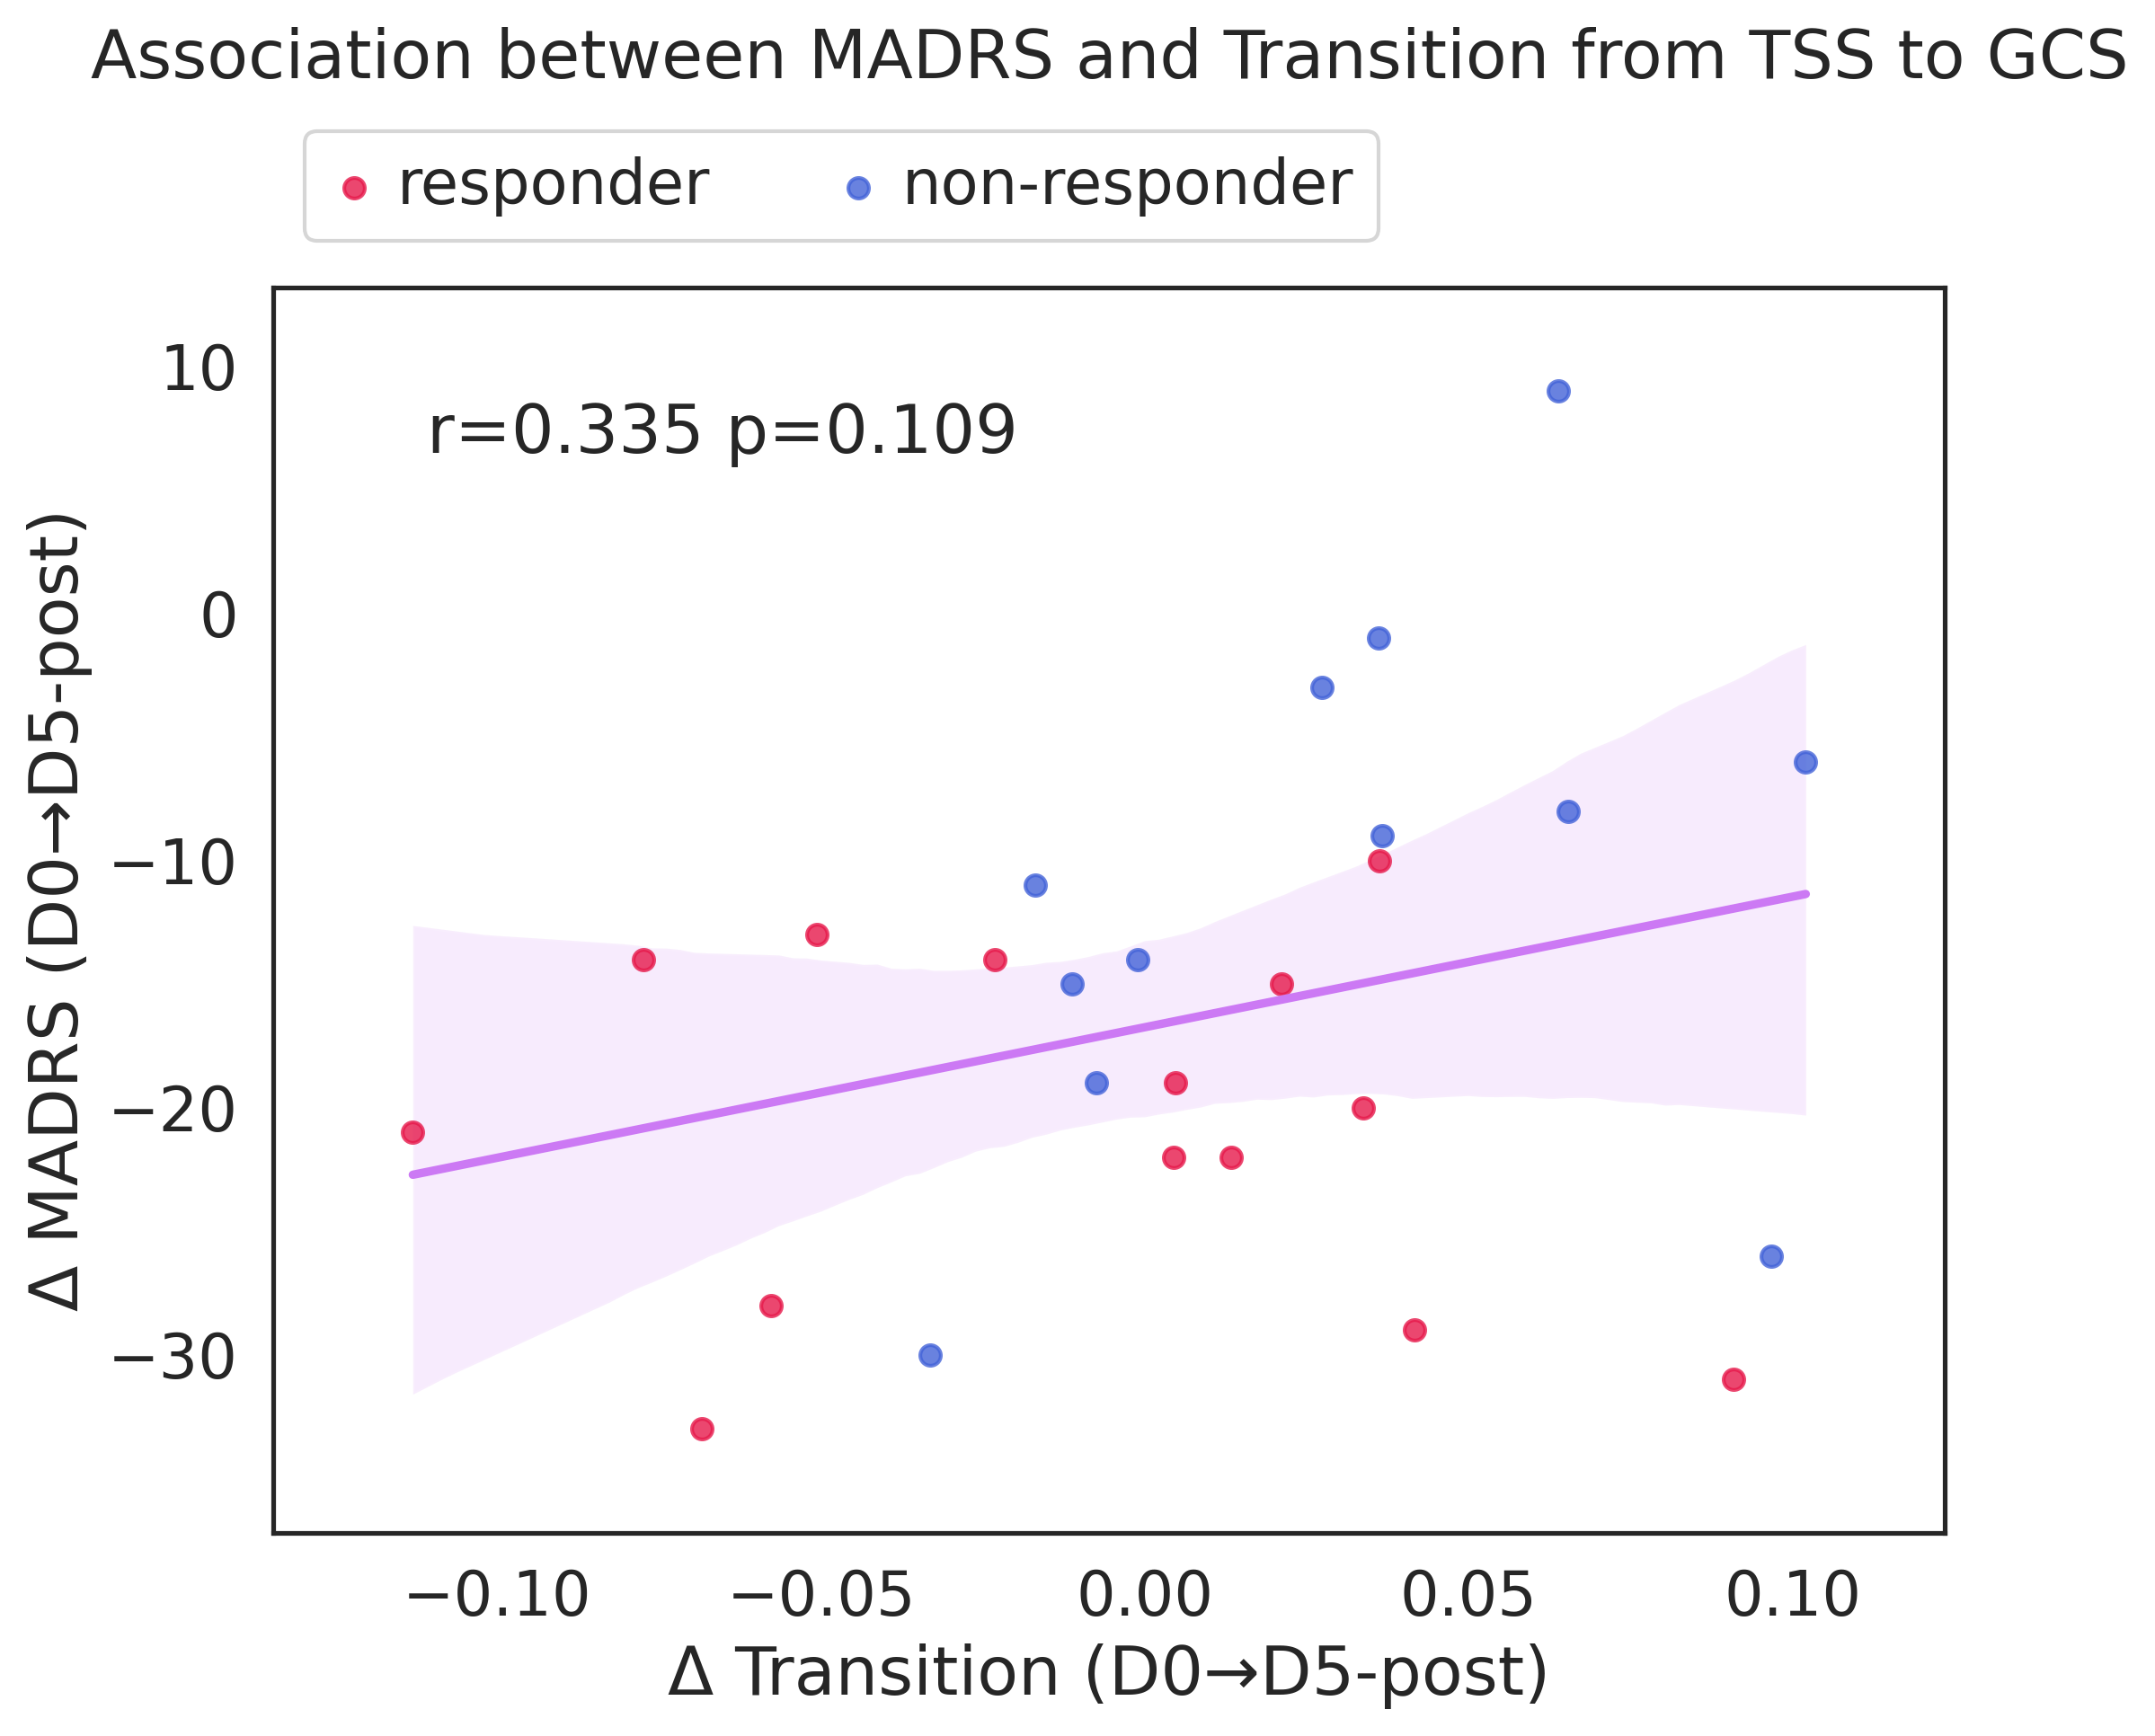

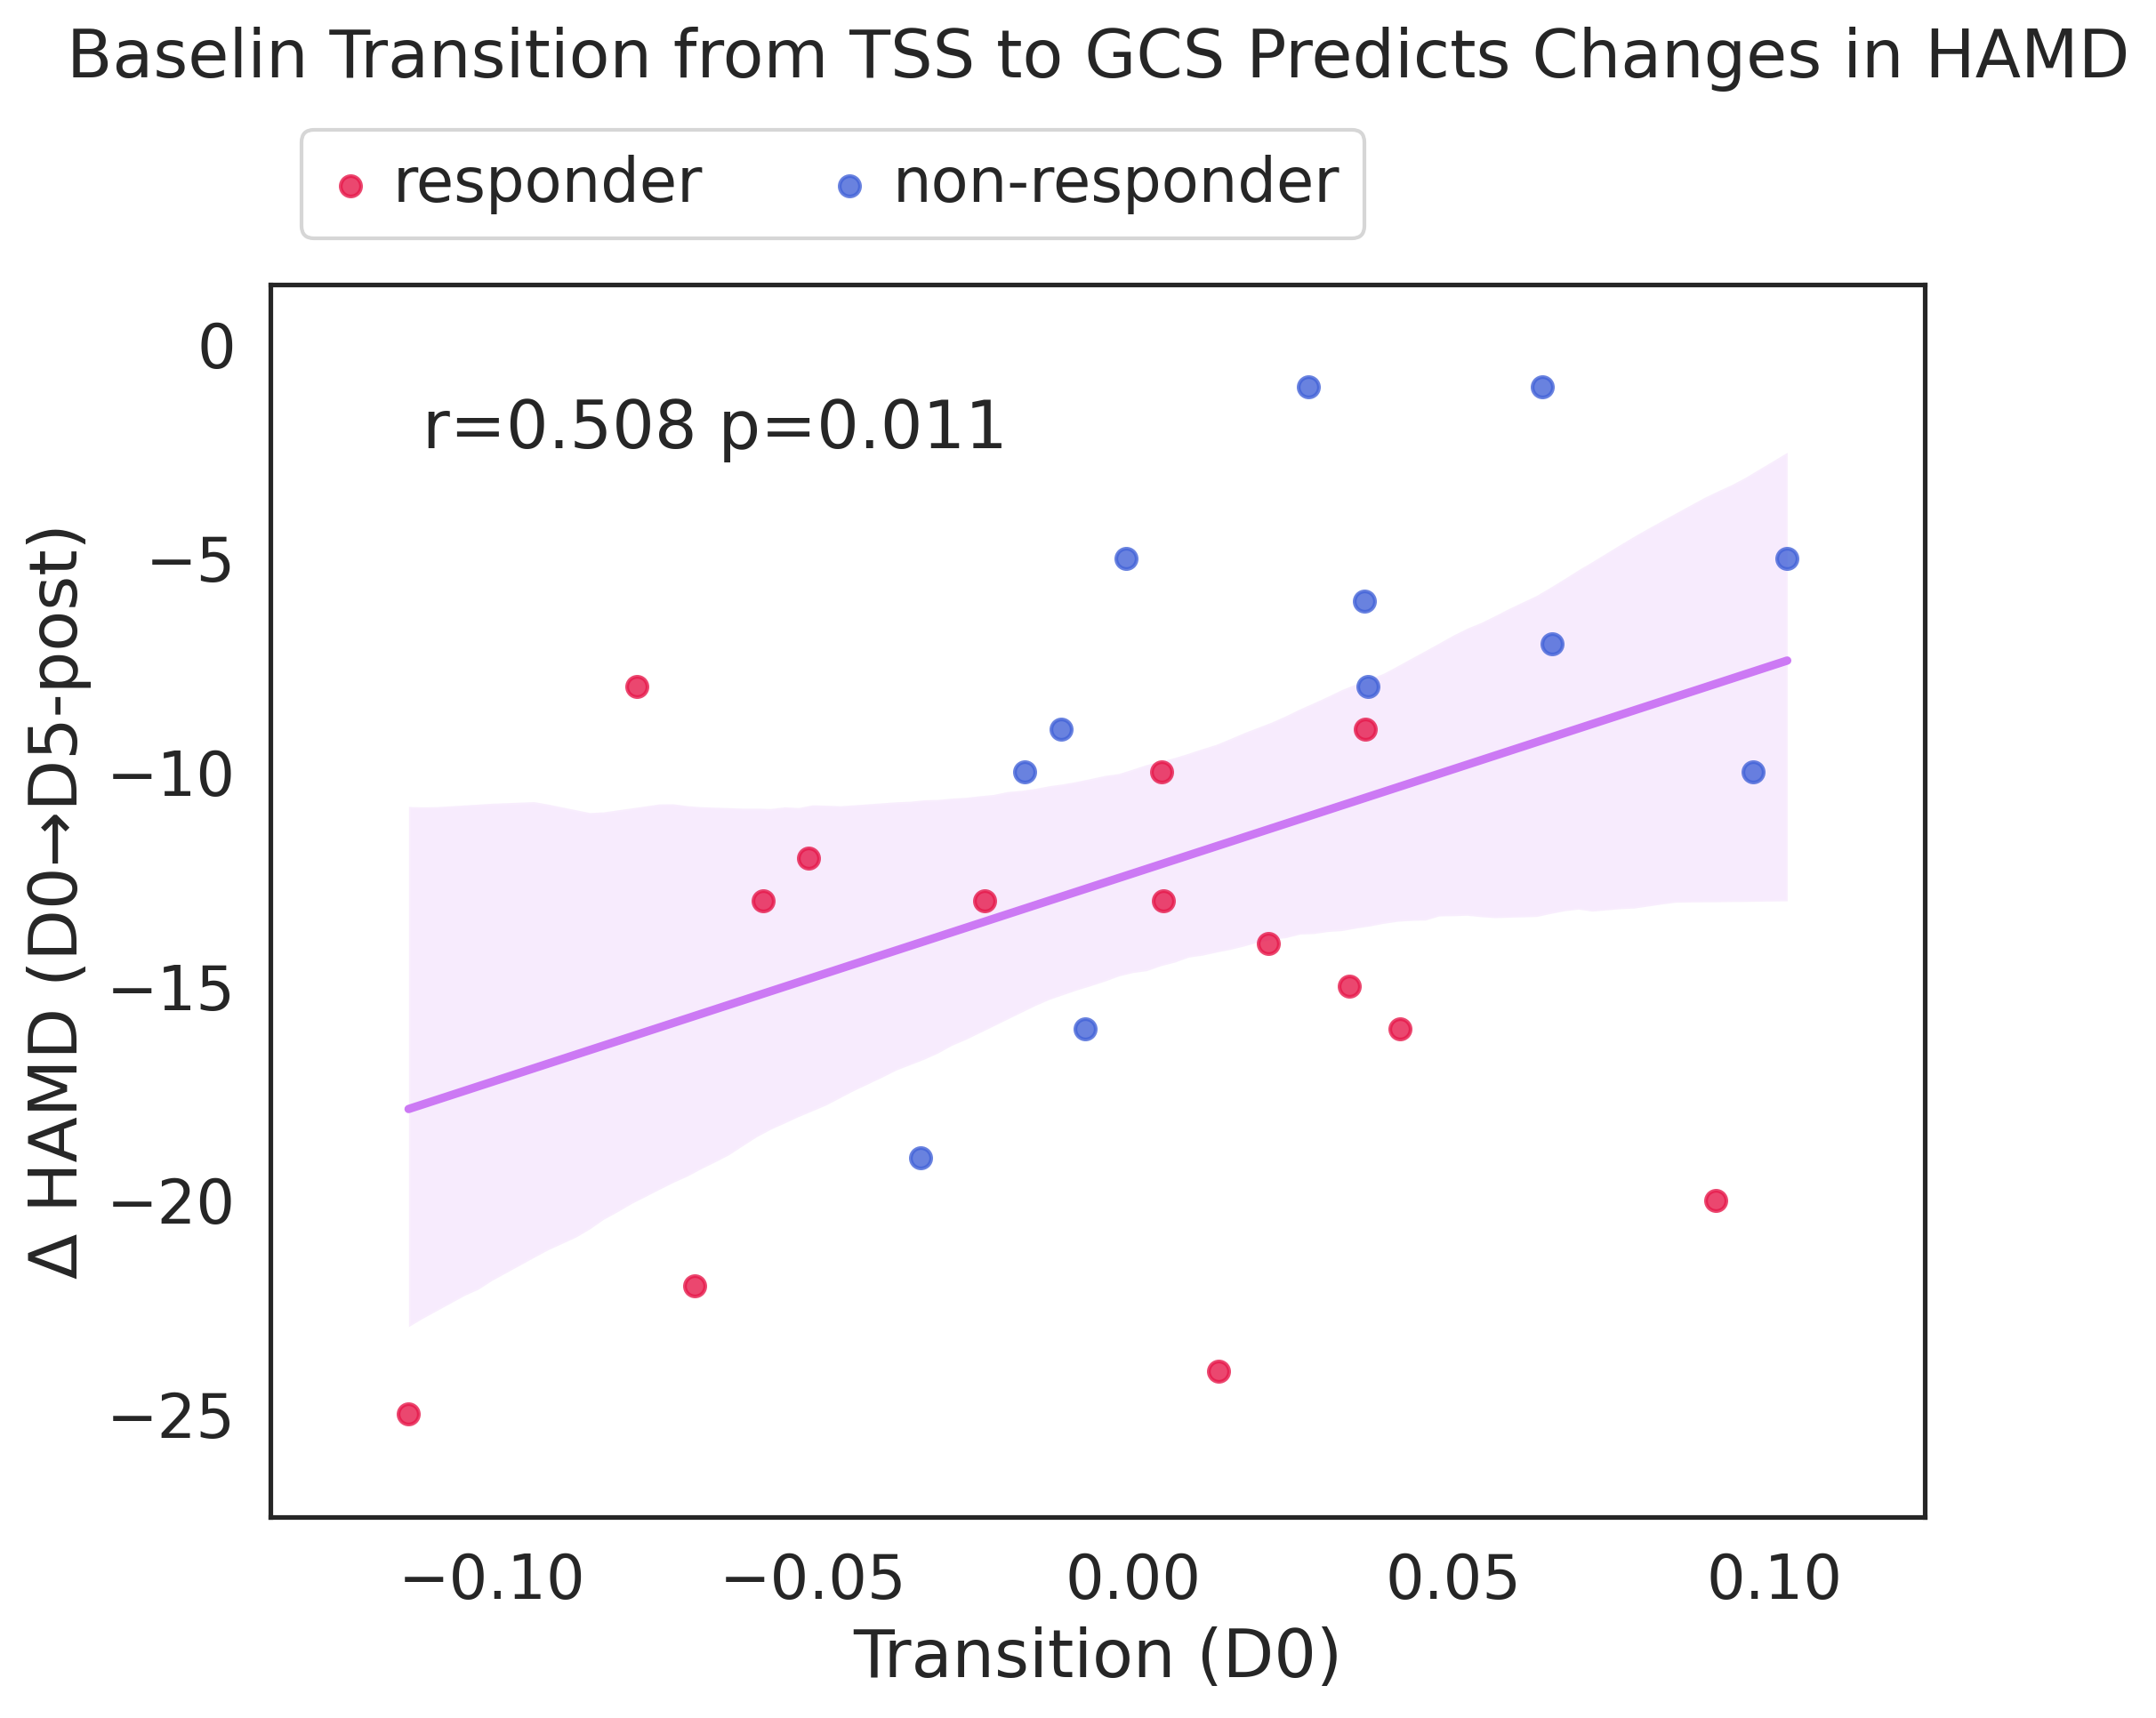

In [ ]:
# Correlation and prediction plots for D5-post transition metrics vs clinical scales
ses = '5th_after'
data = trans[trans['condition'].isin(["baseline",ses])]
mode = 'correlation'
metric = 'From_4_to_1'

col = 'MADRS'
plot_correlation(
    data = data, metric = metric,col = col, ses = ses, mode = mode, 
    xlabel = f'Δ Transition (D0→D5-post)', 
    ylabel = f'Δ {col} (D0→D5-post)', 
    title = f"Association between {col} and Transition from TSS to GCS")

col = 'HAMD'
plot_correlation(
    data = data, metric = metric,col = col, ses = ses, mode = mode, 
    xlabel = f'Transition (D0)', 
    ylabel = f'Δ {col} (D0→D5-post)', 
    title = f'Baselin Transition from TSS to GCS Predicts Changes in {col}')

ses = '5th_after'
data = trans[trans['condition'].isin(["baseline",ses])]
mode = 'correlation'
metric = 'From_4_to_2'

col = 'MADRS'
plot_correlation(
    data = data, metric = metric,col = col, ses = ses, mode = mode, 
    xlabel = f'Δ Transition (D0→D5-post)', 
    ylabel = f'Δ {col} (D0→D5-post)', 
    title = f"Association between {col} and Transition from TSS to GCS")

col = 'HAMD'
plot_correlation(
    data = data, metric = metric,col = col, ses = ses, mode = mode, 
    xlabel = f'Transition (D0)', 
    ylabel = f'Δ {col} (D0→D5-post)', 
    title = f'Baselin Transition from TSS to GCS Predicts Changes in {col}')


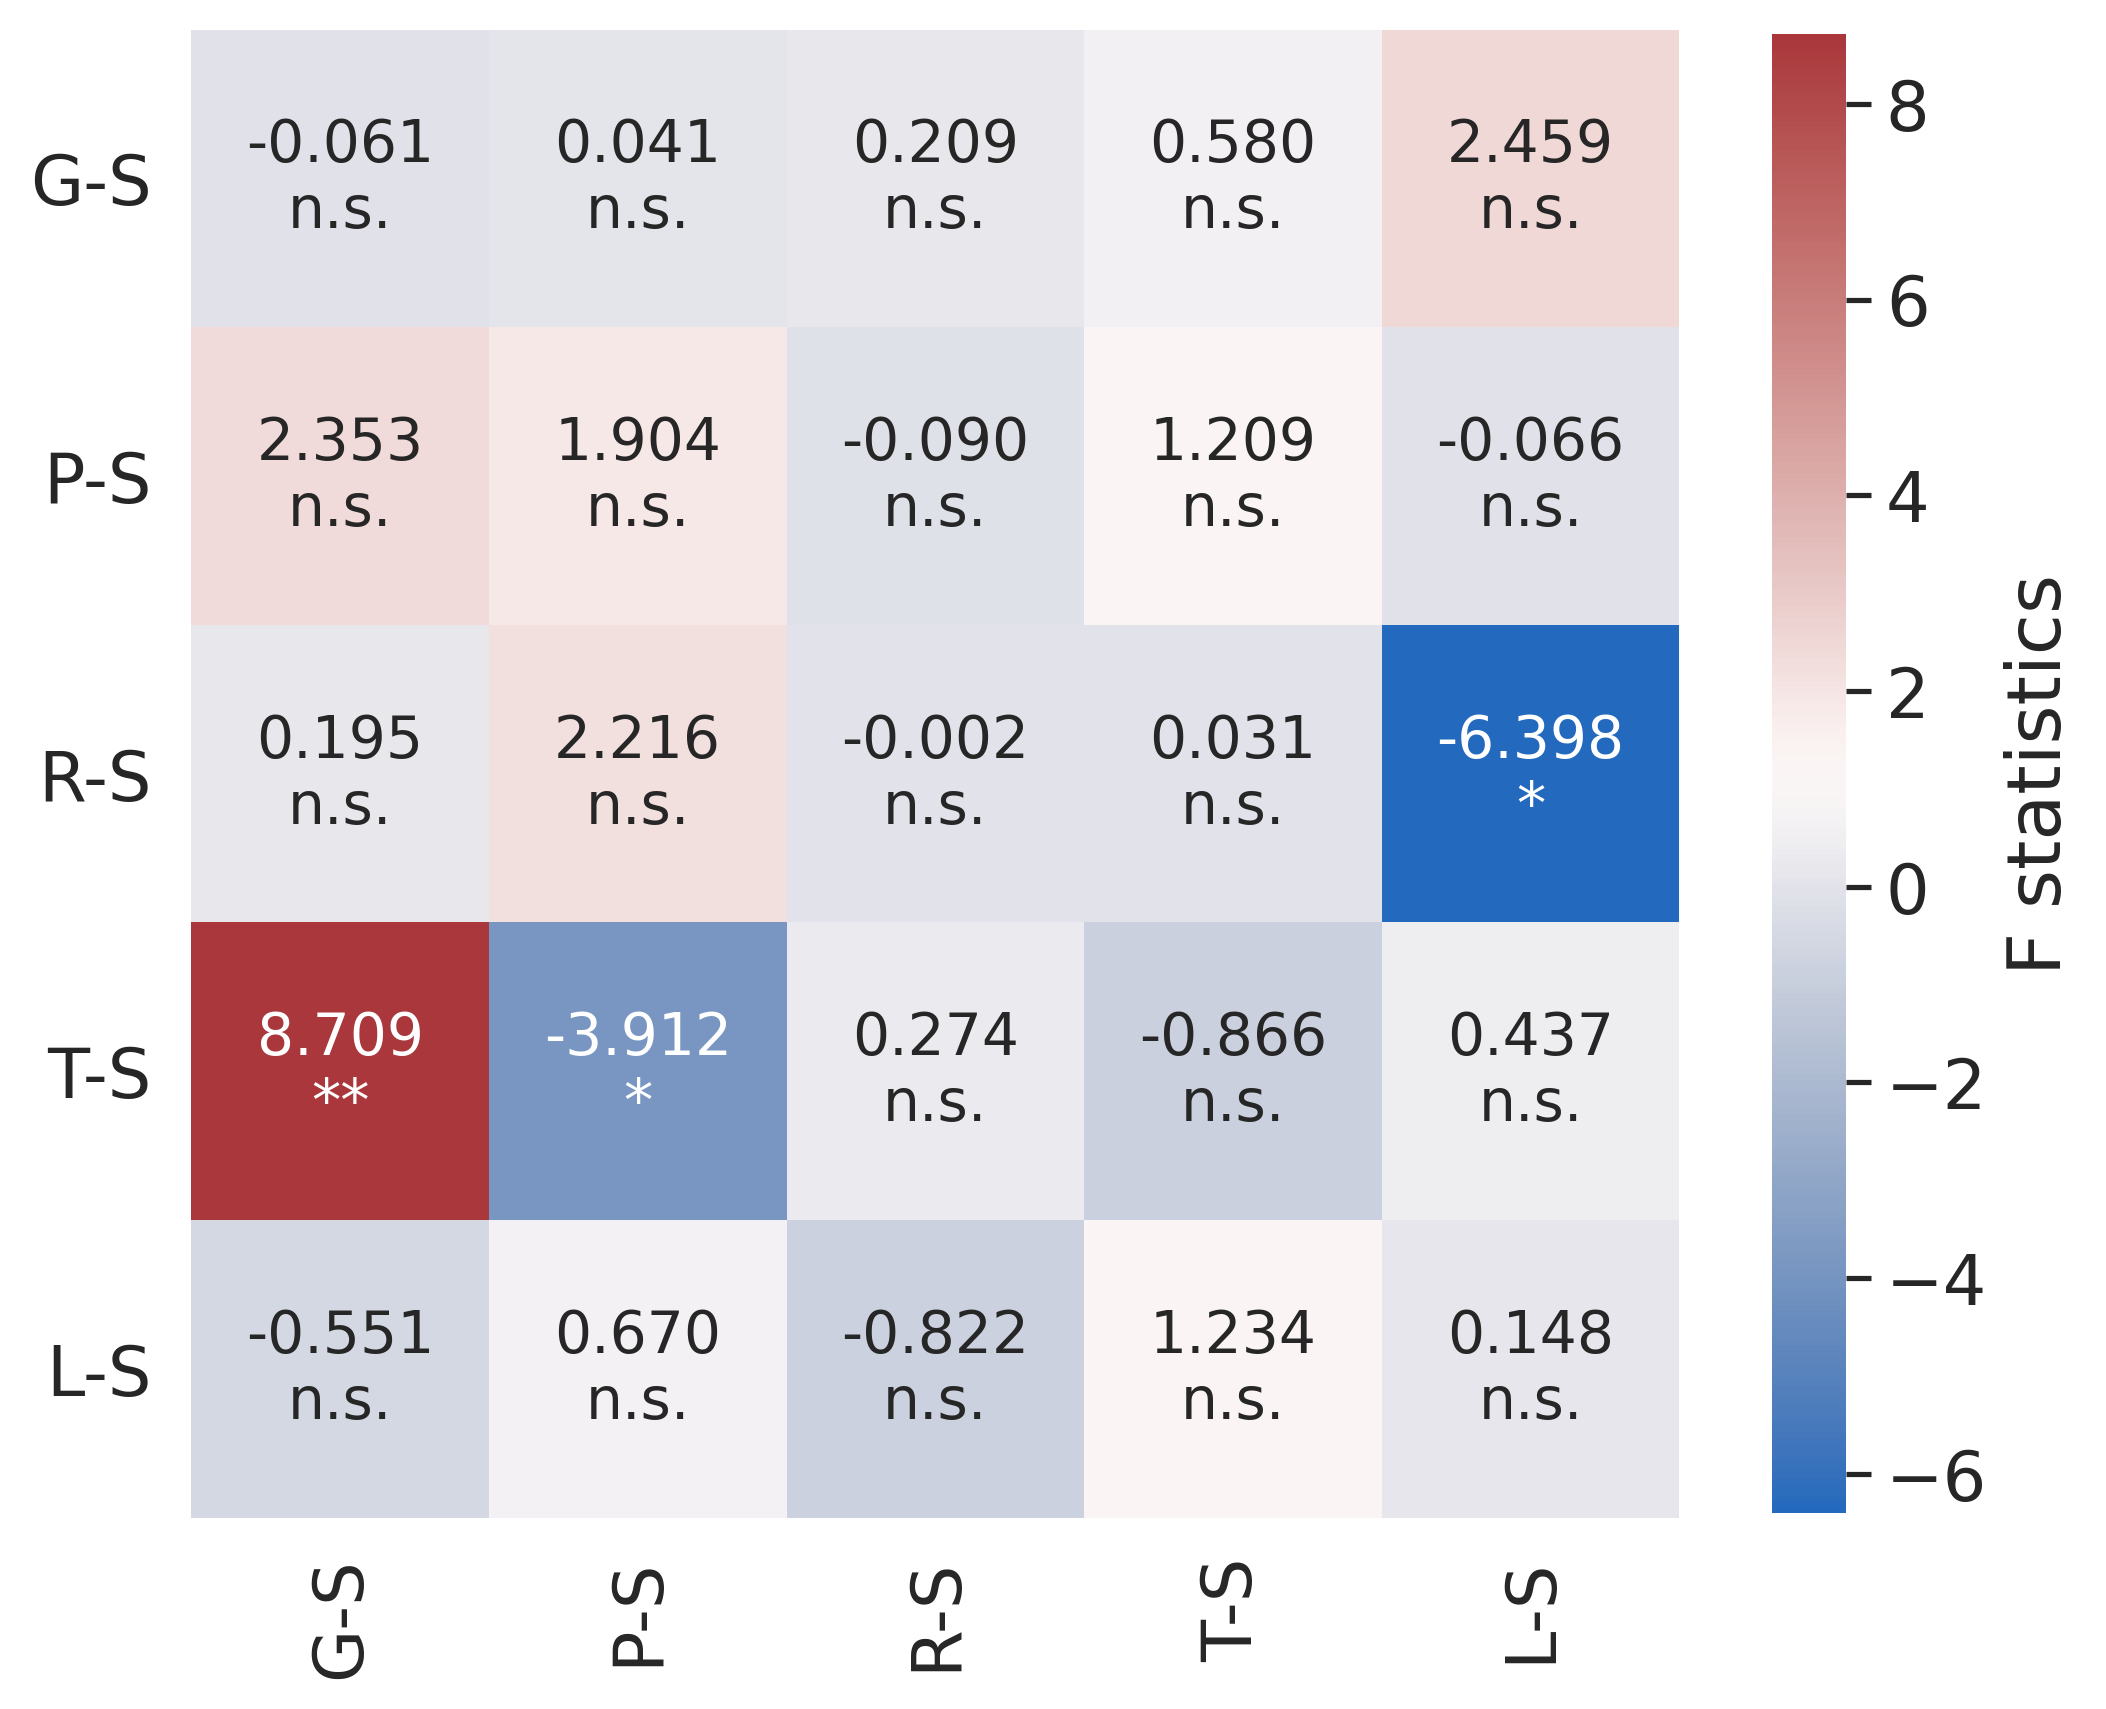

In [ ]:
# Build F-statistic heatmap for D5-post transition interaction effects
df = trans_LME[trans_LME['session'] == '5th_after']
F_matrix = pd.DataFrame(np.zeros((5,5)), index = state_ls, columns = state_ls)
p_matrix = F_matrix.copy()
for i in range(5):
    for j in range(5):
        F,p = df.loc[f"5th_after_From_{i+1}_to_{j+1}",['F','p_interaction']]
        F_matrix.iloc[i,j] = F
        p_matrix.iloc[i,j] = p

# Flip sign of F for transitions that increase in responders (positive T)
ses = '5th_after'
df = trans[(trans['condition'].isin(["baseline",ses])) & (trans['responder']=='responder')]
for state in trans_ls:
    model = smf.mixedlm(f"{state}~condition + sex + age", data = df, groups = df['subject_id']).fit()
    T = model.tvalues[1]
    ls = re.split('_',state)
    if(T>0):
        F_matrix.loc[f"PL_state_{ls[1]}",f"PL_state_{ls[-1]}"] *= -1 

# Create annotation matrix with F value and significance stars
annot = pd.DataFrame()
for state1 in state_ls:
    for state2 in state_ls:
        annot.loc[state1,state2] = f"{F_matrix.loc[state1,state2]:.3f}\n{p_star(p_matrix.loc[state1,state2])}"

# Heatmap of signed F statistics
fig,ax = plt.subplots(figsize = (8,8), dpi = 300)
sns.heatmap(
    data = F_matrix,
    annot = annot, fmt = '',
    cmap = 'vlag',
    square = True,
    cbar_kws={"shrink": .8, "aspect": 20, 'label':'F statistics'},
    annot_kws={"size": 14},
)
plt.xticks(np.arange(5)+.5, ['G-S','P-S','R-S','T-S','L-S'], rotation = 90)
plt.yticks(np.arange(5)+.5, ['G-S','P-S','R-S','T-S','L-S'], rotation = 0)
plt.show()


#### **W4 Interaction**

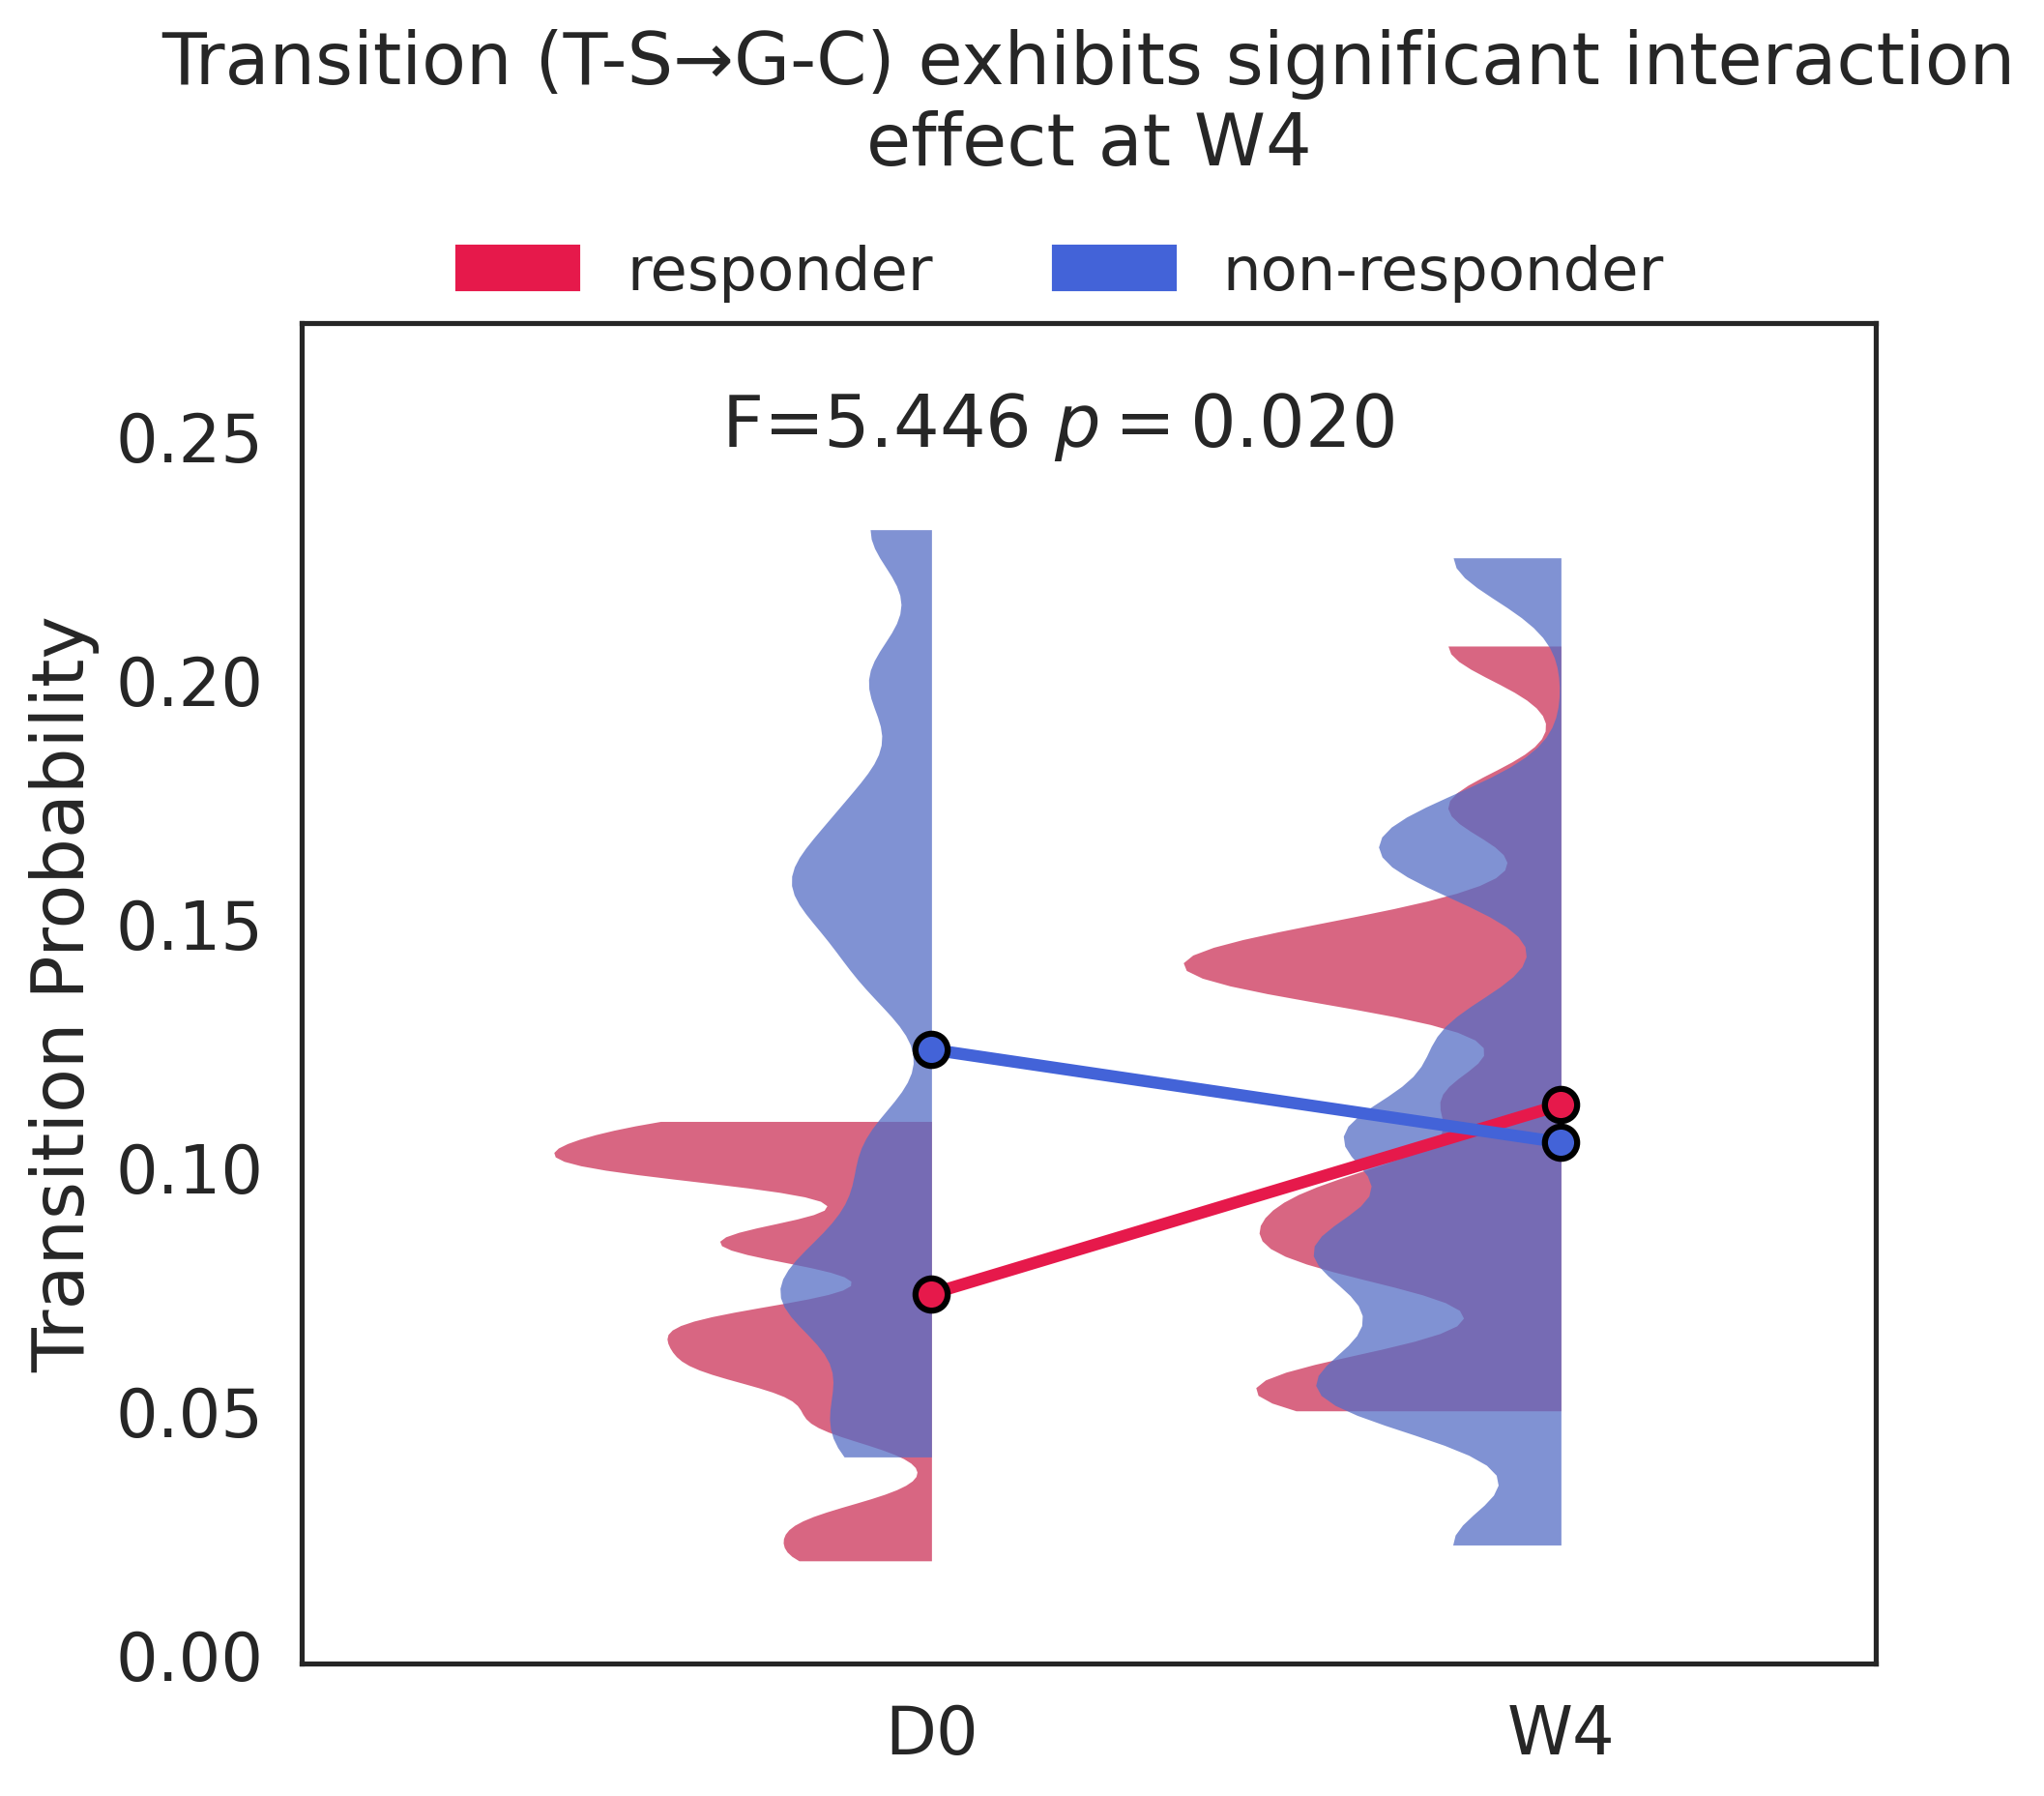

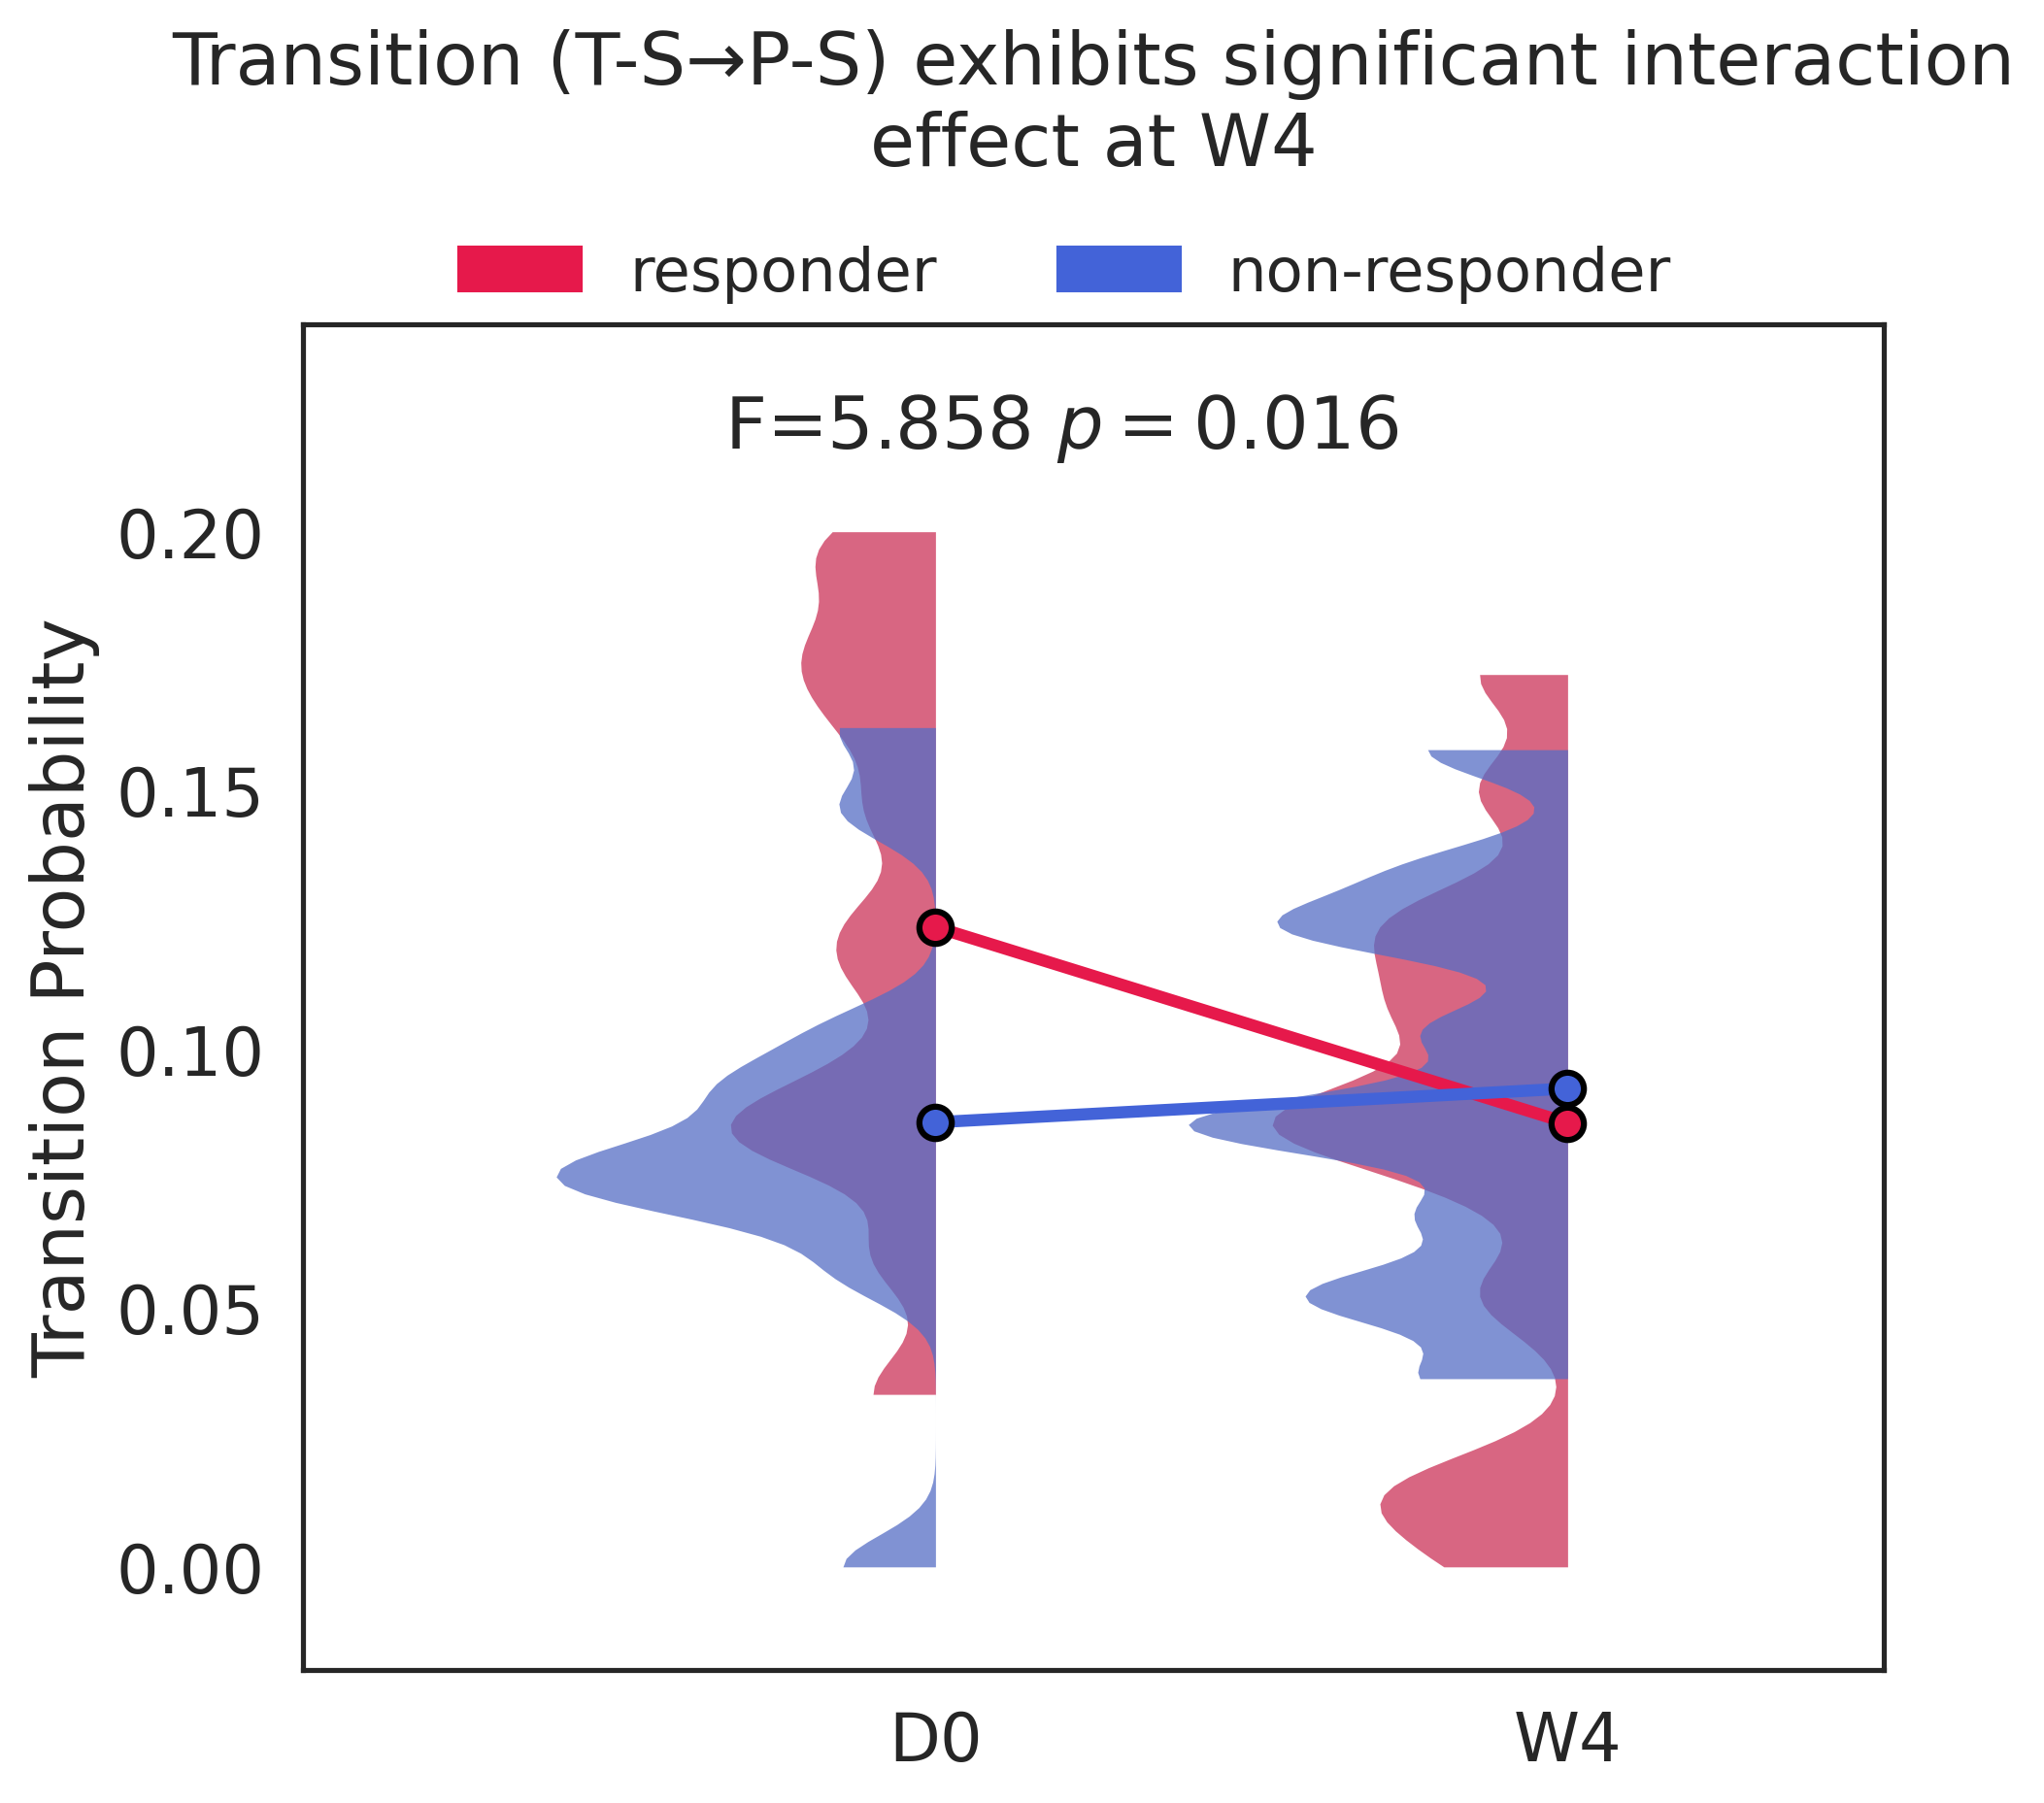

In [ ]:
# Plot significant W4 interaction effects for selected transitions
ses = '4weeks'
data = trans[trans['condition'].isin(["baseline",ses])]
metric = 'From_4_to_1'
F,p = trans_LME[(trans_LME['session']==ses) & (trans_LME['state'] == metric)].loc[:,['F','p_interaction']].values[0]
plot_interaction(
    df = data, metric = metric, ses = ses, F = F,p = p, 
    ylabel=f"Transition Probability",
    title=f'Transition (T-S→G-C) exhibits significant interaction\neffect at W4')

metric = 'From_4_to_2'
F,p = trans_LME[(trans_LME['session']==ses) & (trans_LME['state'] == metric)].loc[:,['F','p_interaction']].values[0]
plot_interaction(
    df = data, metric = metric, ses = ses, F = F,p = p, 
    ylabel=f"Transition Probability",
    title=f'Transition (T-S→P-S) exhibits significant interaction\neffect at W4')


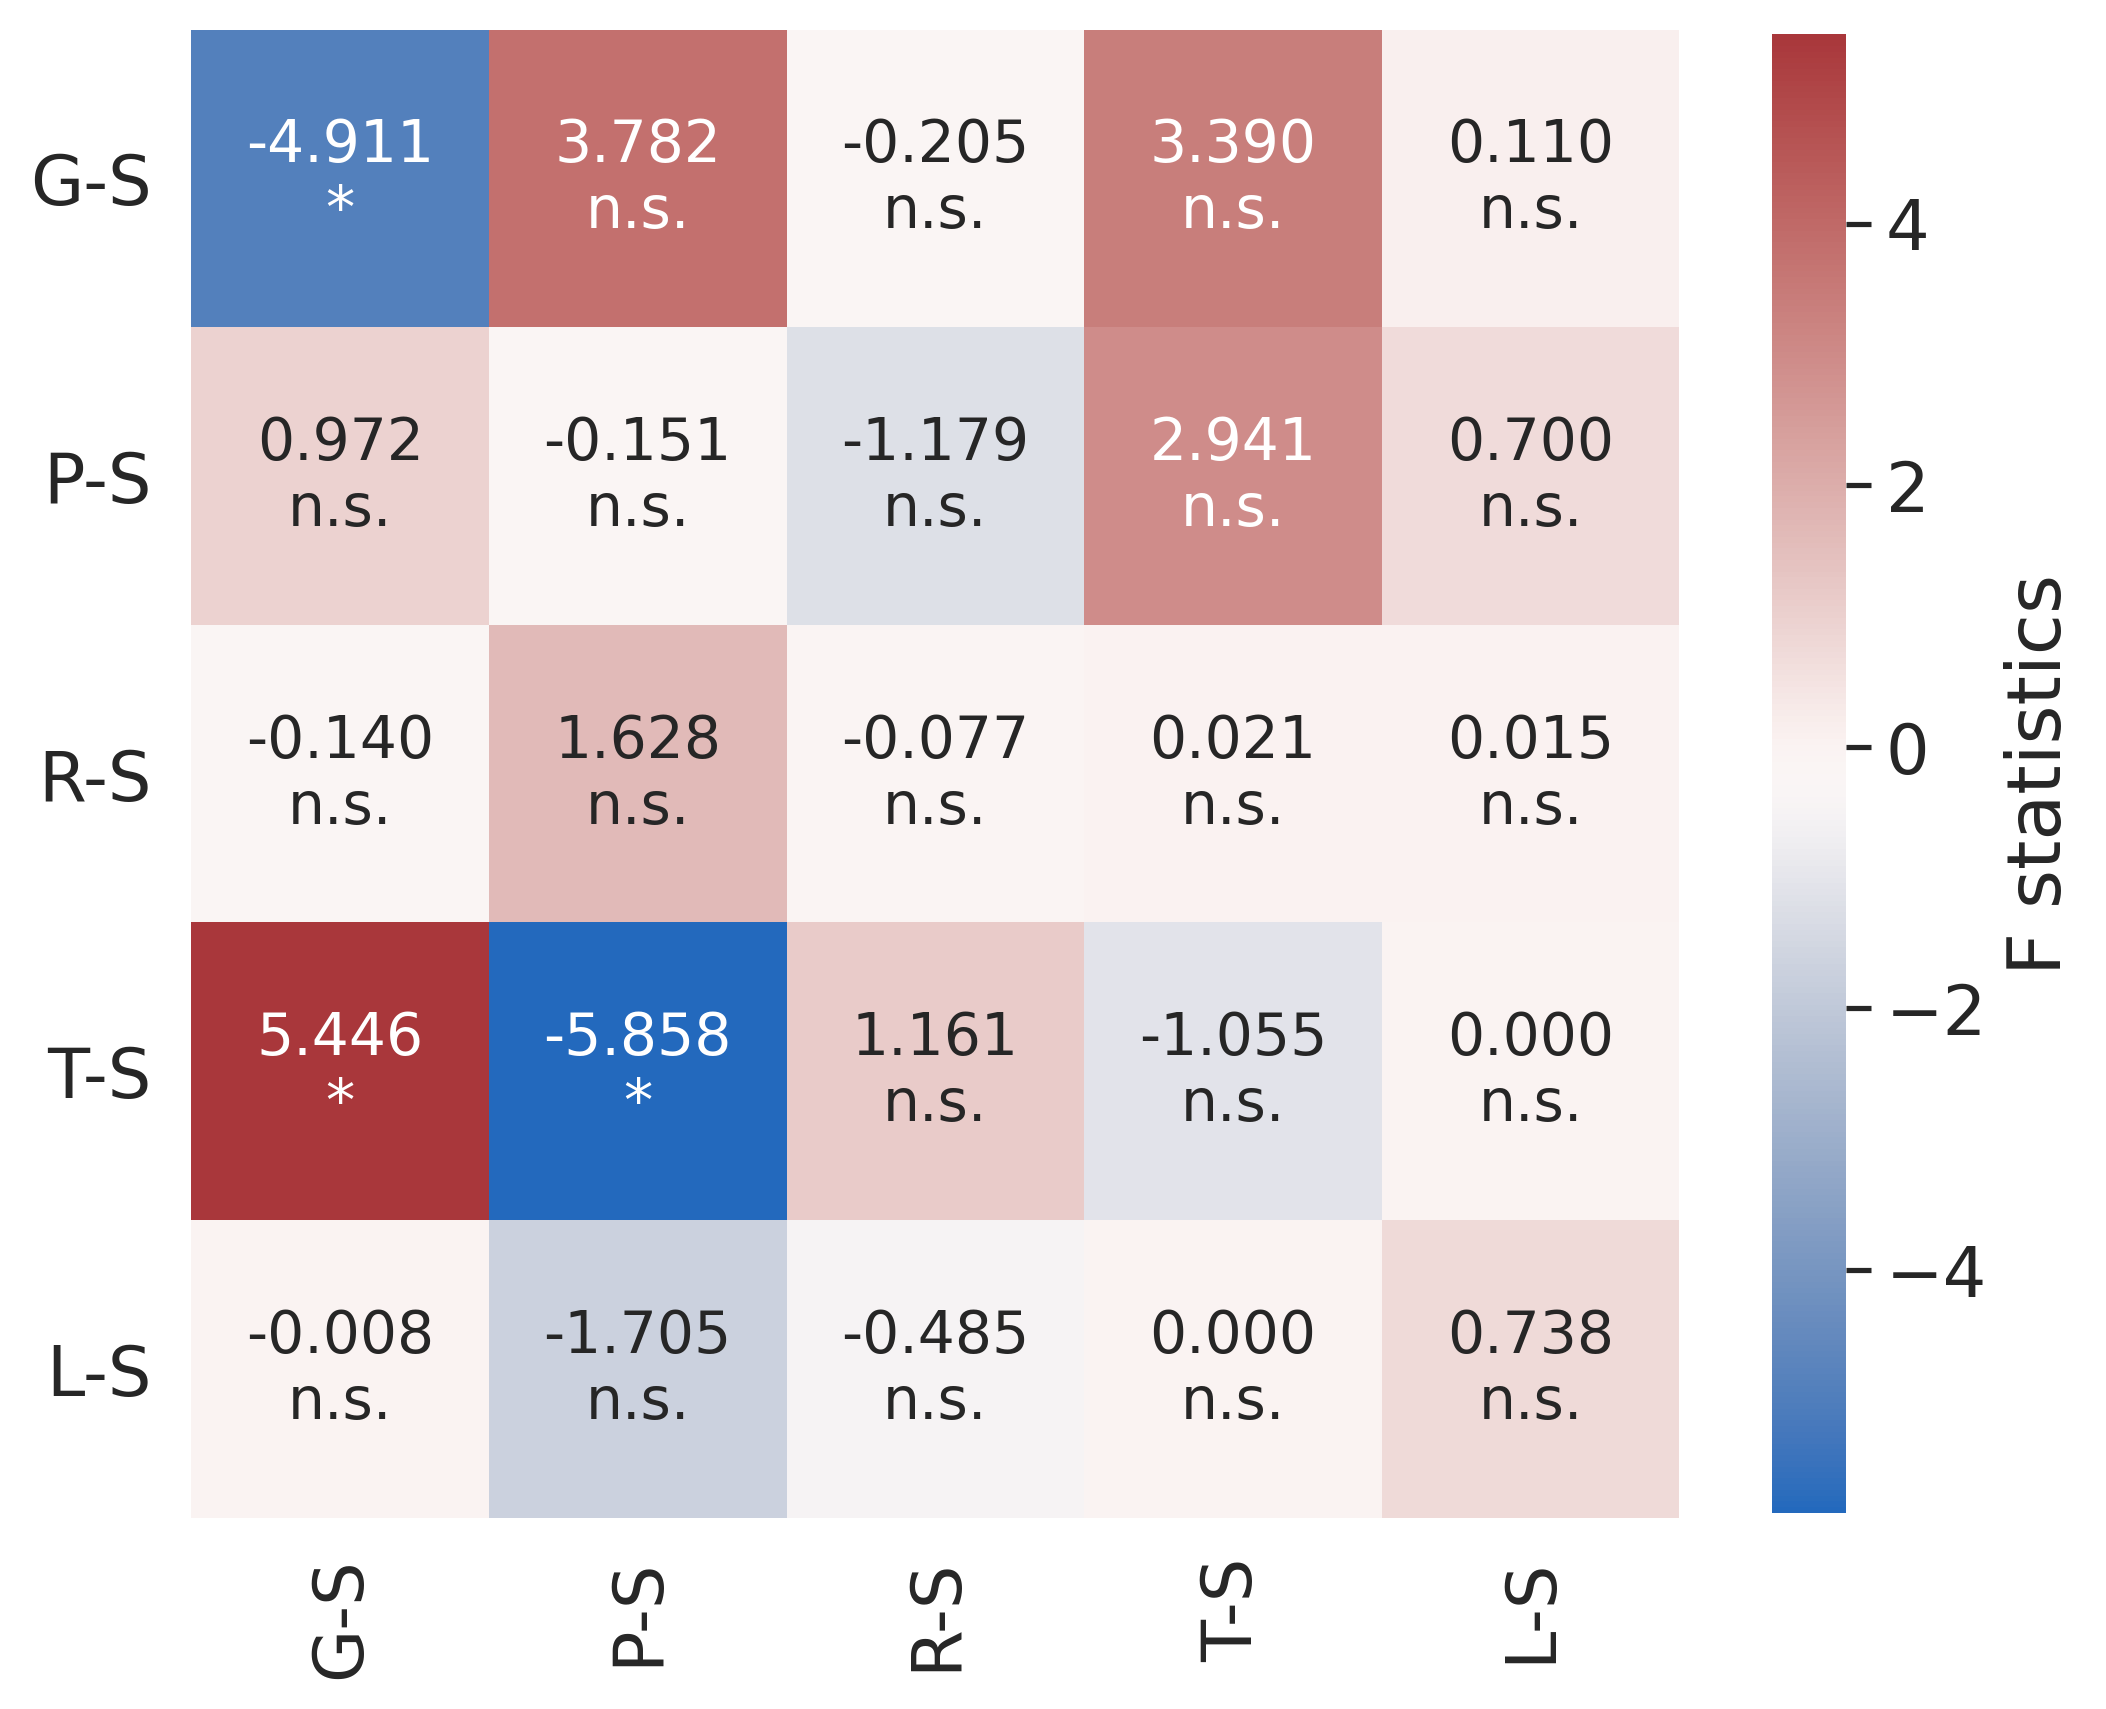

In [ ]:
# Build F-statistic heatmap for W4 transition interaction effects
df = trans_LME[trans_LME['session'] == '4weeks']
F_matrix = pd.DataFrame(np.zeros((5,5)), index = state_ls, columns = state_ls)
p_matrix = F_matrix.copy()
for i in range(5):
    for j in range(5):
        F,p = df.loc[f"4weeks_From_{i+1}_to_{j+1}",['F','p_interaction']]
        F_matrix.iloc[i,j] = F
        p_matrix.iloc[i,j] = p

# Flip sign for transitions that increase in responders
ses = '4weeks'
df = trans[(trans['condition'].isin(["baseline",ses])) & (trans['responder']=='responder')]
for state in trans_ls:
    model = smf.mixedlm(f"{state}~condition + sex + age", data = df, groups = df['subject_id']).fit()
    T = model.tvalues[1]
    ls = re.split('_',state)
    if(T>0):
        F_matrix.loc[f"PL_state_{ls[1]}",f"PL_state_{ls[-1]}"] *= -1 

annot = pd.DataFrame()
for state1 in state_ls:
    for state2 in state_ls:
        annot.loc[state1,state2] = f"{F_matrix.loc[state1,state2]:.3f}\n{p_star(p_matrix.loc[state1,state2])}"

# Heatmap of signed F statistics
fig,ax = plt.subplots(figsize = (8,8), dpi = 300)
sns.heatmap(
    data = F_matrix,
    annot = annot, fmt = '',
    cmap = 'vlag',
    square = True,
    cbar_kws={"shrink": .8, "aspect": 20, 'label':'F statistics'},
    annot_kws={"size": 14},
)
plt.xticks(np.arange(5)+.5, ['G-S','P-S','R-S','T-S','L-S'], rotation = 90)
plt.yticks(np.arange(5)+.5, ['G-S','P-S','R-S','T-S','L-S'], rotation = 0)
plt.show()


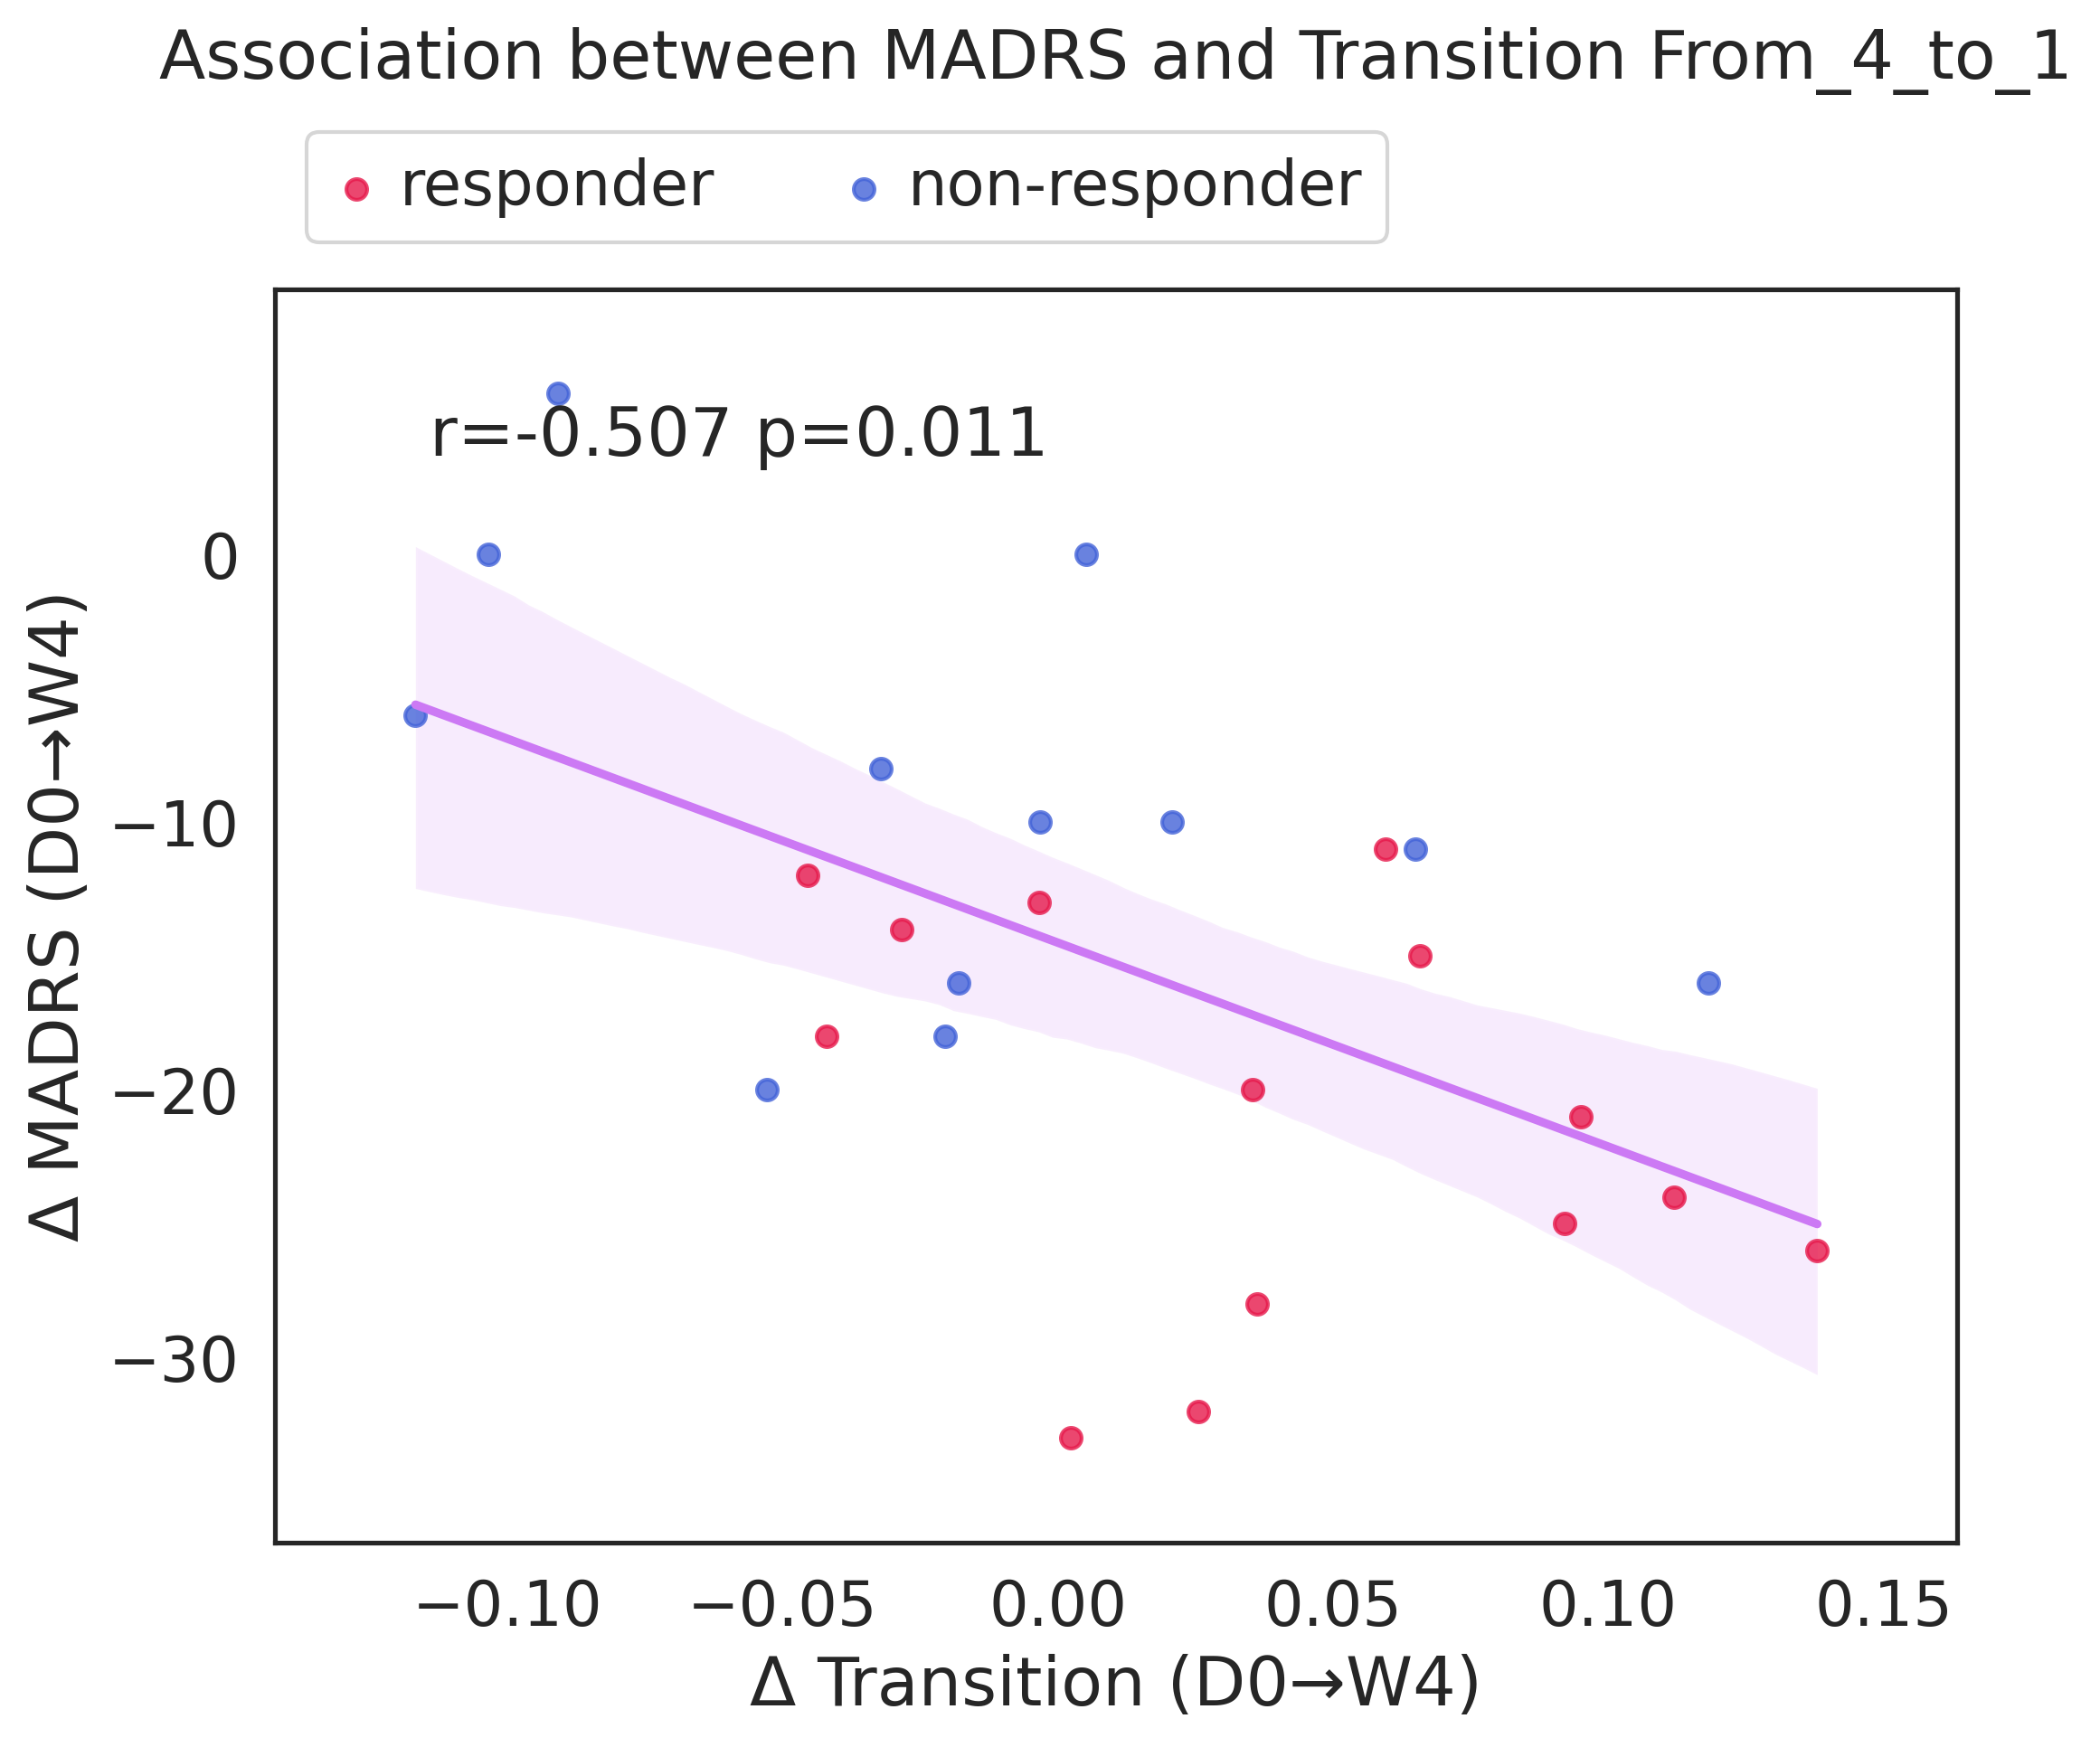

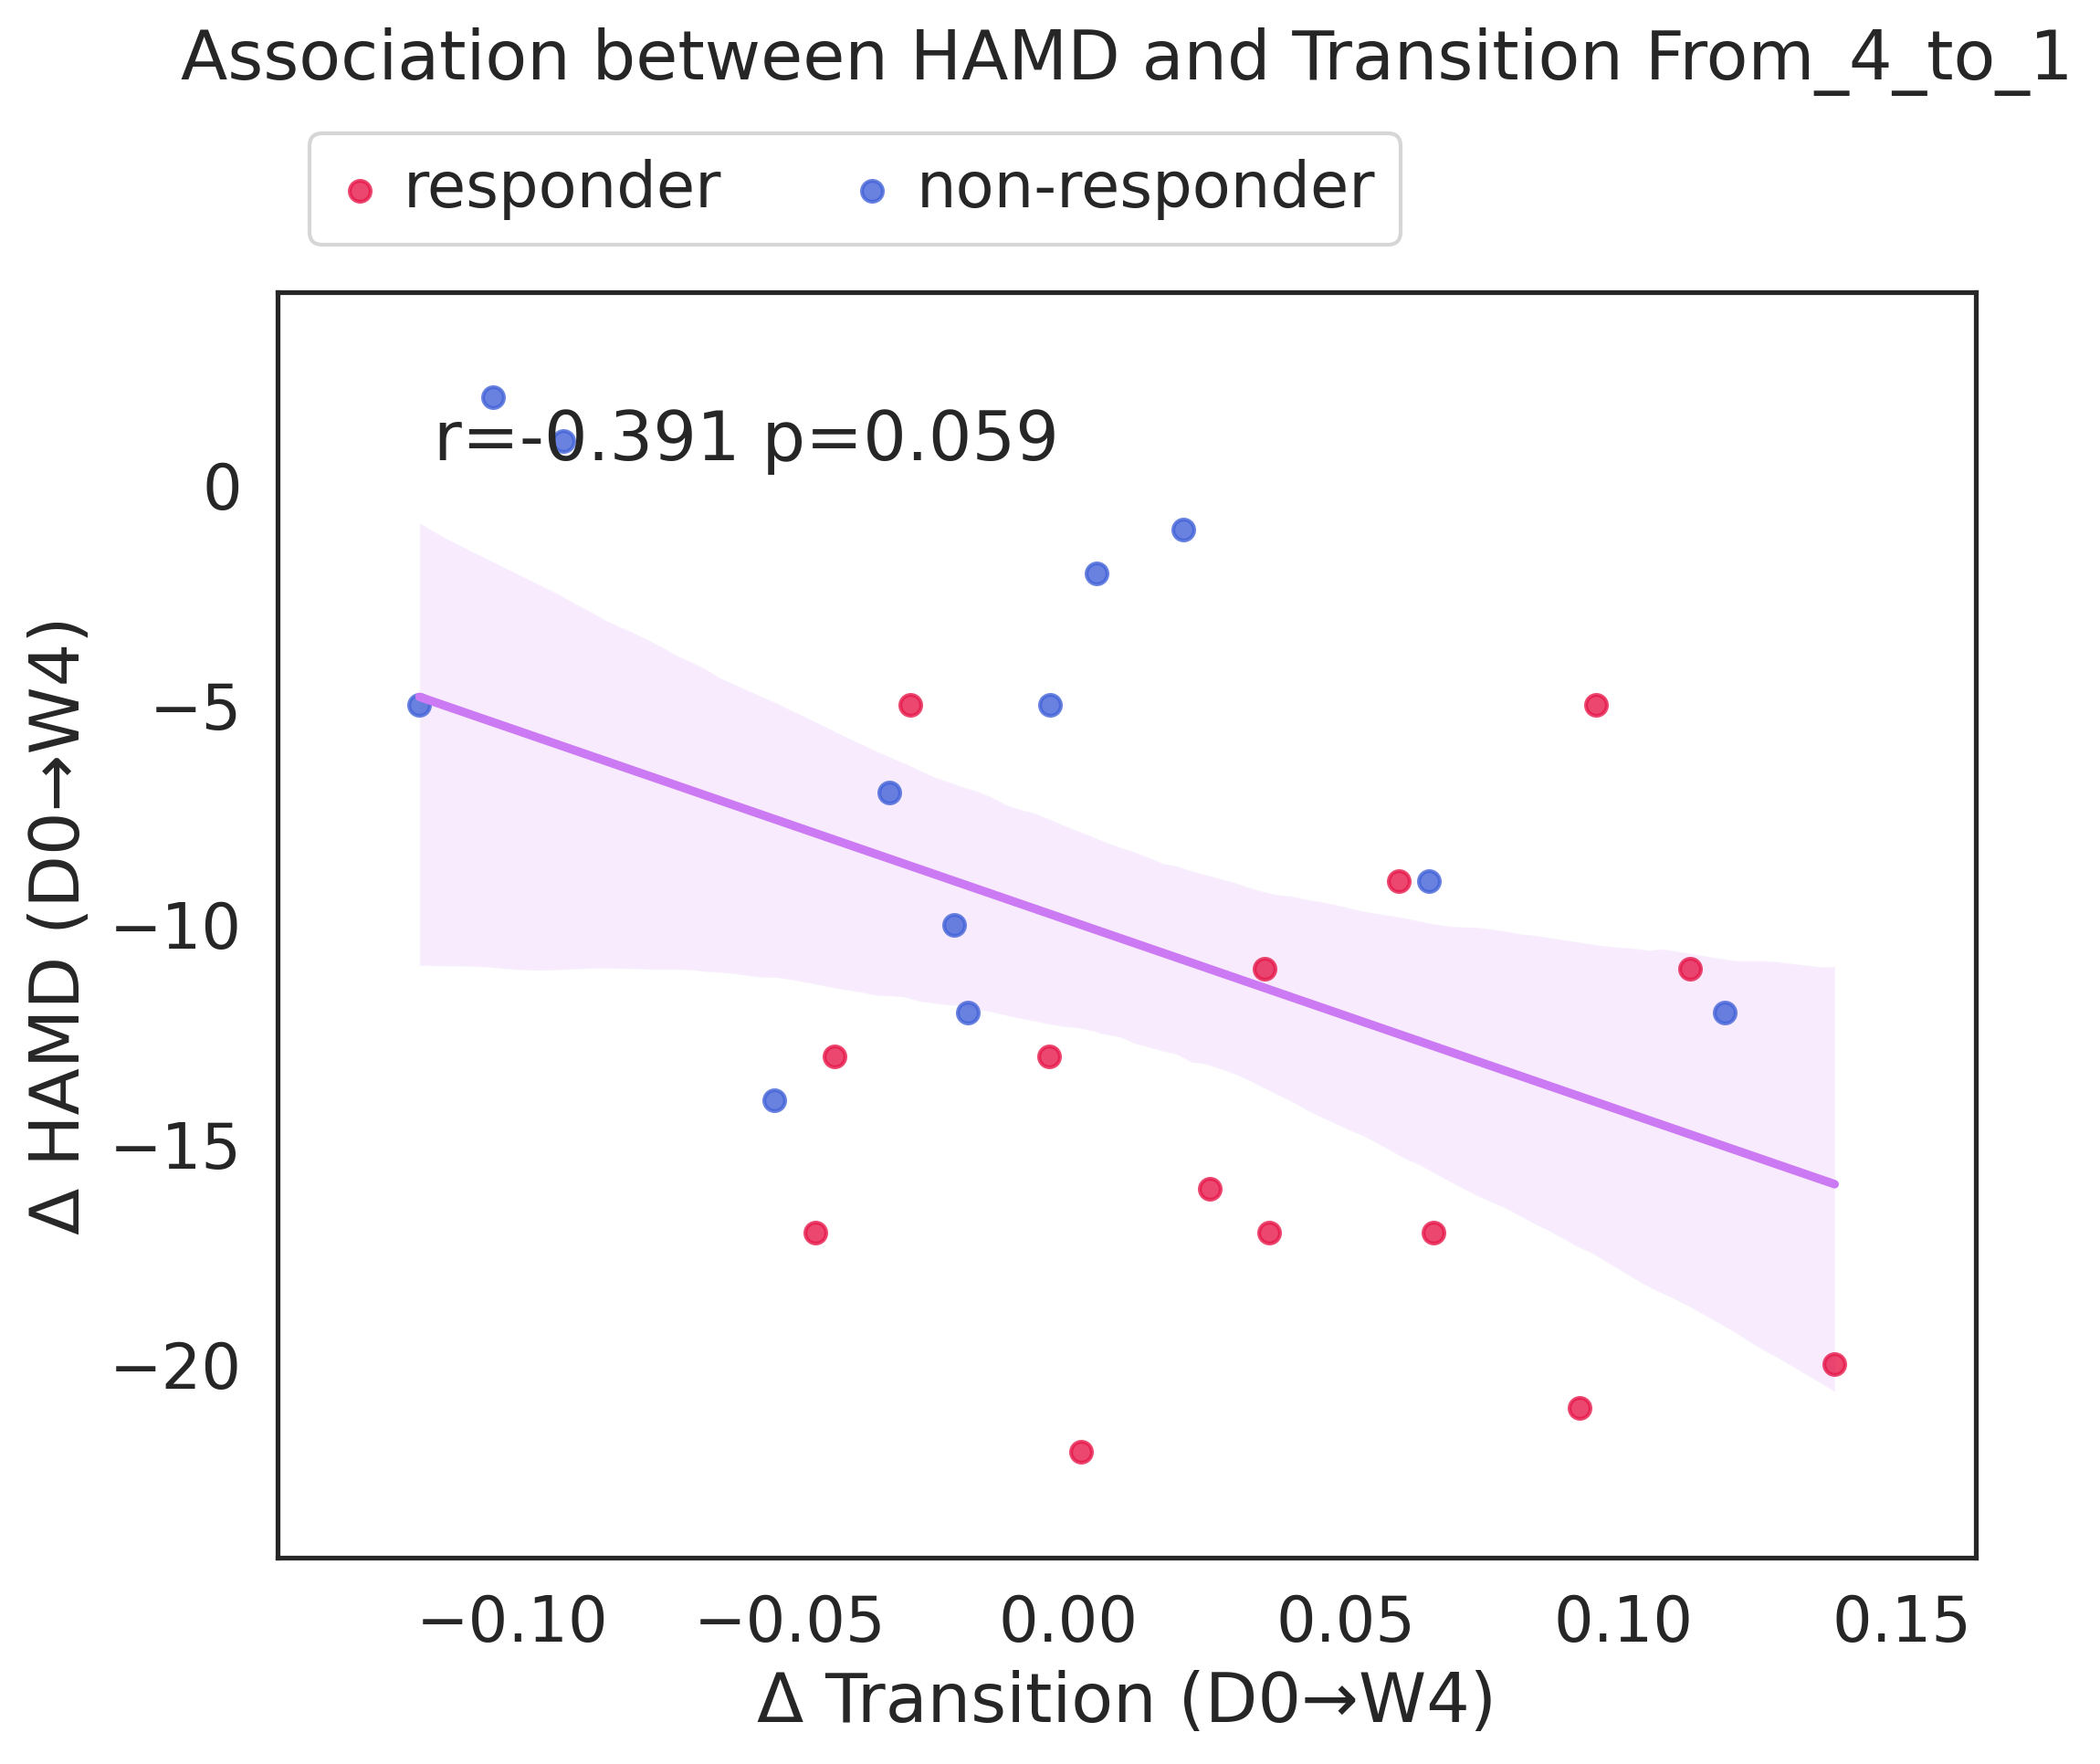

In [ ]:
# Correlation plots for W4 transition metric vs clinical scales
ses = '4weeks'
data = trans[trans['condition'].isin(["baseline",ses])]
mode = 'correlation'
metric = 'From_4_to_1'

col = 'MADRS'
plot_correlation(
    data = data, metric = metric,col = col, ses = ses, mode = mode, 
    xlabel = f'Δ Transition (D0→W4)', 
    ylabel = f'Δ {col} (D0→W4)', 
    title = f'Association between {col} and Transition {metric}')

col = 'HAMD'
plot_correlation(
    data = data, metric = metric,col = col, ses = ses, mode = mode, 
    xlabel = f'Δ Transition (D0→W4)', 
    ylabel = f'Δ {col} (D0→W4)', 
    title = f'Association between {col} and Transition {metric}')


### **SVM - responder**

In [ ]:
# Import sklearn modules for SVM classification and evaluation
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import cross_val_predict


In [ ]:
# Grid search over C values to find the best SVM (RBF kernel) via 5-fold CV
def calc_best_C(X,y):
    acc_max = 0
    acc_amx_C = 0
    C_arr = [1e-3,1e-2,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.2,1.4,1.6,1.8,2]
    for C in C_arr:
        clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C))
        scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
        acc = np.mean(scores)
        if(acc>acc_max):
            acc_max = acc
            acc_amx_C = C
    return acc_max,acc_amx_C


In [ ]:
# Prepare features: baseline transition probabilities + baseline HAMD/MADRS
f_ls = ['From_4_to_1','From_4_to_2']
df = trans[trans['condition'] == 'baseline'].loc[:, ['subject_id','sex','age', 'responder'] + f_ls]

base_feature = df.loc[:, f_ls].values
y = df.loc[:, 'responder'].values

# Load baseline HAMD scores for W4 session
ses = '4weeks'
col = "HAMD"
scale = col_dict[col].copy()
scale = match_scale(scale, ses)
scale = scale[scale["timepoint"].isin(['baseline','4weeks'])]
scale.index = scale.ID.values
ses0 = scale[scale['timepoint'] == 'baseline'].reindex(sub_ls)
ses1 = scale[scale['timepoint'] == ses].reindex(sub_ls)
base_HAMD = np.array(ses0.loc[:,col]).reshape(-1,1)

# Load baseline MADRS scores (note: code uses 'HAMD' again for base_MADRS — potential bug)
col = "HAMD"
scale = col_dict[col].copy()
scale = match_scale(scale, ses)
scale = scale[scale["timepoint"].isin(['baseline','4weeks'])]
scale.index = scale.ID.values
ses0 = scale[scale['timepoint'] == 'baseline'].reindex(sub_ls)
ses1 = scale[scale['timepoint'] == ses].reindex(sub_ls)
base_MADRS = np.array(ses0.loc[:,col]).reshape(-1,1)

# Combine all features and z-score normalize
X = np.hstack((base_feature,base_HAMD,base_MADRS))
X_z = zscore(X, axis = 0)


In [ ]:
# Find best C value and report the optimal CV accuracy
Acc_obs,C_obs = calc_best_C(X,y)
print(f"Best 5-fold CV average acc: {(Acc_obs*100):.2f}%，Best C value: {C_obs}")


Best 5-fold CV average acc: 80.00%，Best C value: 1.4


In [ ]:
# Evaluate final SVM with best C: per-fold accuracy and out-of-fold predictions
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C_obs))
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"Acc of every fold: {scores}")
acc = np.mean(scores)
print(f"5-fold CV average acc：{(acc*100):.2f}%")

y_oof = cross_val_predict(clf, X, y, cv=5, method='predict')
print(f"Out of Fold Acc: {np.mean(y_oof==y)*100:.2f}%")


Acc of every fold: [1.  0.6 1.  0.8 0.6]
5-fold CV average acc：80.00%
Out of Fold Acc: 80.77%


In [ ]:
# Permutation test: shuffle labels 1000 times to get null distribution of accuracy
acc_ls = []
for _ in range(1000):
    y_null = np.random.permutation(y)
    acc_null,_ = calc_best_C(X,y_null)
    acc_ls.append(acc_null)
acc_ls = np.array(acc_ls)
p_permutation = np.mean(acc_ls>Acc_obs)
print(p_permutation)


0.013


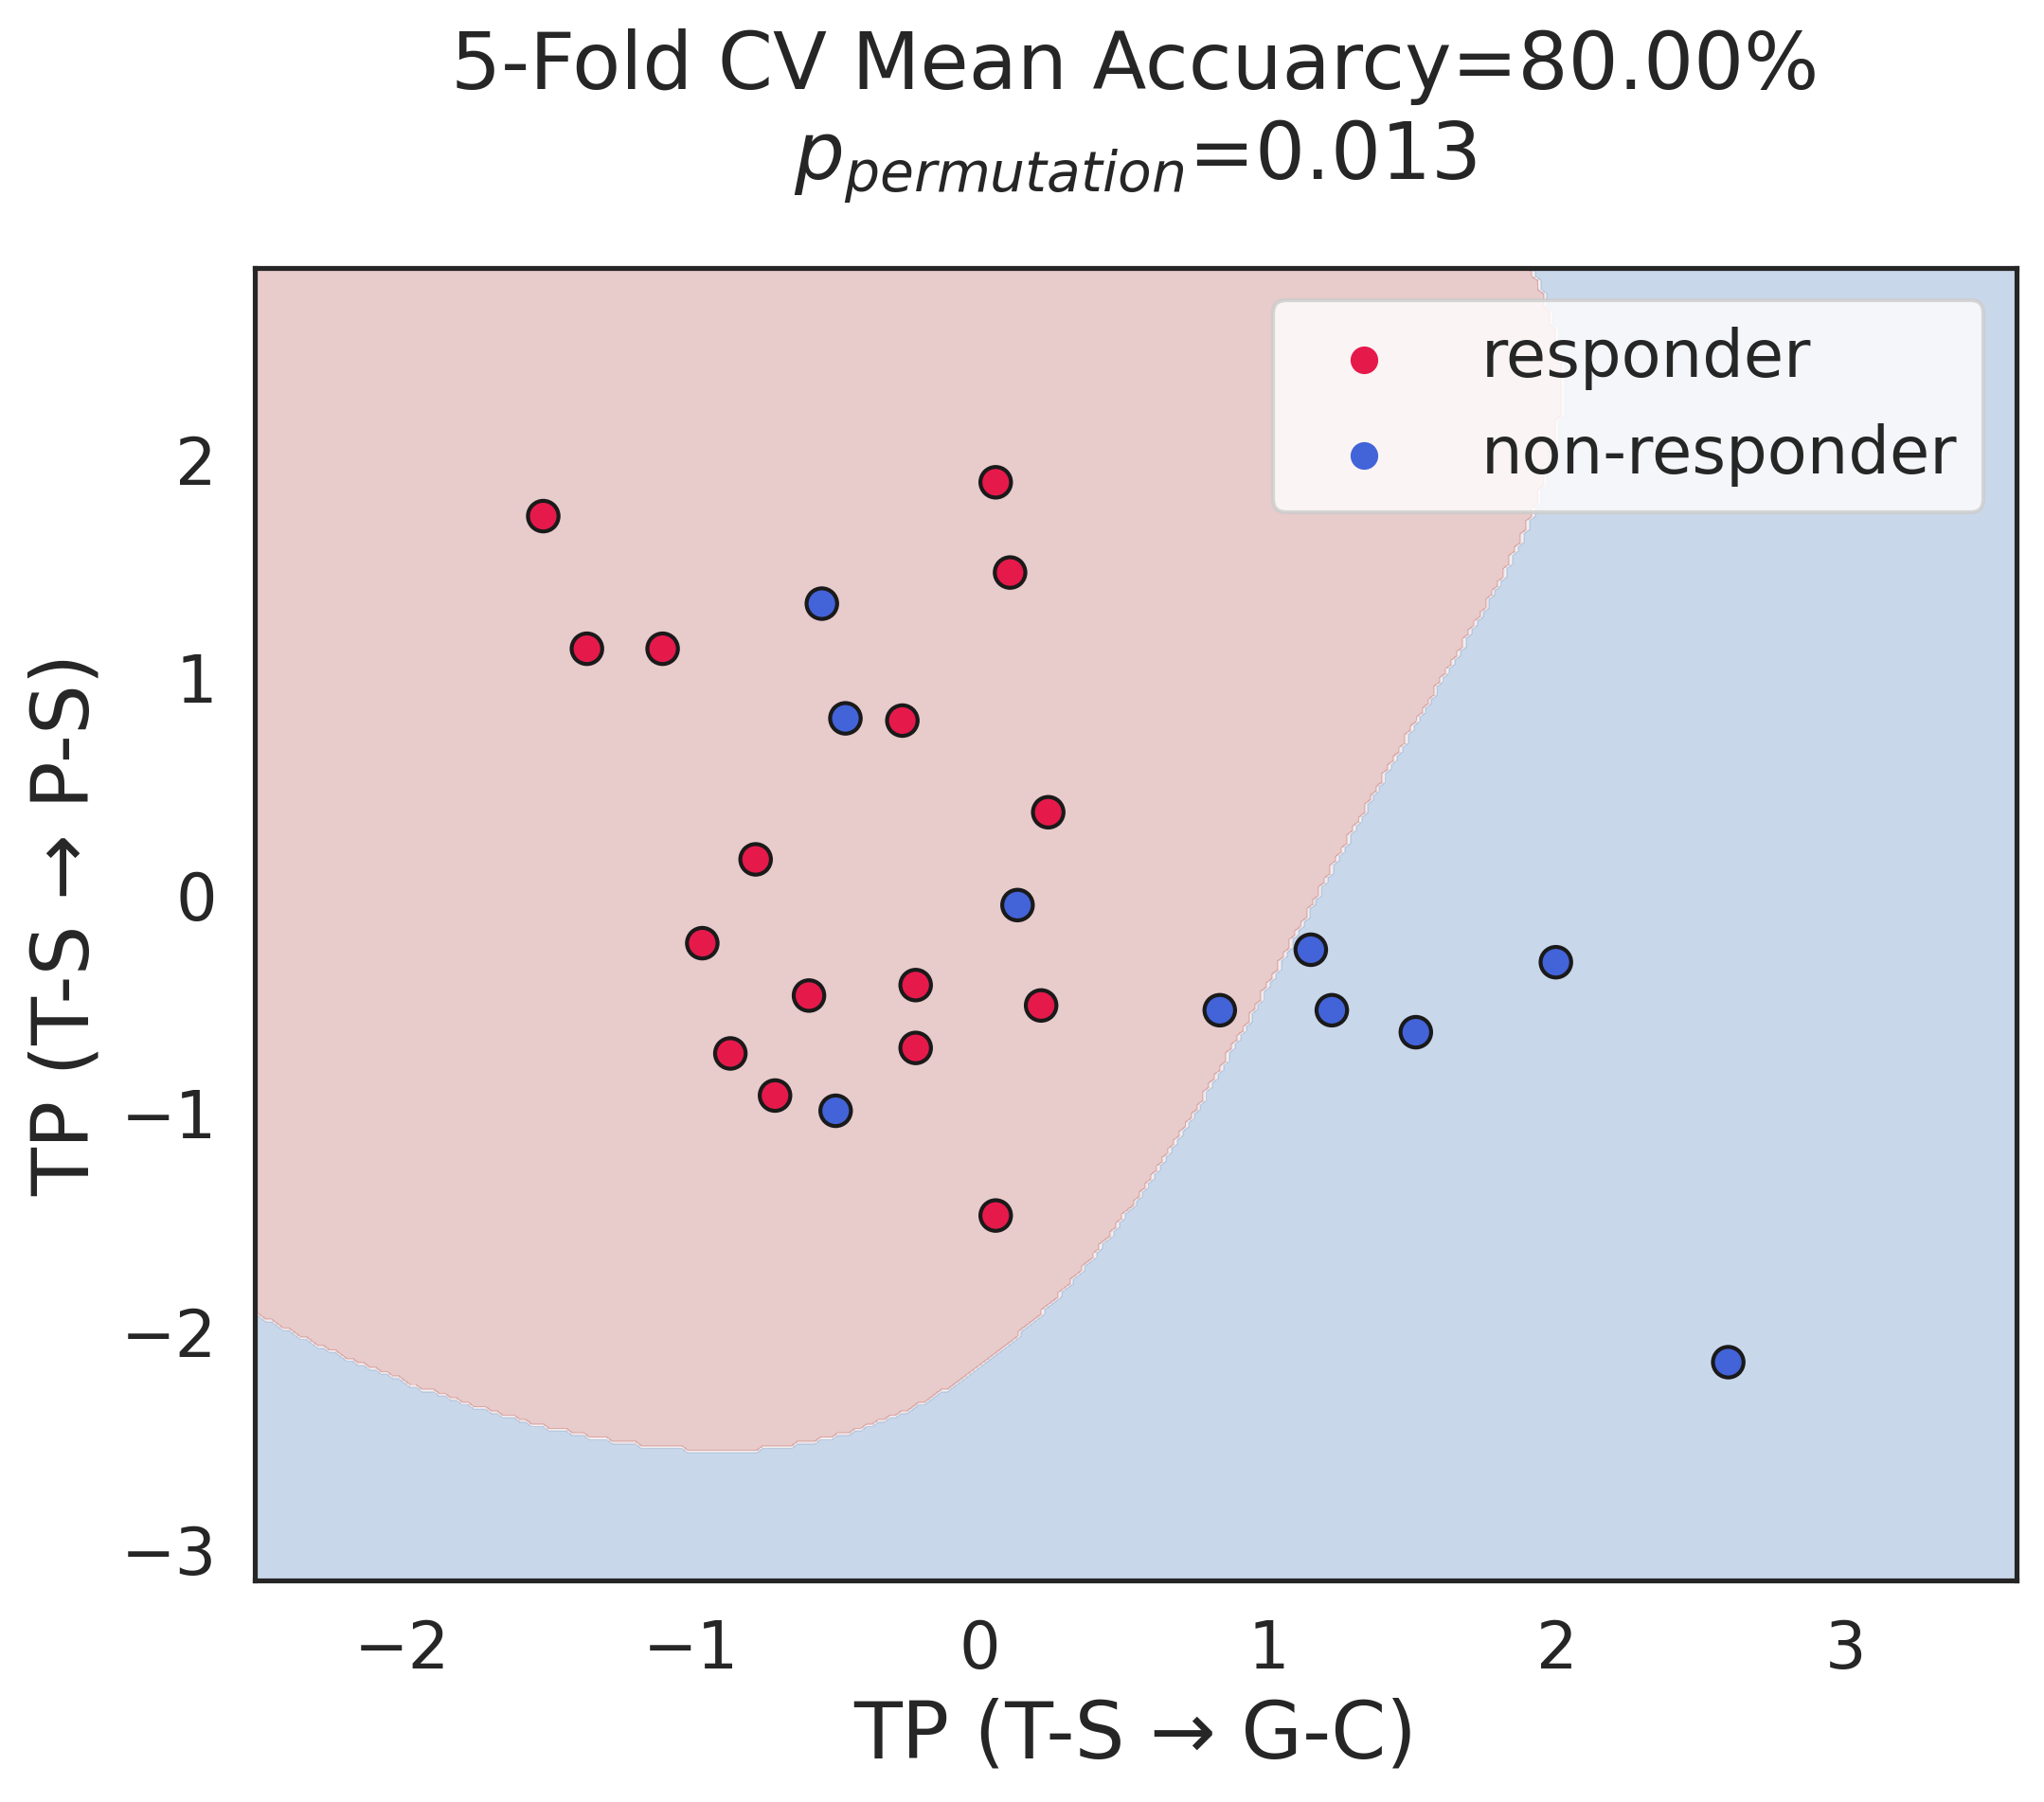

In [ ]:
# Convert responder labels to binary (1/0) for SVM
y_index = y.copy()
y_index[y == 'responder'] = 1
y_index[y == 'non-responder'] = 0
y_index = y_index.astype(int)

# Train SVM on full z-scored data and predict
model = SVC(kernel='rbf', C=C_obs)
model.fit(X_z, y_index)
y_pred = model.predict(X_z)

# Create 2D decision boundary mesh (fixing dimensions 3 & 4 to their means)
x_min, x_max = X_z[:, 0].min() - 1, X_z[:, 0].max() + 1
y_min, y_max = X_z[:, 1].min() - 1, X_z[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

f3_val = np.mean(X_z[:, 2])
f4_val = np.mean(X_z[:, 3])

grid_points = np.c_[xx.ravel(), yy.ravel(), 
                    np.full(xx.ravel().shape, f3_val), 
                    np.full(xx.ravel().shape, f4_val)]

Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot decision boundary and data points
plt.figure(figsize=(8, 6), dpi = 300)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.get_cmap('vlag'))

c = [res_colors[0] if i==1 else res_colors[1] for i in y_pred]
plt.scatter(X_z[:, 0], X_z[:, 1], c=c, edgecolors='k', s = 60)

plt.xlabel('TP (T-S → G-C)', fontsize = 20)
plt.ylabel('TP (T-S → P-S)', fontsize = 20)
plt.title(f"5-Fold CV Mean Accuarcy={(Acc_obs*100):.2f}%\n$p_{{permutation}}$={p_permutation:.3f}", y = 1.05, fontsize = 20)

plt.scatter([],[],color = res_colors[0], label = 'responder')
plt.scatter([],[],color = res_colors[1], label = 'non-responder')
plt.legend()
plt.show()


5-Fold CV AUC = 0.8155


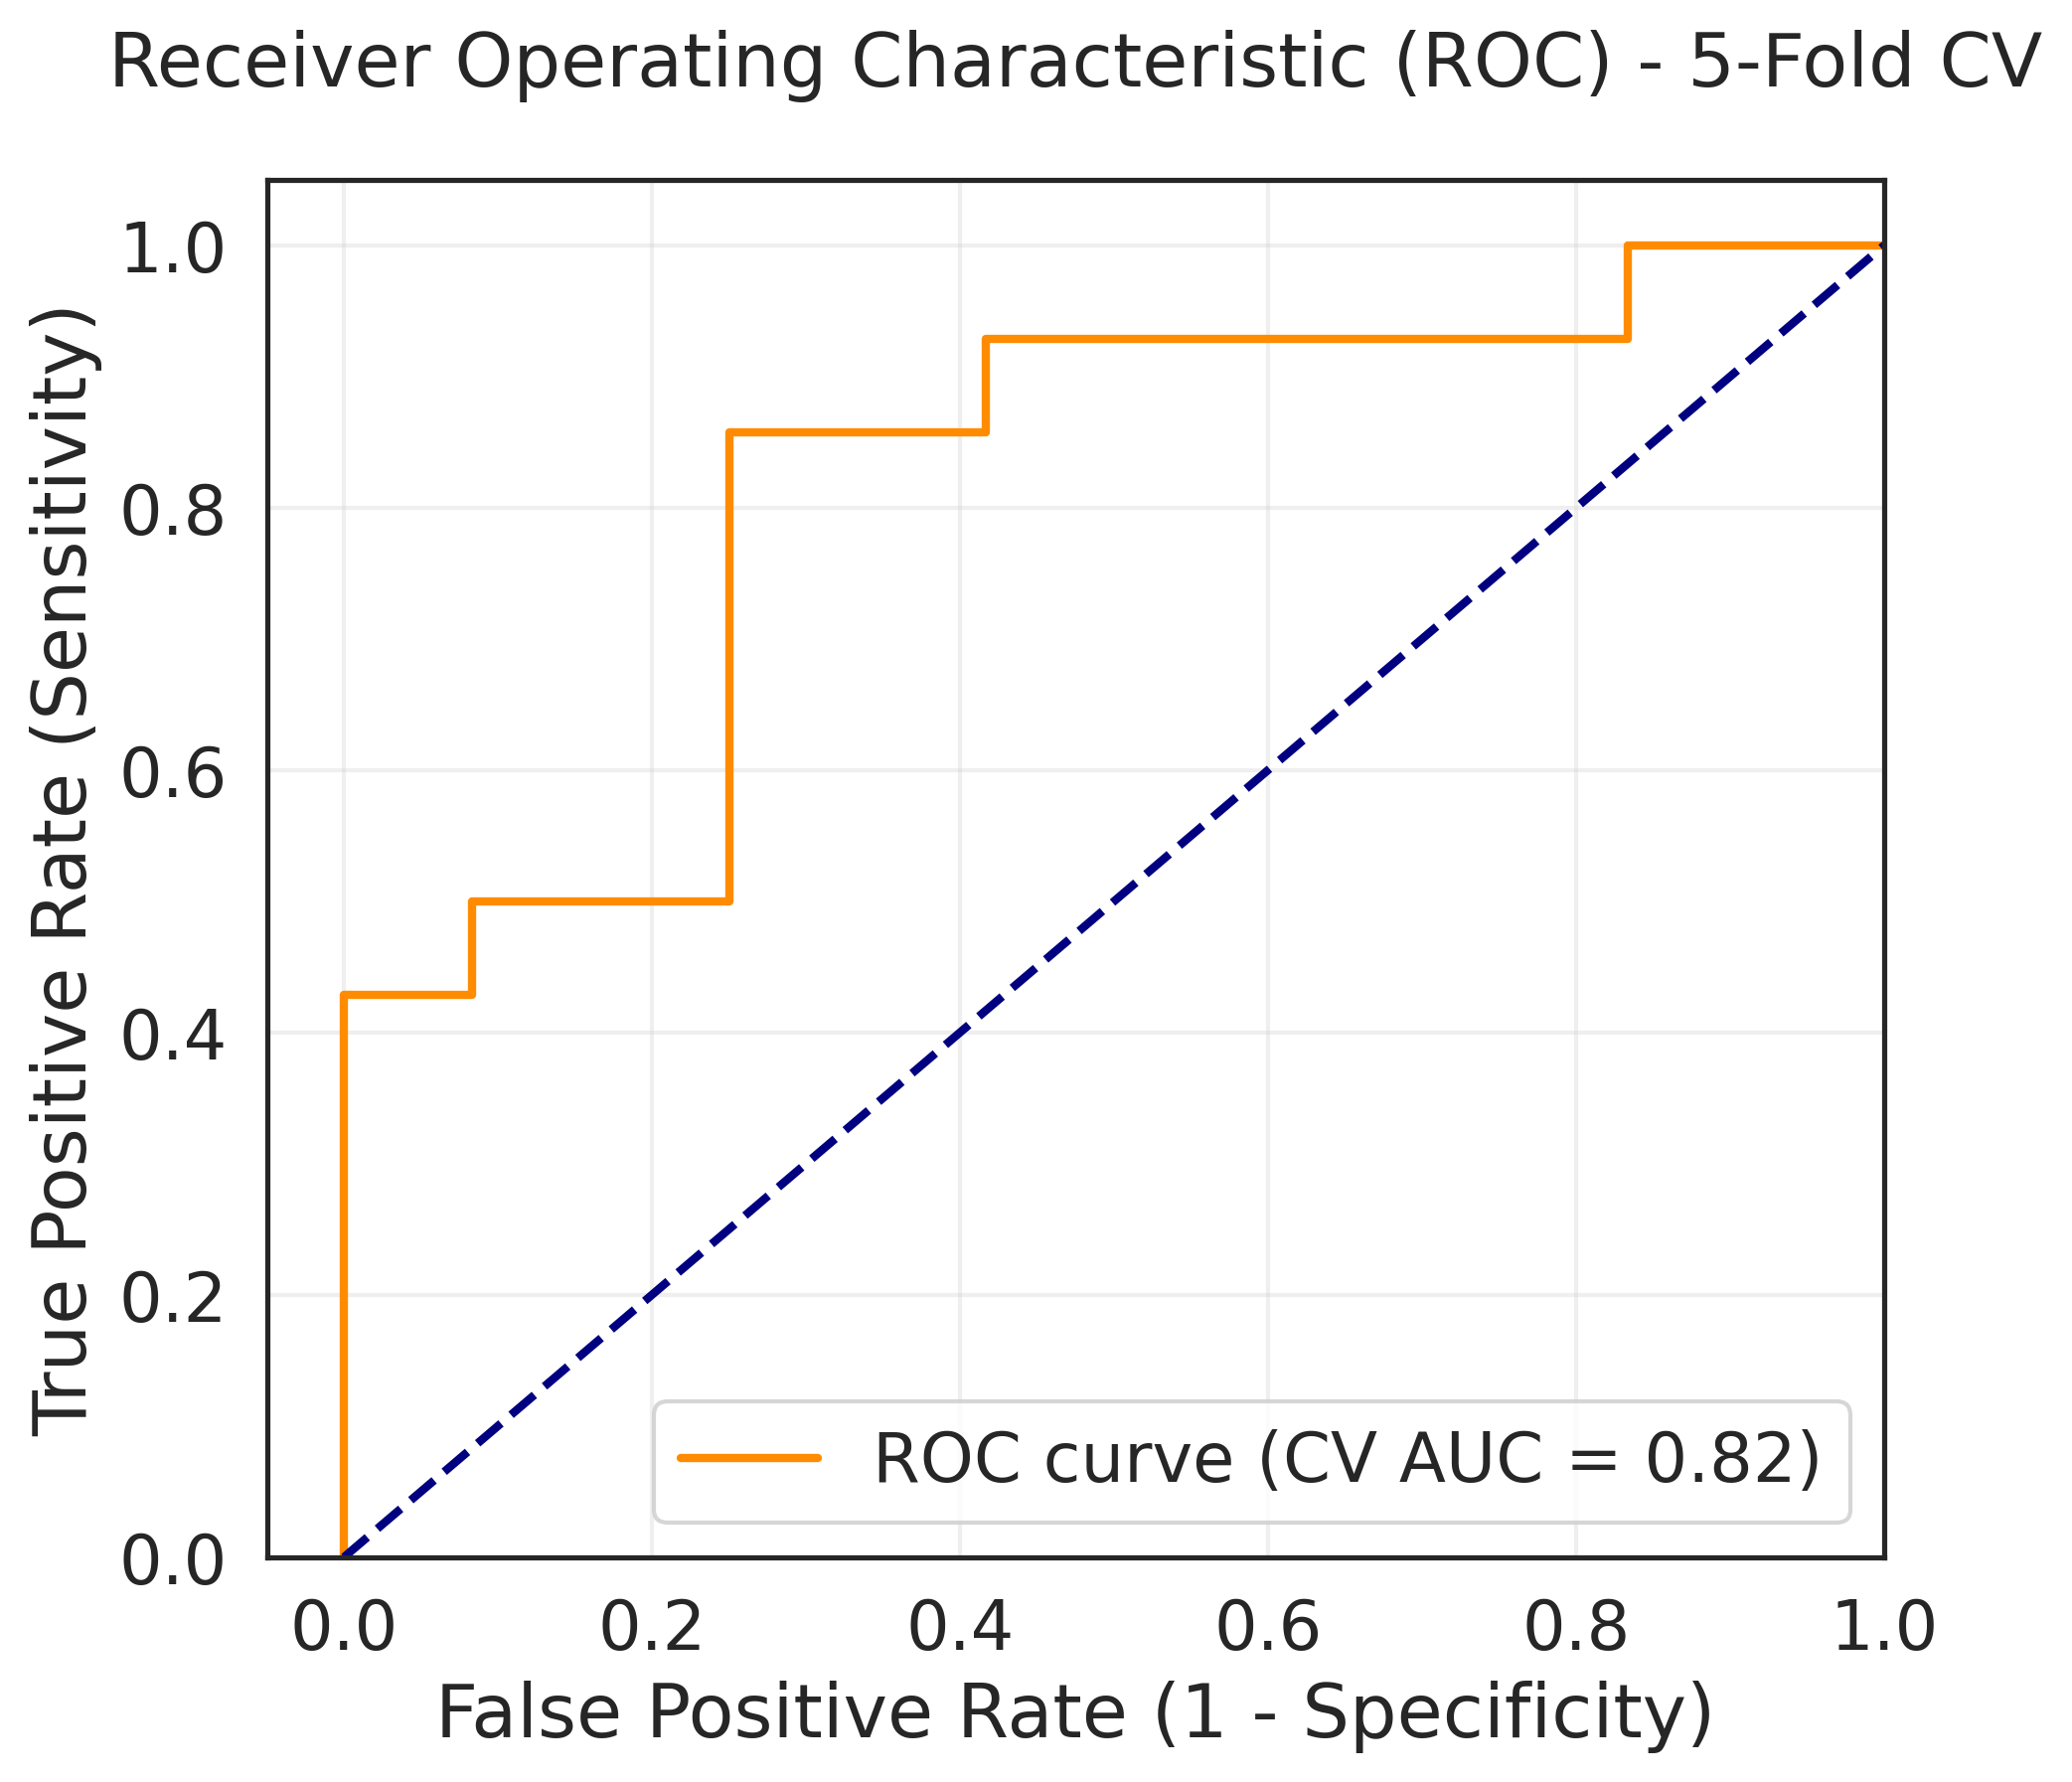

In [ ]:
# ROC curve with stratified 5-fold cross-validation
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=False,)

clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C_obs))
y_preds_cv = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

roc_auc_cv = roc_auc_score(y, y_preds_cv)
print(f"5-Fold CV AUC = {roc_auc_cv:.4f}")

fpr, tpr, thresholds = roc_curve(y, y_preds_cv, pos_label='responder')

plt.figure(figsize=(7, 6), dpi = 300)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (CV AUC = {roc_auc_cv:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - 5-Fold CV', y=1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(f"ROC_AUC.png",dpi = 300,bbox_inches='tight')
plt.show()


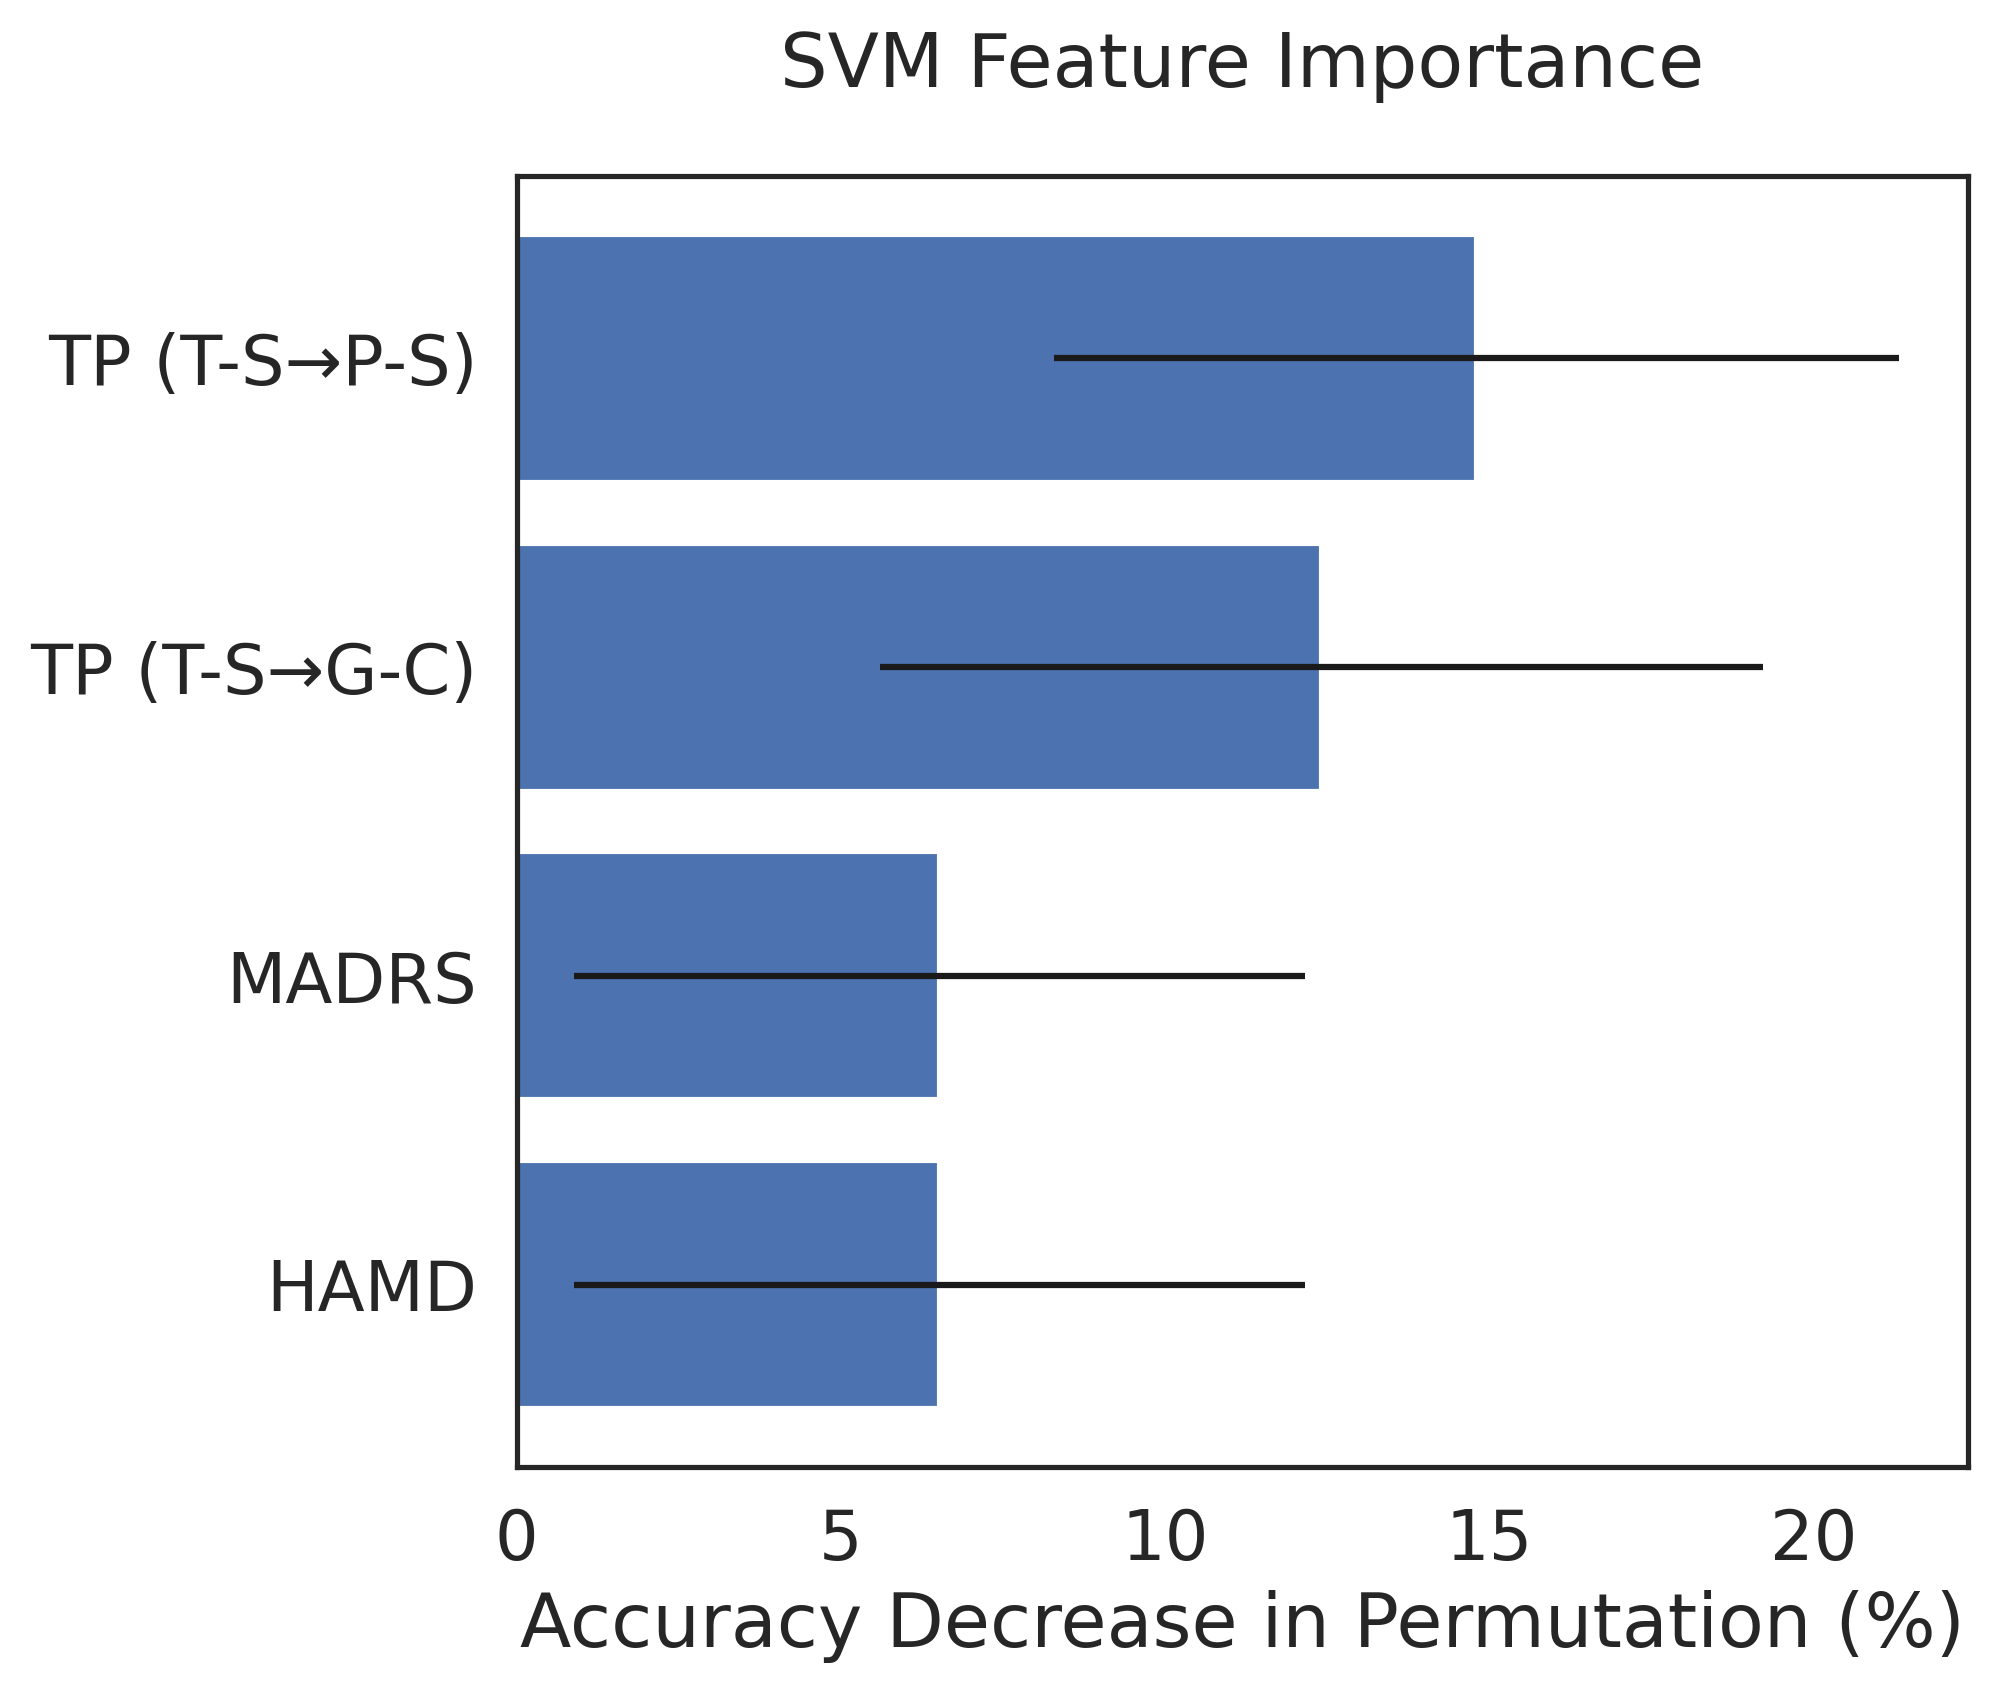

In [ ]:
# Permutation feature importance: accuracy drop when shuffling each feature
from sklearn.inspection import permutation_importance

model = SVC(kernel='rbf', C=C_obs)
model.fit(X_z, y)

result = permutation_importance(
    model, X_z, y, n_repeats=1000, scoring='accuracy'
)

importances_mean = result.importances_mean*100
importances_std = result.importances_std*100

feature_names = np.array(['TP (T-S→G-C)','TP (T-S→P-S)','HAMD','MADRS'])
sorted_idx = importances_mean.argsort()

plt.figure(figsize=(7, 6), dpi = 300)
plt.barh(feature_names[sorted_idx], importances_mean[sorted_idx], xerr=importances_std[sorted_idx], align='center')
plt.xlabel("Accuracy Decrease in Permutation (%)")
plt.title("SVM Feature Importance", y = 1.05)
plt.tight_layout()
plt.show()


## **Prediction**

In [ ]:
# Import Ridge regression and R² score for prediction task
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge


In [ ]:
# Residualize baseline transition probabilities for sex and age
f_ls = ['From_4_to_1','From_4_to_2']
df = trans[trans['condition'] == 'baseline'].loc[:, ['subject_id','sex','age', 'responder'] + f_ls]

for f in f_ls:
    model = smf.ols(f"{f} ~ sex + age", data = df).fit()
    df.loc[:,f] -= model.predict(df)

df = df.reindex(sub_ls)
base_feature = df.loc[:, f_ls].values


ΔMADRS prediction: CV R² = 0.3710, r = 0.6121, p = 0.0009


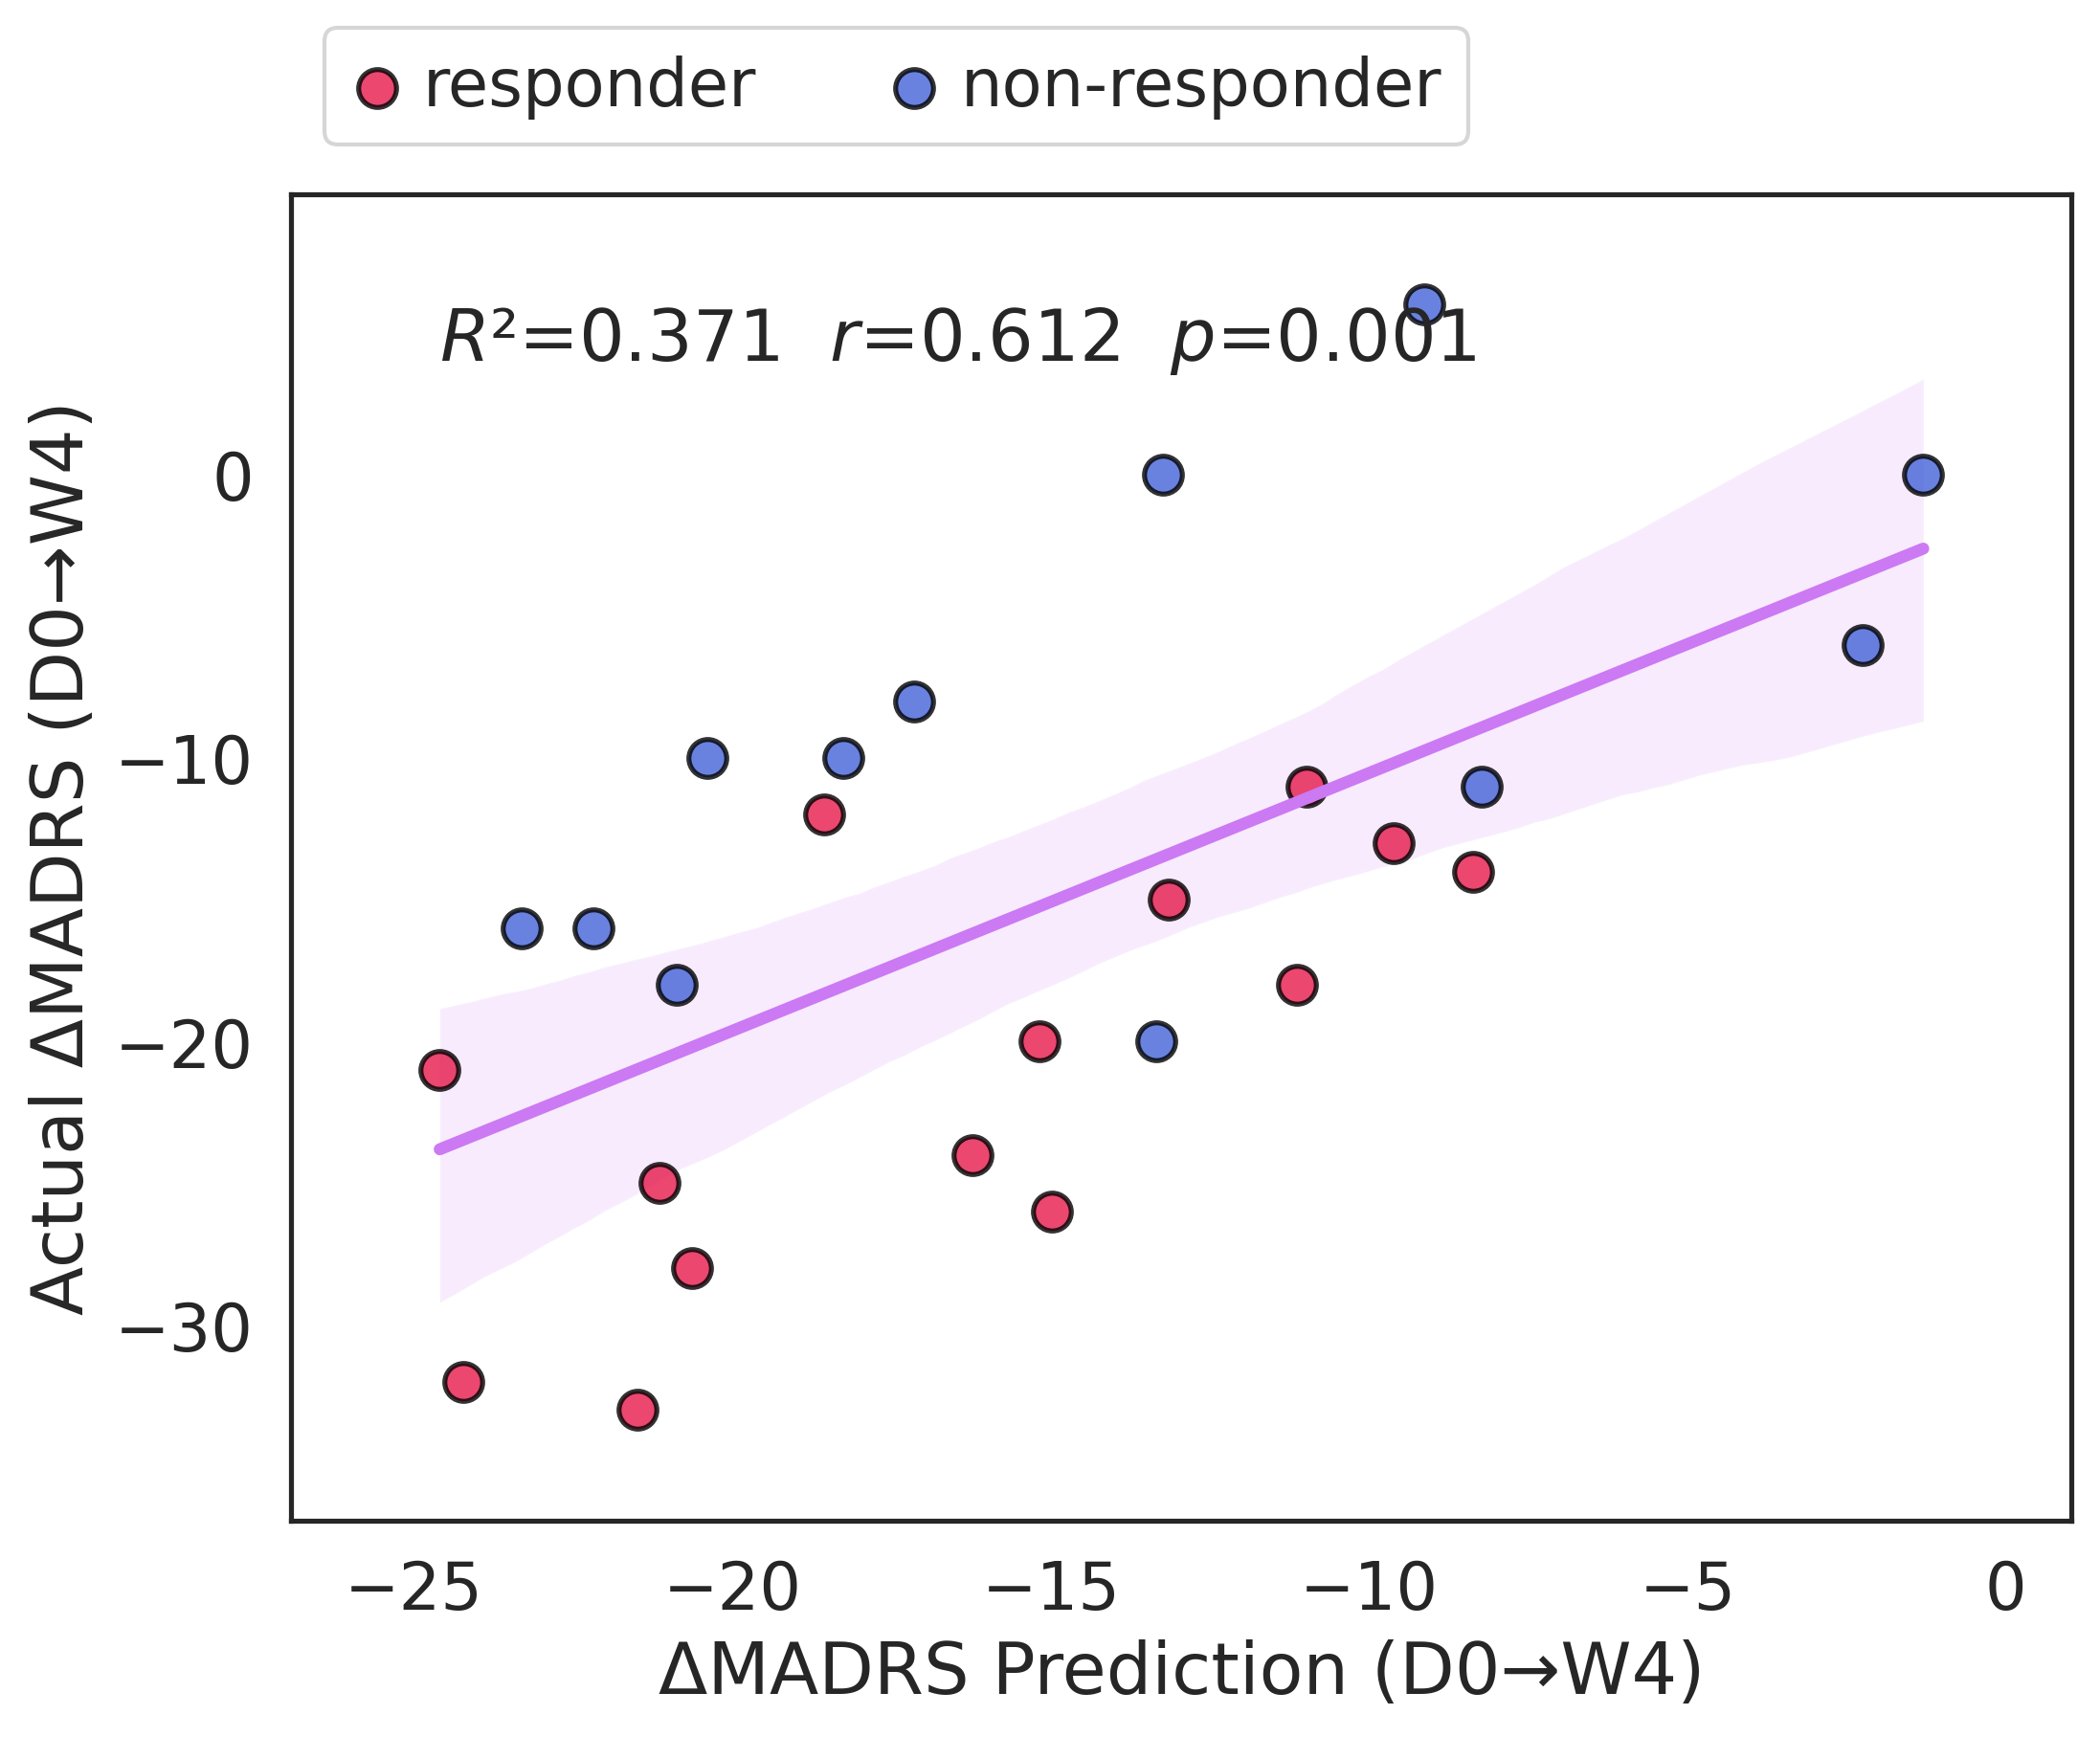

In [ ]:
# Ridge regression: predict W4 MADRS from baseline features + baseline MADRS
ses = '4weeks'
col = "MADRS"
scale = col_dict[col].copy()
scale = match_scale(scale, ses)
scale = scale[scale["timepoint"].isin(['baseline','4weeks'])]
scale.index = scale.ID.values
ses0 = scale[scale['timepoint'] == 'baseline'].reindex(sub_ls)
ses1 = scale[scale['timepoint'] == ses].reindex(sub_ls)
change = (ses1.loc[:,col]-ses0.loc[:,col]).values
base_scale = np.array(ses0.loc[:,col]).reshape(-1,1)
Y = ses1.loc[:, col].values
X = np.hstack((base_feature,base_scale))

# Ridge with 5-fold CV, evaluate on Δ predictions
pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
preds = cross_val_predict(pipeline, X, Y, cv=5)
preds_change = preds-ses0.loc[:,col].values
r,p = pearsonr(change, preds_change)

r2 = r2_score(change, preds_change)
print(f"Δ{col} prediction: CV R² = {r2:.4f}, r = {r:.4f}, p = {p:.4f}")

# Scatter plot: predicted Δ vs actual Δ, colored by responder
df = pd.DataFrame({
    "Prediction":preds_change,"Actual":change
})
df.loc[:, 'Responder'] = responder.loc[sub_ls, "responder"].values

fig,ax = plt.subplots(figsize = (8,6),dpi = 300)
sns.regplot(data=df,x="Prediction",y="Actual",ci=95, 
            scatter_kws={"facecolors": "#262626","edgecolor": "#262626","s": 20,'alpha':0},
            line_kws={"color": '#cc79f4','linewidth': 3} )
plt.scatter(data=df[df['Responder']=='responder'],x="Prediction",y="Actual",color=res_colors[0],label='responder',
            s=90,edgecolor = 'black', alpha = 0.8, linewidth = 1.25)
plt.scatter(data=df[df['Responder']!='responder'],x="Prediction",y="Actual",color=res_colors[1],label='non-responder',
            s=90,edgecolor = 'black', alpha = 0.8, linewidth = 1.25)
x_max = np.max(df["Prediction"]);x_min = np.min(df["Prediction"]);x_range=x_max-x_min
y_max = np.max(df["Actual"]);y_min = np.min(df["Actual"]);y_range=y_max-y_min
y_text = y_max;x_text = x_min
plt.text(x_text,y_text,f"$R²$={r2:.3f}  $r$={r:.3f}  $p$={p:.3f}",ha='left', va='top')
plt.xlim(x_min-x_range*.1,x_max+x_range*.1)
plt.ylim(y_min-y_range*.1,y_max+y_range*.1)
plt.xlabel(f"Δ{col} Prediction (D0→W4)")
plt.ylabel(f"Actual Δ{col} (D0→W4)")
plt.legend(bbox_to_anchor=(0, 1.15), loc='upper left', frameon=True,handlelength=0.8,handletextpad=0.3,ncol=2)
plt.savefig(f"{col}_Prediction.png",dpi = 300,bbox_inches='tight')
plt.show()


ΔHAMD prediction: CV R² = 0.2418, r = 0.5101, p = 0.0078


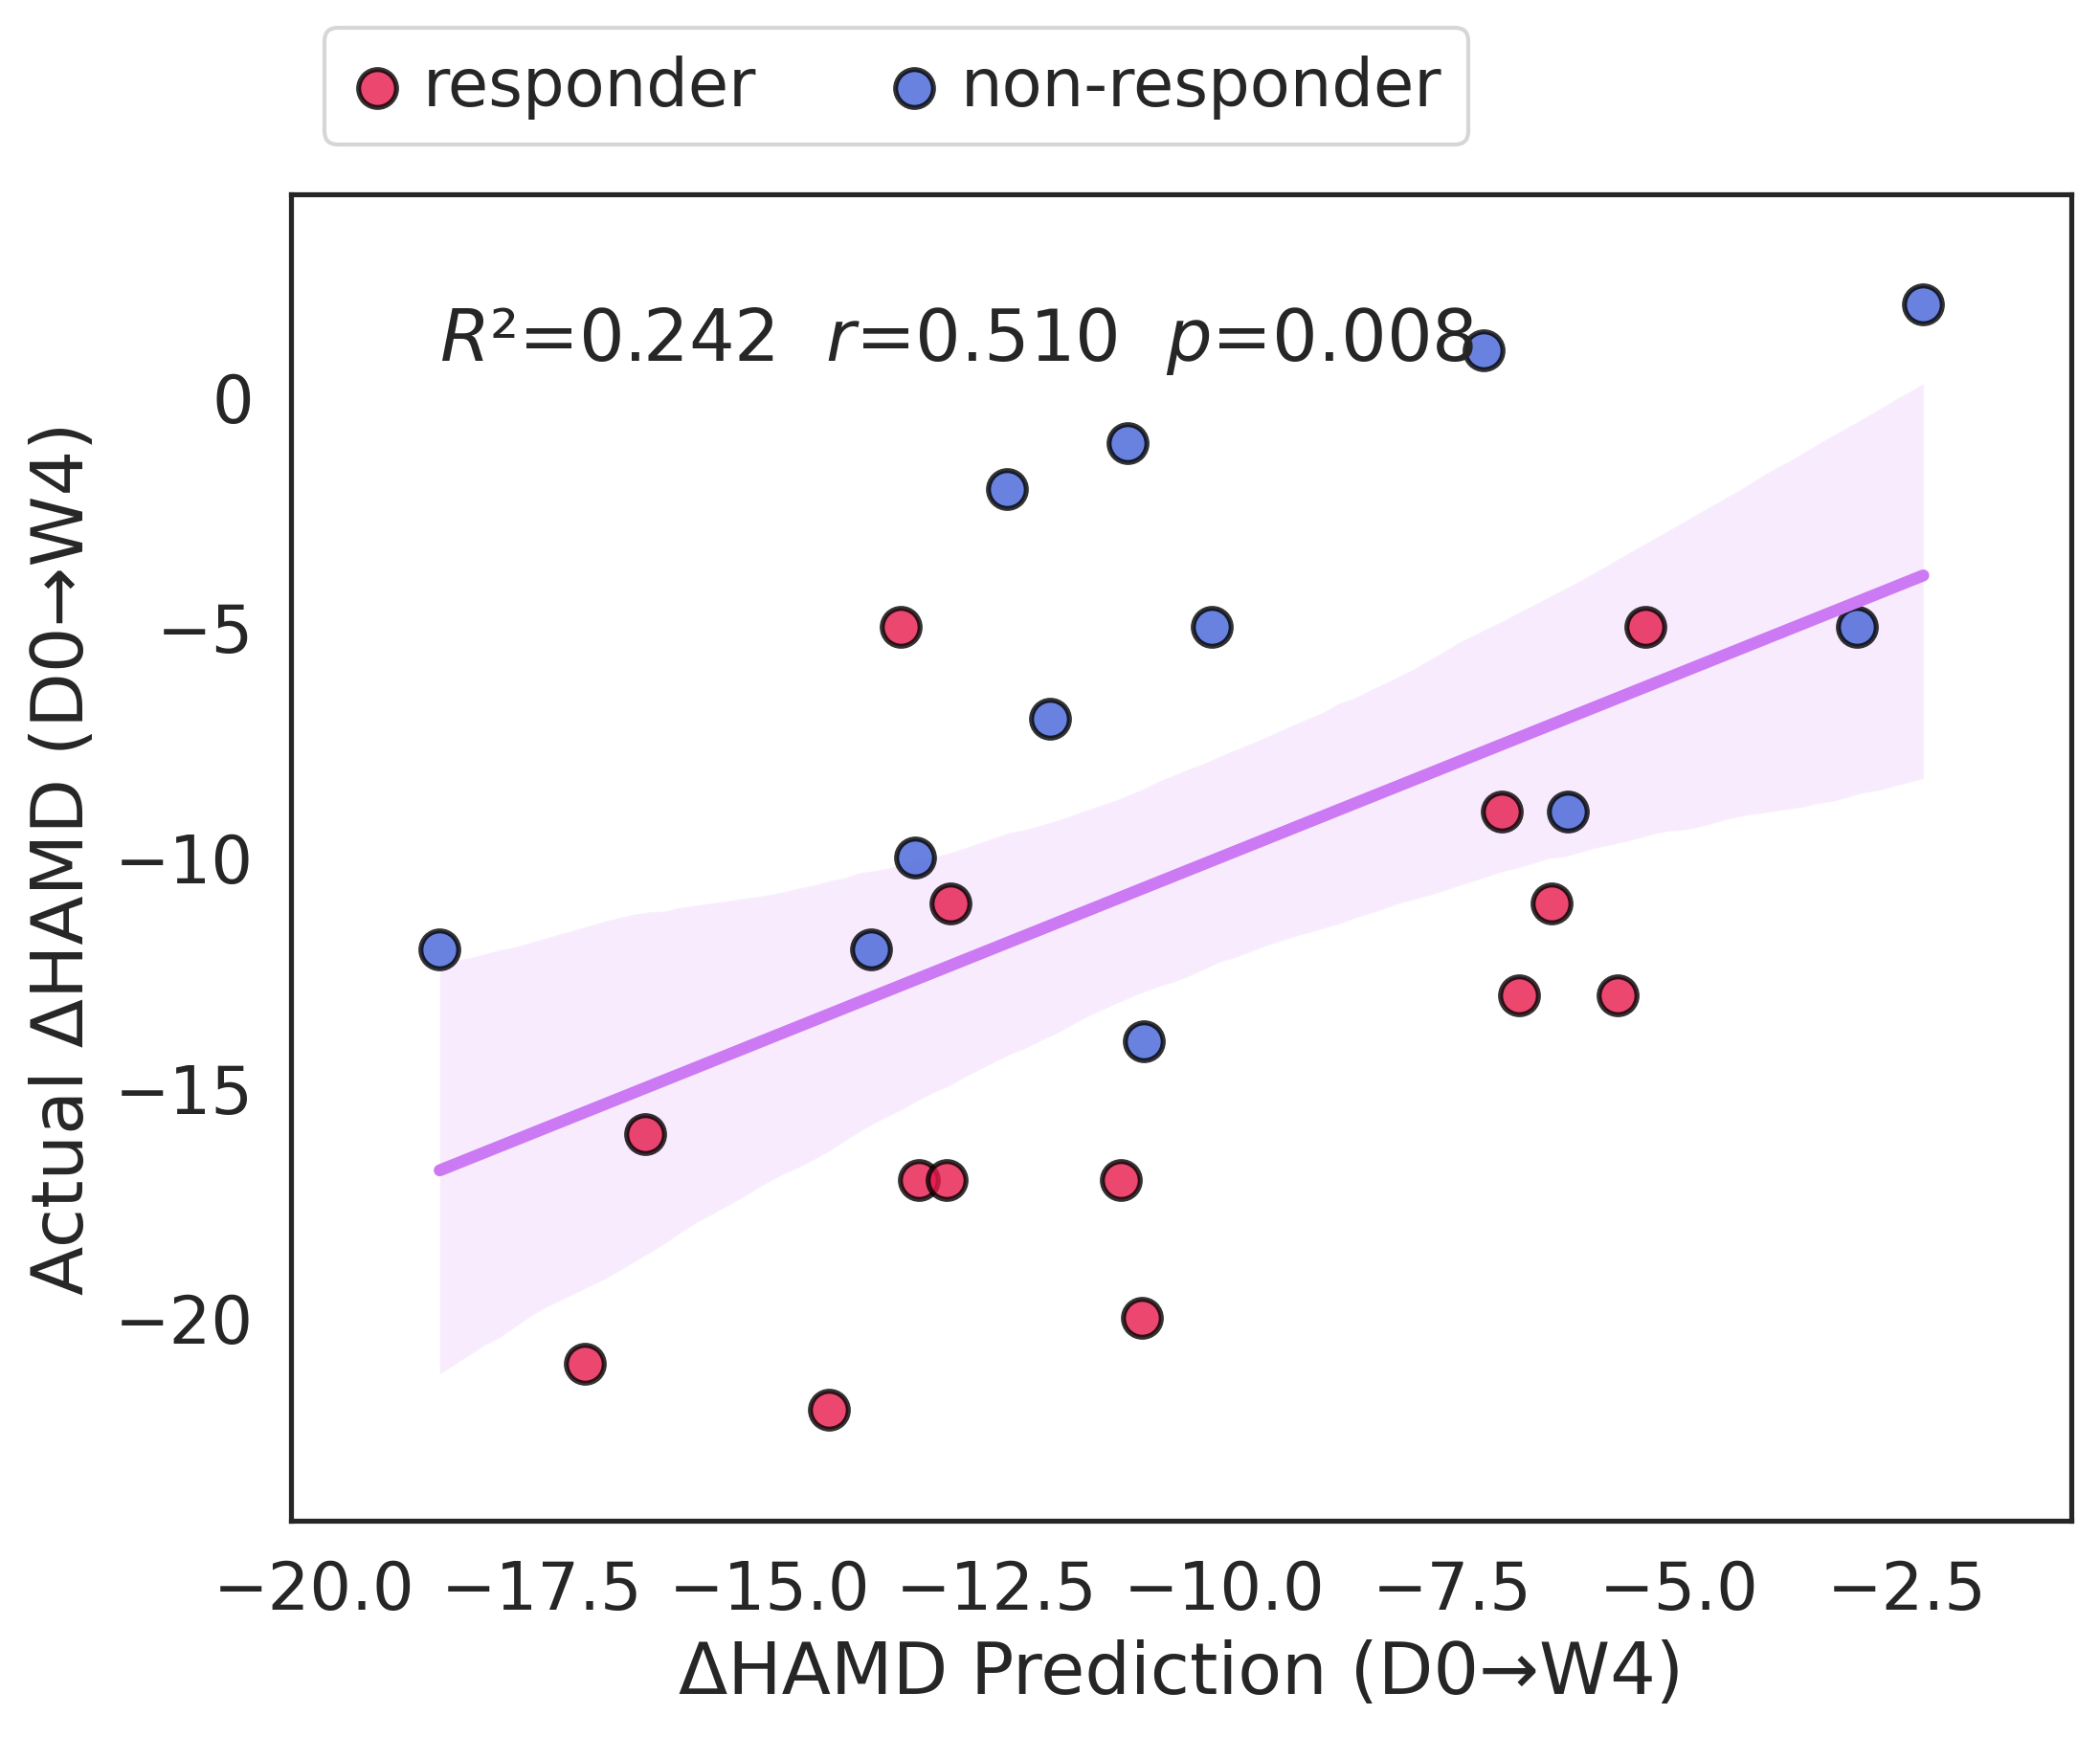

In [ ]:
# Ridge regression: predict W4 HAMD from baseline features + baseline HAMD
ses = '4weeks'
col = "HAMD"
scale = col_dict[col].copy()
scale = match_scale(scale, ses)
scale = scale[scale["timepoint"].isin(['baseline','4weeks'])]
scale.index = scale.ID.values
ses0 = scale[scale['timepoint'] == 'baseline'].reindex(sub_ls)
ses1 = scale[scale['timepoint'] == ses].reindex(sub_ls)
change = (ses1.loc[:,col]-ses0.loc[:,col]).values
base_scale = np.array(ses0.loc[:,col]).reshape(-1,1)
Y = ses1.loc[:, col].values
X = np.hstack((base_feature,base_scale))

pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
preds = cross_val_predict(pipeline, X, Y, cv=5)
preds_change = preds-ses0.loc[:,col].values
r,p = pearsonr(change, preds_change)

r2 = r2_score(change, preds_change)
print(f"Δ{col} prediction: CV R² = {r2:.4f}, r = {r:.4f}, p = {p:.4f}")

# Plot predicted vs actual Δ HAMD with responder coloring
df = pd.DataFrame({
    "Prediction":preds_change,"Actual":change
})
df.loc[:, 'Responder'] = responder.loc[sub_ls, "responder"].values

fig,ax = plt.subplots(figsize = (8,6),dpi = 300)
sns.regplot(data=df,x="Prediction",y="Actual",ci=95, 
            scatter_kws={"facecolors": "#262626","edgecolor": "#262626","s": 20,'alpha':0},
            line_kws={"color": '#cc79f4','linewidth': 3} )
plt.scatter(data=df[df['Responder']=='responder'],x="Prediction",y="Actual",color=res_colors[0],label='responder',
            s=90,edgecolor = 'black', alpha = 0.8, linewidth = 1.25)
plt.scatter(data=df[df['Responder']!='responder'],x="Prediction",y="Actual",color=res_colors[1],label='non-responder',
            s=90,edgecolor = 'black', alpha = 0.8, linewidth = 1.25)
x_max = np.max(df["Prediction"]);x_min = np.min(df["Prediction"]);x_range=x_max-x_min
y_max = np.max(df["Actual"]);y_min = np.min(df["Actual"]);y_range=y_max-y_min
y_text = y_max;x_text = x_min
plt.text(x_text,y_text,f"$R²$={r2:.3f}  $r$={r:.3f}  $p$={p:.3f}",ha='left', va='top')
plt.xlim(x_min-x_range*.1,x_max+x_range*.1)
plt.ylim(y_min-y_range*.1,y_max+y_range*.1)
plt.xlabel(f"Δ{col} Prediction (D0→W4)")
plt.ylabel(f"Actual Δ{col} (D0→W4)")
plt.legend(bbox_to_anchor=(0, 1.15), loc='upper left', frameon=True,handlelength=0.8,handletextpad=0.3,ncol=2)
plt.savefig(f"{col}_Prediction.png",dpi = 300,bbox_inches='tight')
plt.show()
